In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(ggplot2)
    library(dplyr)
    library(ggthemes)
    library(uwot)
    library(pheatmap)
    library(harmony)
    library(tibble)
    library(tidyr)
    library(rlang)
    library(purrr)
    library(glue)
    source('/data/srlab/AMP_collab/lakshay-yakir/_common/typing_utils.r')
})

# Load data

In [35]:
# load AMP
amp.p2.counts.path <- "/data/srlab/fzhang/amp/results/2020_01_22_AMP_cite_seq_QC/mRNA_exprs_2020-01-24.rds"
amp.p2.meta.path <- "/data/srlab1/public/srcollab/AMP_Phase_2/singlecell_result/fine_cluster_all_celltypes_82samples_2021-04-23.rds"
sc <- readRDS(amp.p2.counts.path)
sc.meta <- readRDS(amp.p2.meta.path)

sc.meta <- sc.meta %>%
  filter(cell_type %in% c("Myeloid cell"))
dim(sc.meta)
names(sc.meta)[2] <- 'sid'
sc <- sc[, rownames(sc.meta)]
dim(sc)

[1] 76171     7

[1] 33538 76171

In [2]:
sc <- readRDS('/data/srlab/AMP_collab/AMP2_2023_seuratObj_galoz//AMPp2_seuratObj_allcells.202511.rds')
sc <- subset(sc, subset = lineage == 'myeloid')
sc

An object of class Seurat 
33538 features across 76181 samples within 1 assay 
Active assay: RNA (33538 features, 0 variable features)
 2 layers present: data, counts

In [4]:
mac.myeloid.path <- "/data/srlab/AMP_collab/lakshay-yakir/4.lineages/out_rds/EDP1/allcells_qc_harm_umap_clusters_annotation.rds"
xen <- readRDS(mac.myeloid.path)

In [7]:
# load myeloid cells from Xenium 
xen <- subset(xen, subset = (xen$seurat_clusters %in% c(1, 2, 10, 15, 16)))
xen

An object of class Seurat 
4008 features across 534950 samples within 1 assay 
Active assay: RNA (4008 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, humap

In [10]:
xen$cell_type <- xen[[]] %>% 
    mutate(cell_type = case_when(
        seurat_clusters == 15 ~ 'pDC', 
        seurat_clusters == 10 ~ 'Dendritic cell', 
        .default = 'Macrophage'
        )
           ) %>% 
    pull(cell_type)

In [9]:
# filter AMPp2 to the same set of genes in the same order and convert to Seurat
common <- intersect(rownames(sc), rownames(xen))
sc <- subset(sc, features = common)
#sc <- CreateSeuratObject(sc[common, ],
#                 meta.data = sc.meta,
#                 project = 'AMPp2')
#sc <- NormalizeData(sc, normalization.method = "LogNormalize", scale.factor = median(sc$nCount_RNA), verbose = F)

In [10]:
# define myeloid subtypes 
sc$cell_type <- sc[[]] %>% 
    mutate(ct = case_when(
        grepl(' pDC', cluster_name) ~ 'pDC', 
        grepl(' DC|LAMP3', cluster_name) ~ 'Dendritic cell',
        .default = 'Macrophage'
        )
           ) %>% 
    pull(ct)

sc

An object of class Seurat 
4004 features across 76181 samples within 1 assay 
Active assay: RNA (4004 features, 0 variable features)
 2 layers present: data, counts

# Call macrophage vs DC vs pDC

## Get discriminatory genes from sc

In [11]:
# select genes that differentiate macrophage from DC from pDC in AMPp2
res <- FindHVGsFromGroups(sc, group_var = "cell_type", logFC_thresh = 0.1)
hvgs <- res$hvgs
info <- res$info

info %>%
    dplyr::select(feature, group) %>%
    dplyr::mutate(row = dplyr::row_number()) %>%
    tidyr::pivot_wider(names_from = group, values_from = feature) %>%
    head(n = 10)

Number of HVGs found: 1056 


row,Dendritic cell,Macrophage,pDC
<int>,<chr>,<chr>,<chr>
1,FCER1A,MARCO,GZMB
2,HLA-DQA1,C1QA,IRF7
3,CLEC10A,FCGR3A,TCF4
4,HLA-DRB1,C1QC,CCDC50
5,CD1C,CD14,IRF8
6,EEF1B2,CTSL,CLIC3
7,CPVL,GPNMB,BCL11A
8,CXCR4,CD163,LILRA4
9,CST7,MAFB,TSPAN13


## filter xenium + sc to these genes and merge


[1/7] Retrieving count matrices and checking gene overlap... 
  Xenium counts dimensions: 4008 genes x 534950 cells 
  Single-cell counts dimensions: 4004 genes x 76171 cells 
  Number of genes shared between objects: 4004 

[2/7] Preparing Seurat objects for merging... 
  Merged object created. 
  Merged object summary: 
An object of class Seurat 
4004 features across 611121 samples within 1 assay 
Active assay: RNA (4004 features, 0 variable features)
 1 layer present: counts
  Merged object dimensions: 4004 genes x 611121 cells 
  Cells by modality: 

    sc    xen 
 76171 534950 

[3/7] Choosing normalization scale factor... 
  Using mean of modality-specific medians. 
  Xen median nCount_RNA: 217 
  SC median nCount_RNA: 2496 
  Selected normalization scale factor: 1356.5 

[4/7] Normalizing data, setting variable features, and scaling... 
  HVGs supplied: 1164 
  HVGs present in merged object: 1164 


Centering and scaling data matrix

Centering and scaling data from split sc

Centering and scaling data from split xen




[5/7] Running dimensional reduction... 
  cca_weights is NULL/NA; running PCA. 


PC_ 1 
Positive:  PLEC, SIGLEC1, ANXA2, LRP1, VSIG4, GRN, SLCO2B1, LILRB5, FLNA, NCF1 
	   GAA, MAFB, AP1B1, NR1H3, PLXNB2, MMP14, ABCA1, TUBB, DST, BMP2K 
	   CD68, KLF2, KCNMA1, ENG, ADGRE5, CD44, MSR1, C3AR1, GPNMB, PKM 
Negative:  SPP1, FCER1A, F13A1, S100A12, IL1B, IL1R2, CD1C, CXCL8, FCN1, AREG 
	   HES4, NR4A3, PID1, MAFF, IL1RN, ATF3, LAMP3, CD1E, PMAIP1, CYTOR 
	   CCR7, CST7, CD93, CD36, P2RX1, ICAM3, FLT3, BCL2A1, CX3CR1, IDO1 
PC_ 2 
Positive:  C1QC, C1QA, MARCO, GPNMB, LGMN, CD68, S100A4, VSIG4, CTSL, FOLR2 
	   PLTP, FCGR3A, TIMD4, CD163, EMP1, MSR1, CTSS, LYVE1, LILRB5, PMP22 
	   GRN, CYBB, COLEC12, FCGRT, LAMP1, CREG1, TIMP2, CD99, HTRA1, FUCA1 
Negative:  CIITA, BCL11A, ITGAX, SLAMF7, GZMB, HNRNPH1, IRF7, LTB, RUNX2, IRF8 
	   CLEC4C, CCR2, CLEC10A, ACAP1, LENG8, FCER1A, LILRA4, JAK3, WDFY4, MYCL 
	   ITGA4, OGT, DERL3, ADAM8, CD1C, SPN, TSPAN13, CXCR4, DDX39B, CFLAR 
PC_ 3 
Positive:  S100A10, FLNA, PKM, FBP1, S100A4, ANXA2, TREM1, ALDH2, MARCO, ANPEP 
	   RHOA, TIMD

  Printing PCA diagnostic plots... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[6/7] Running Harmony... 


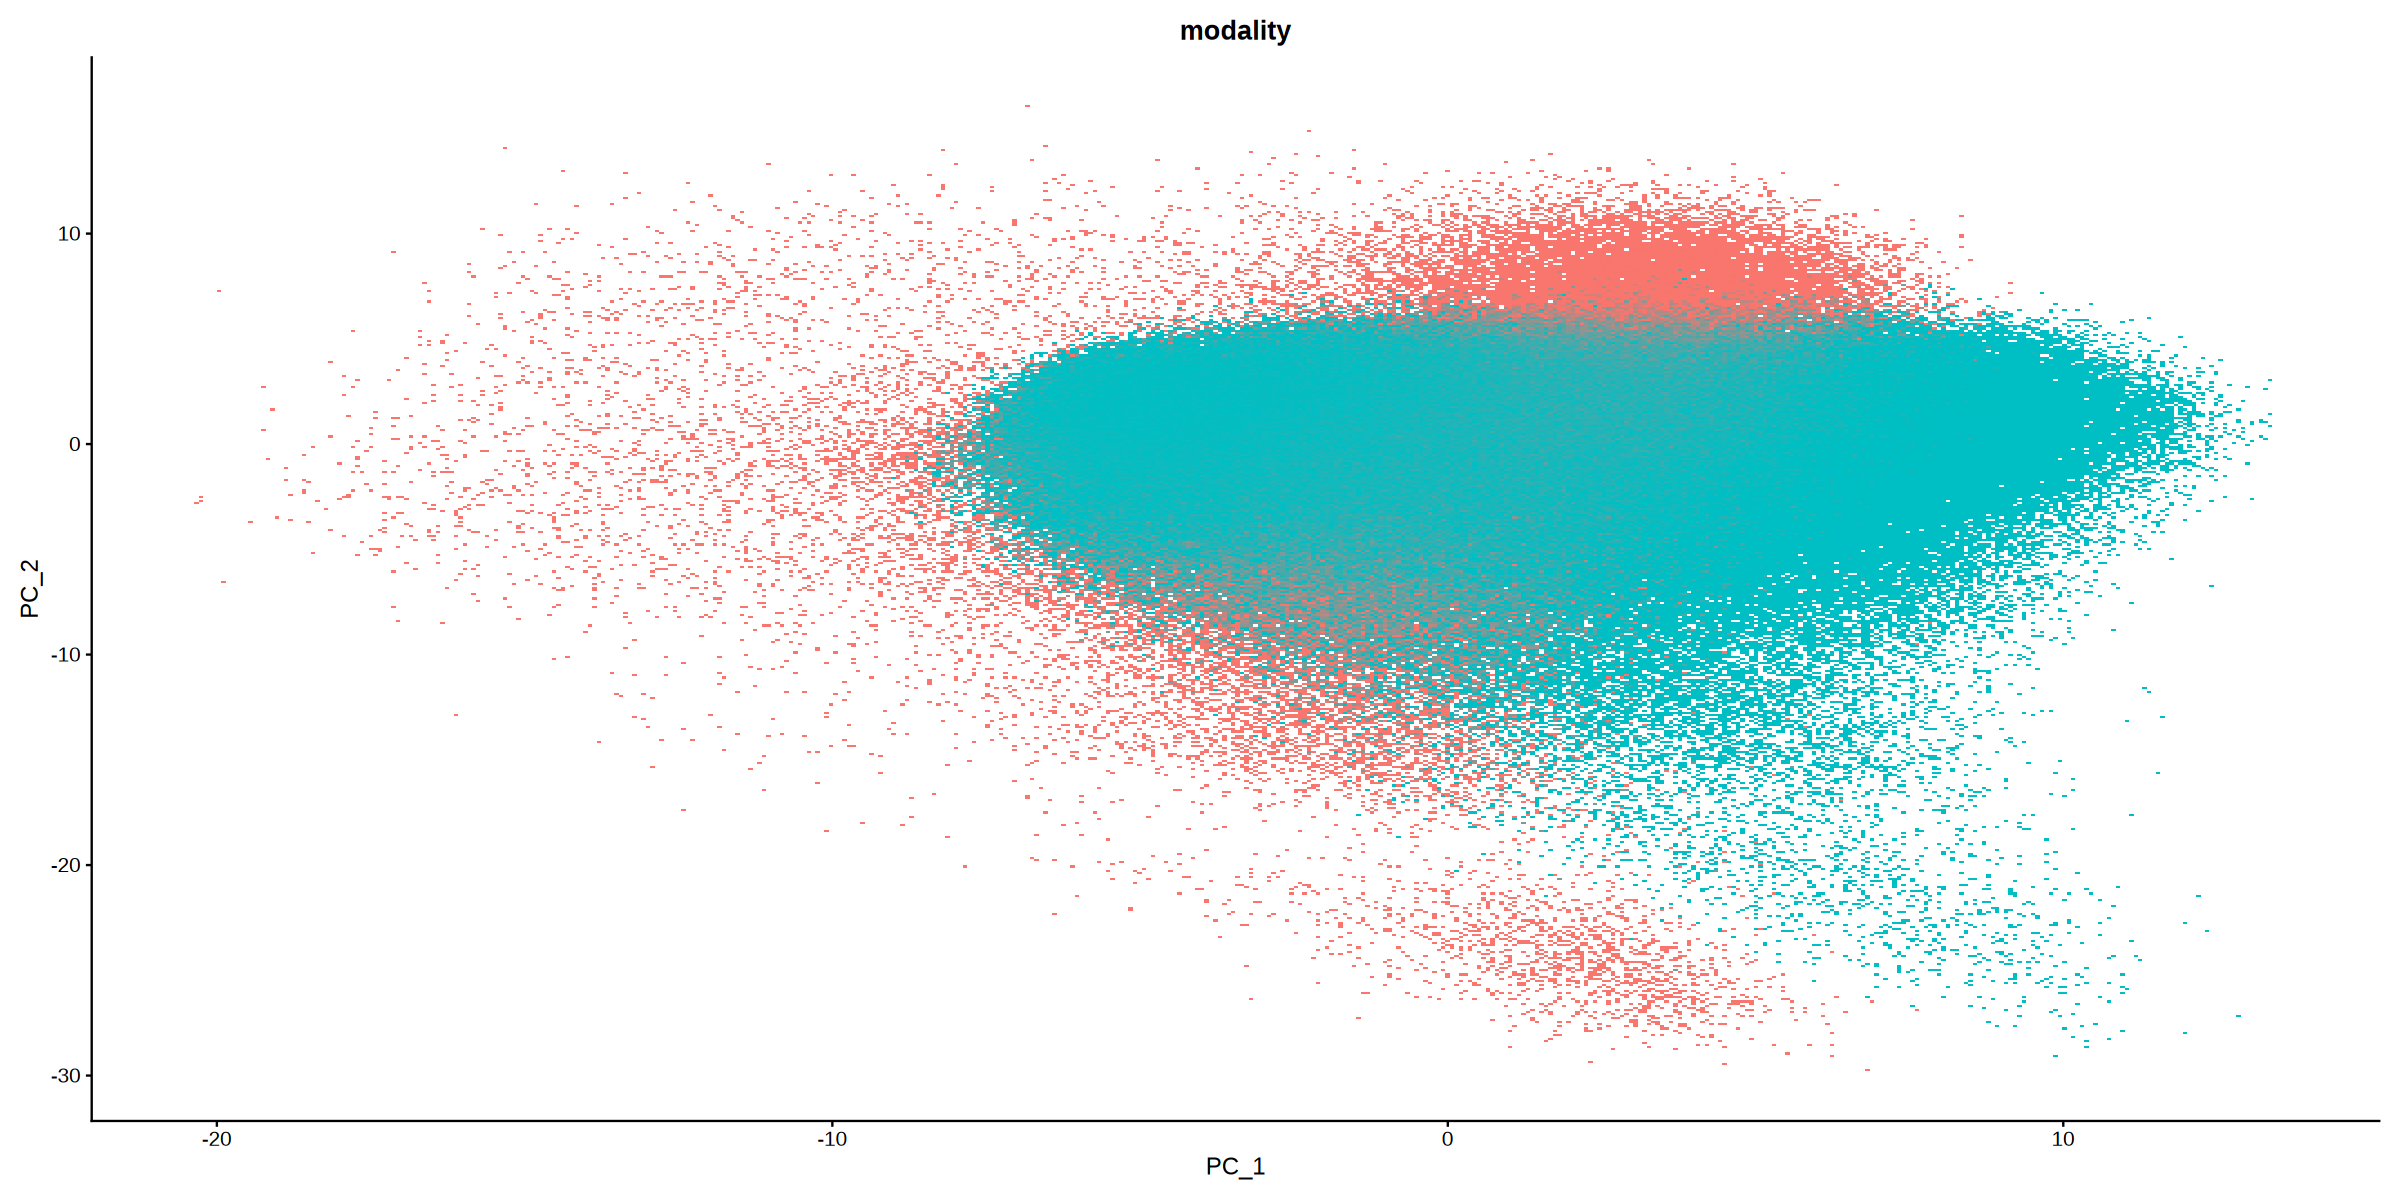

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 30556050)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony 8/10

Harmony 9/10

Harmony 10/10



  Printing Harmony diagnostic plots... 


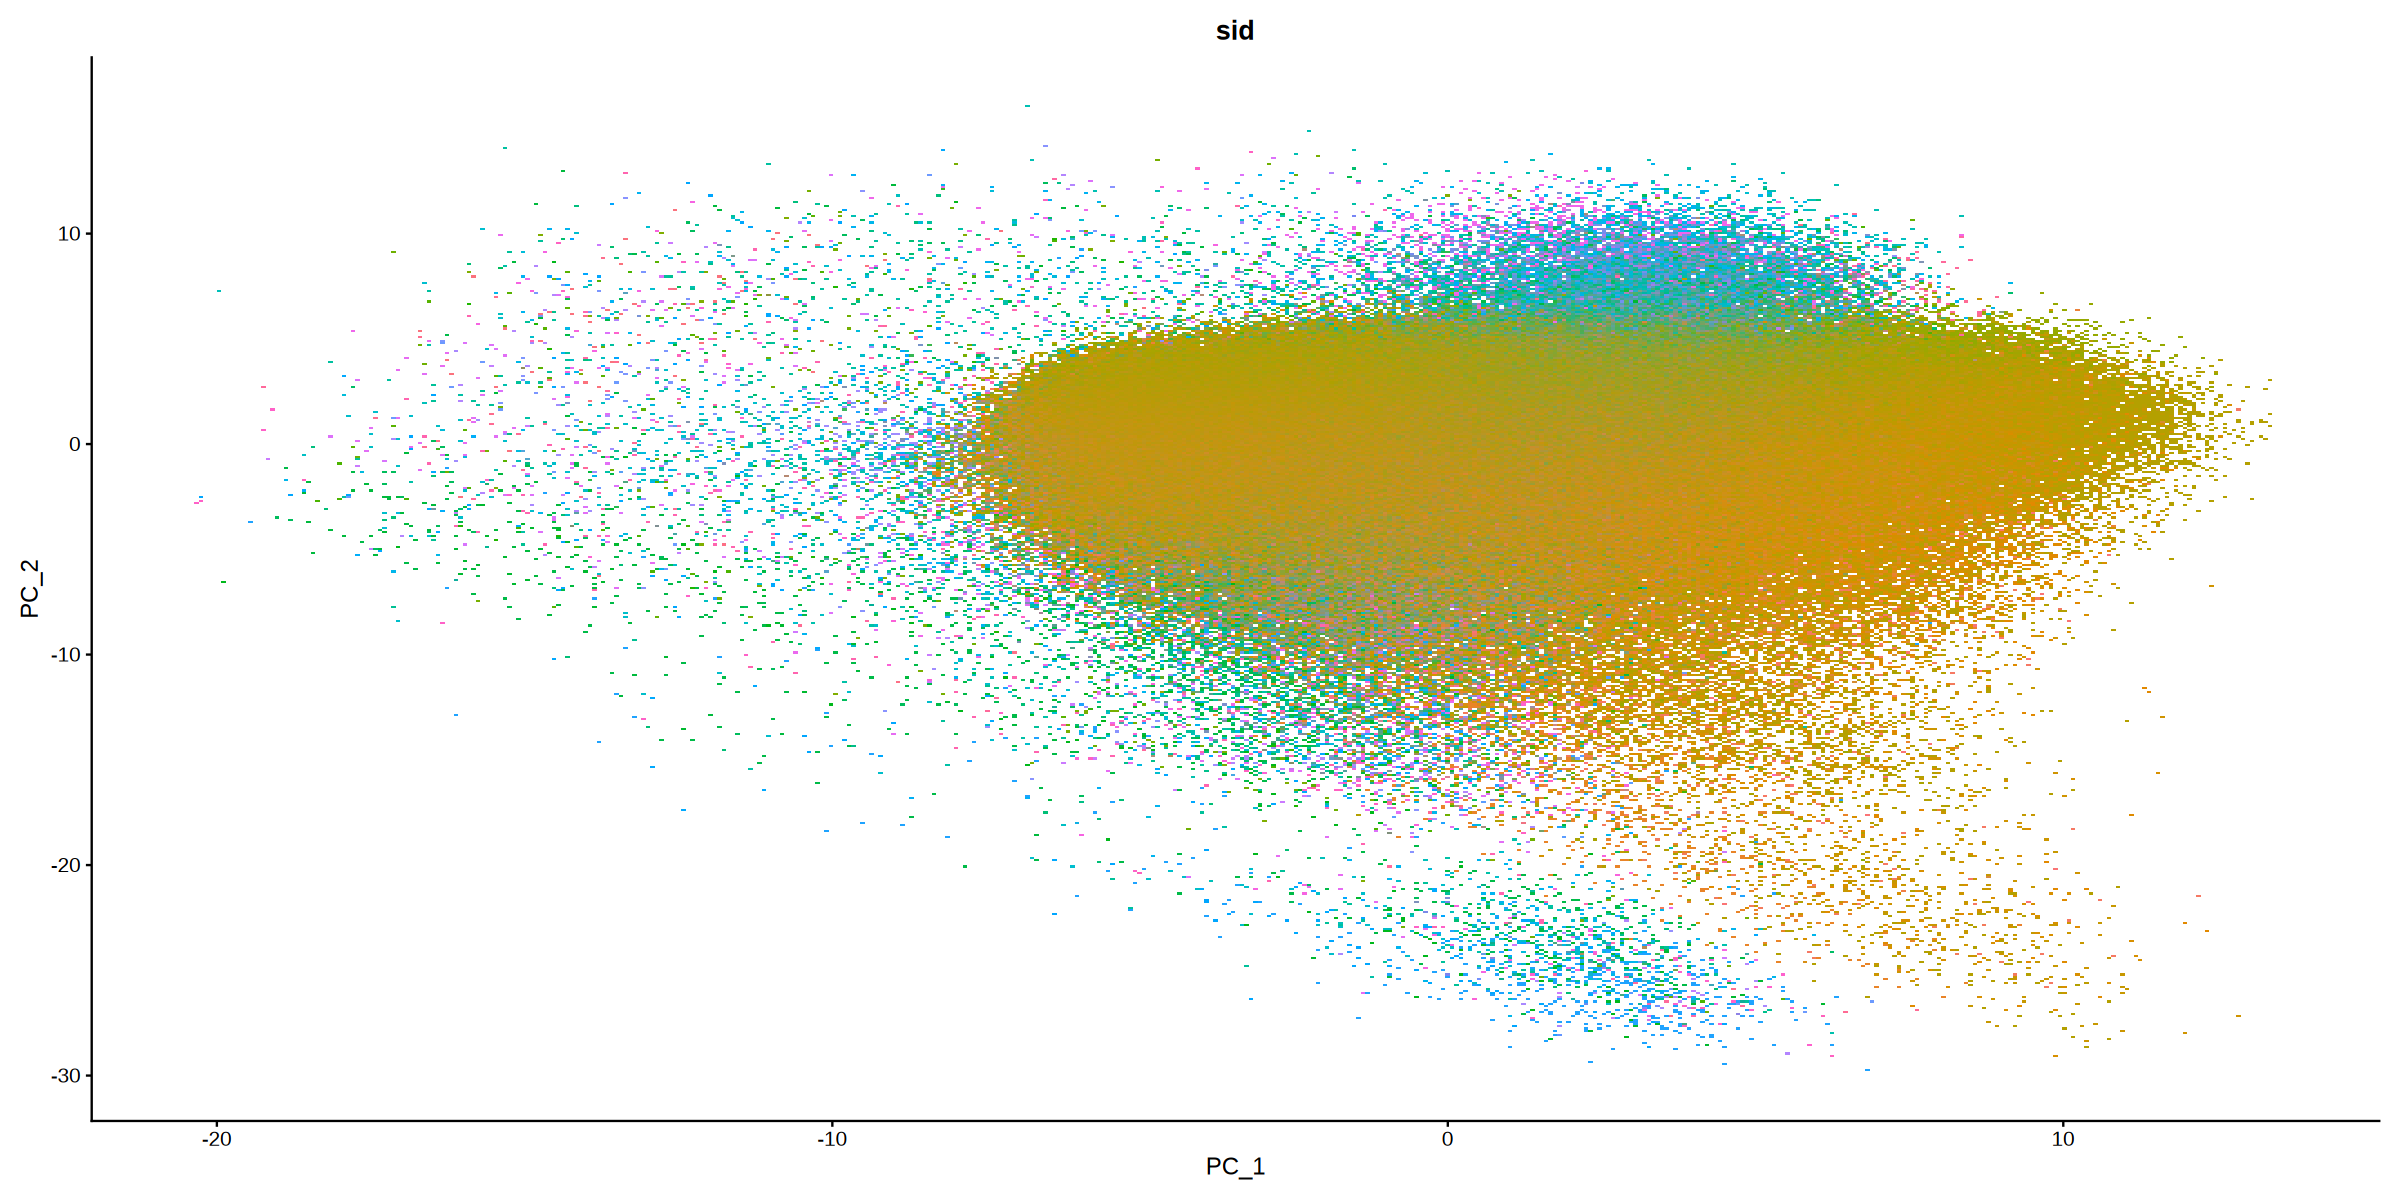

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



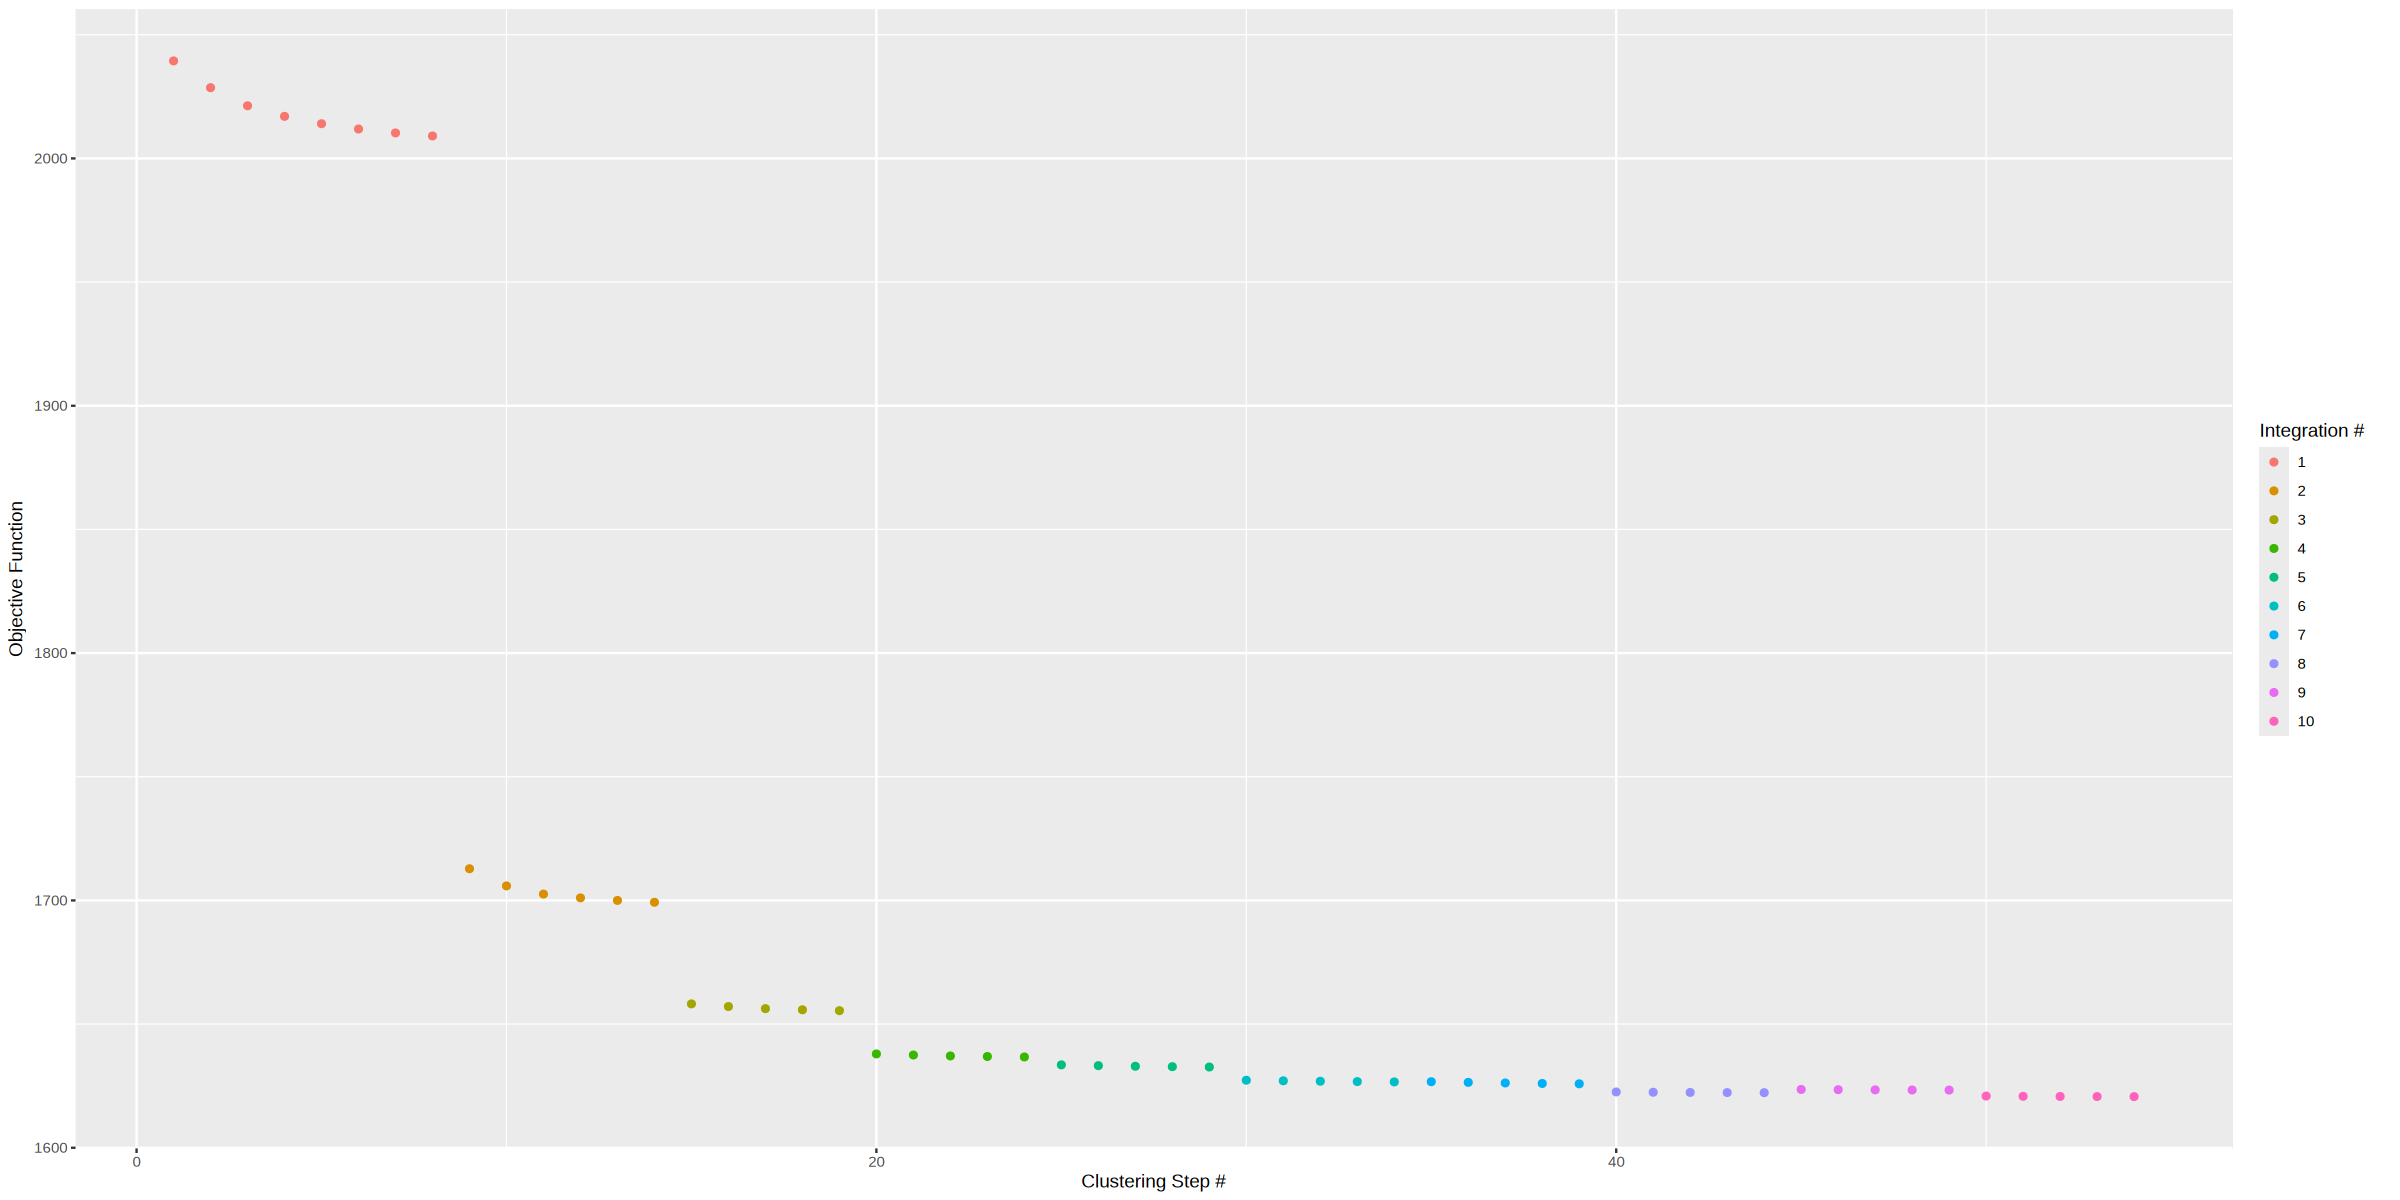

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[7/7] Running UMAP on the Harmony reduction... 


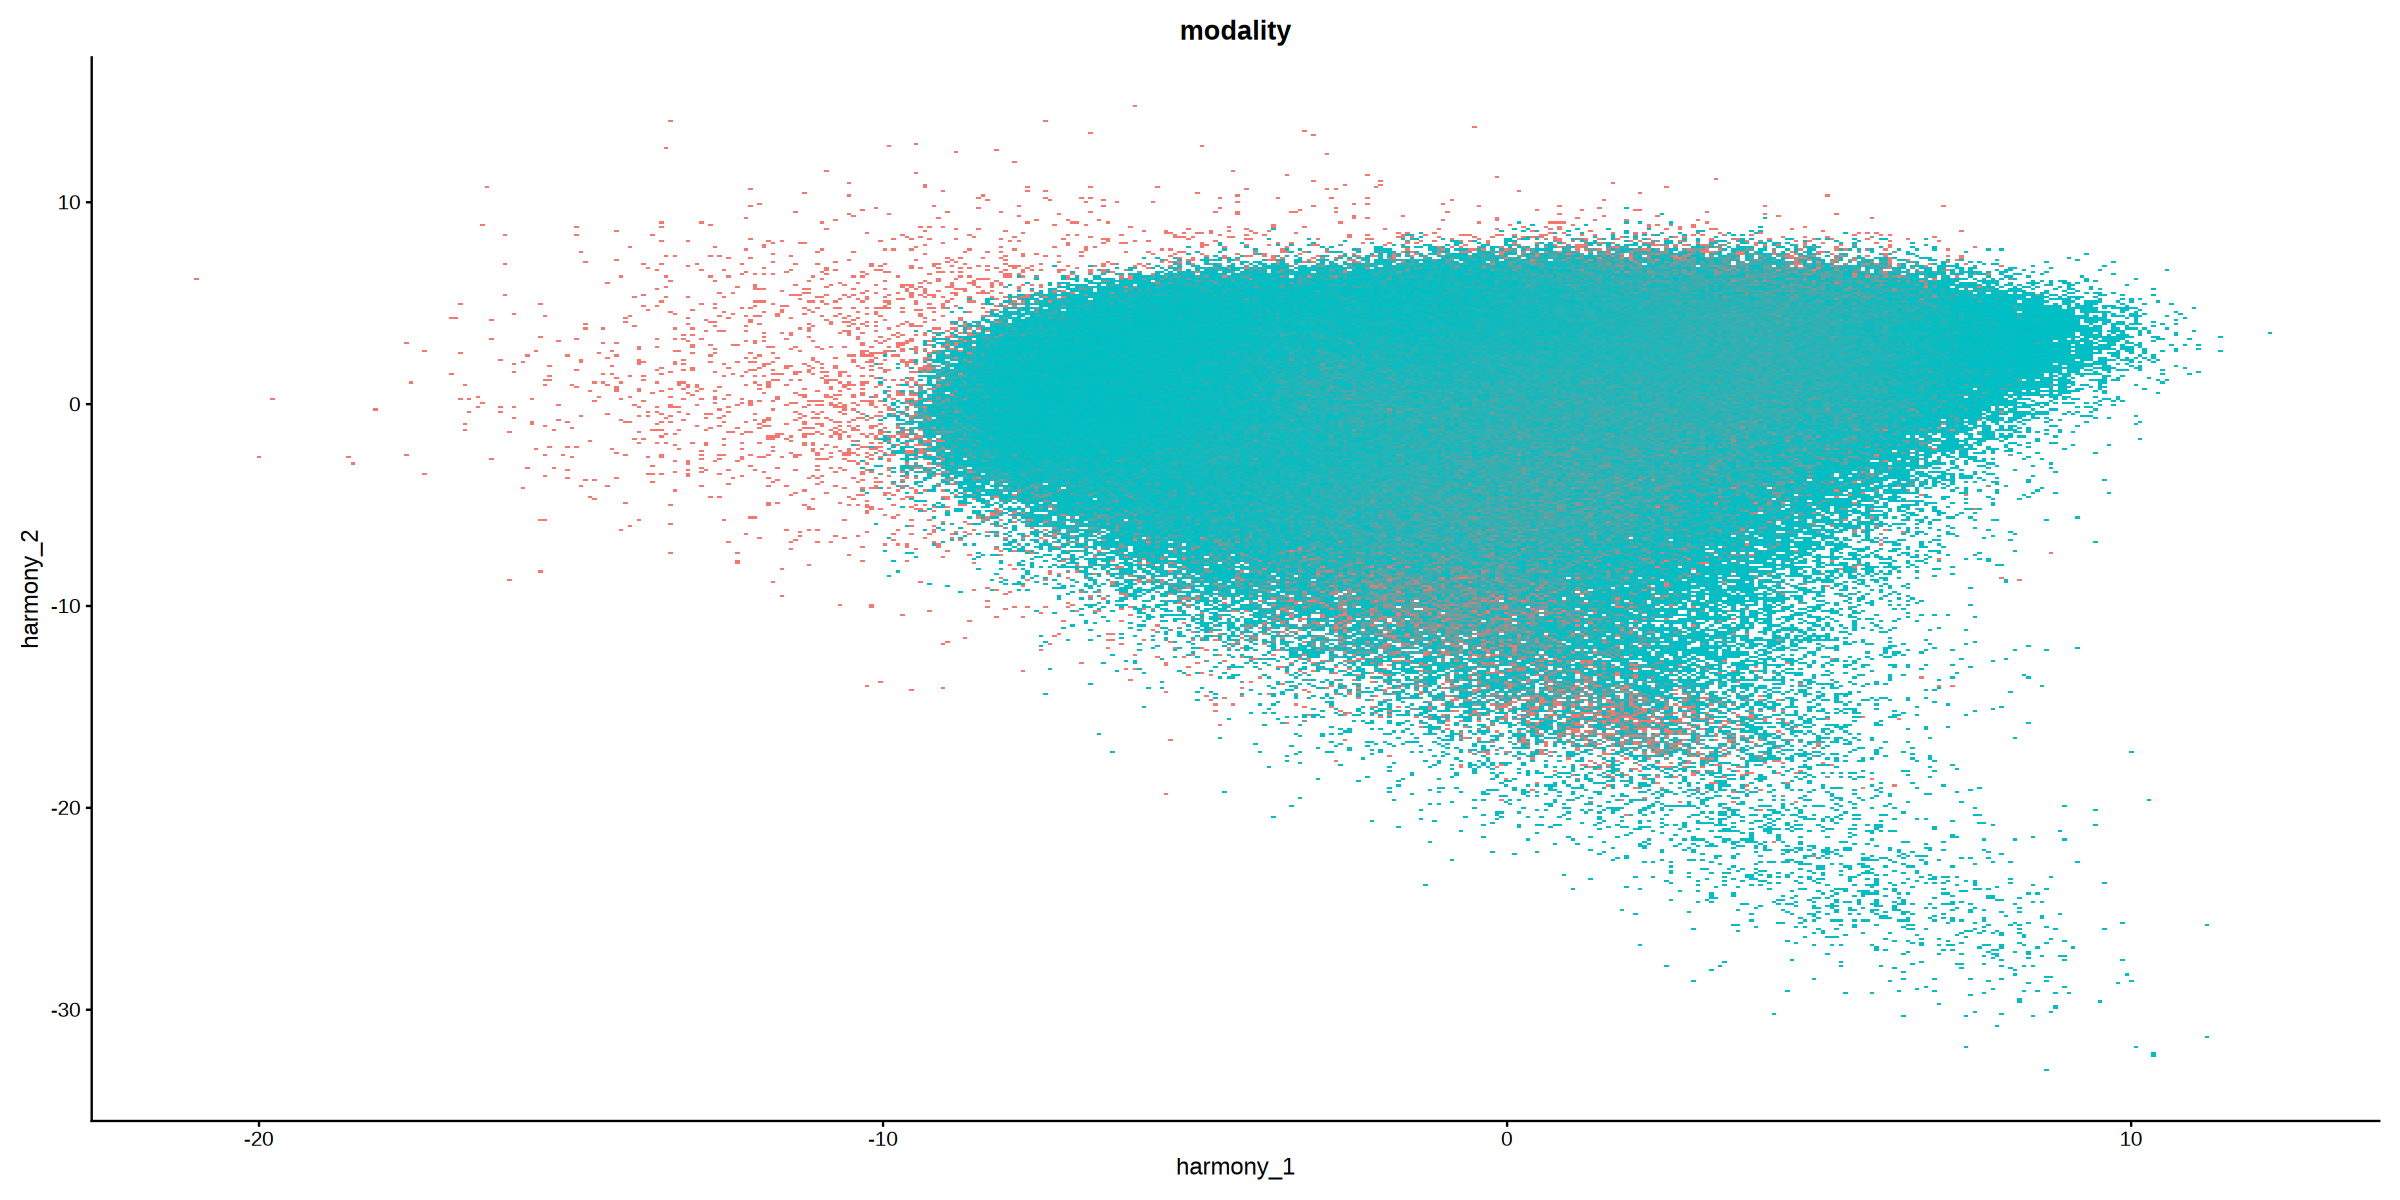

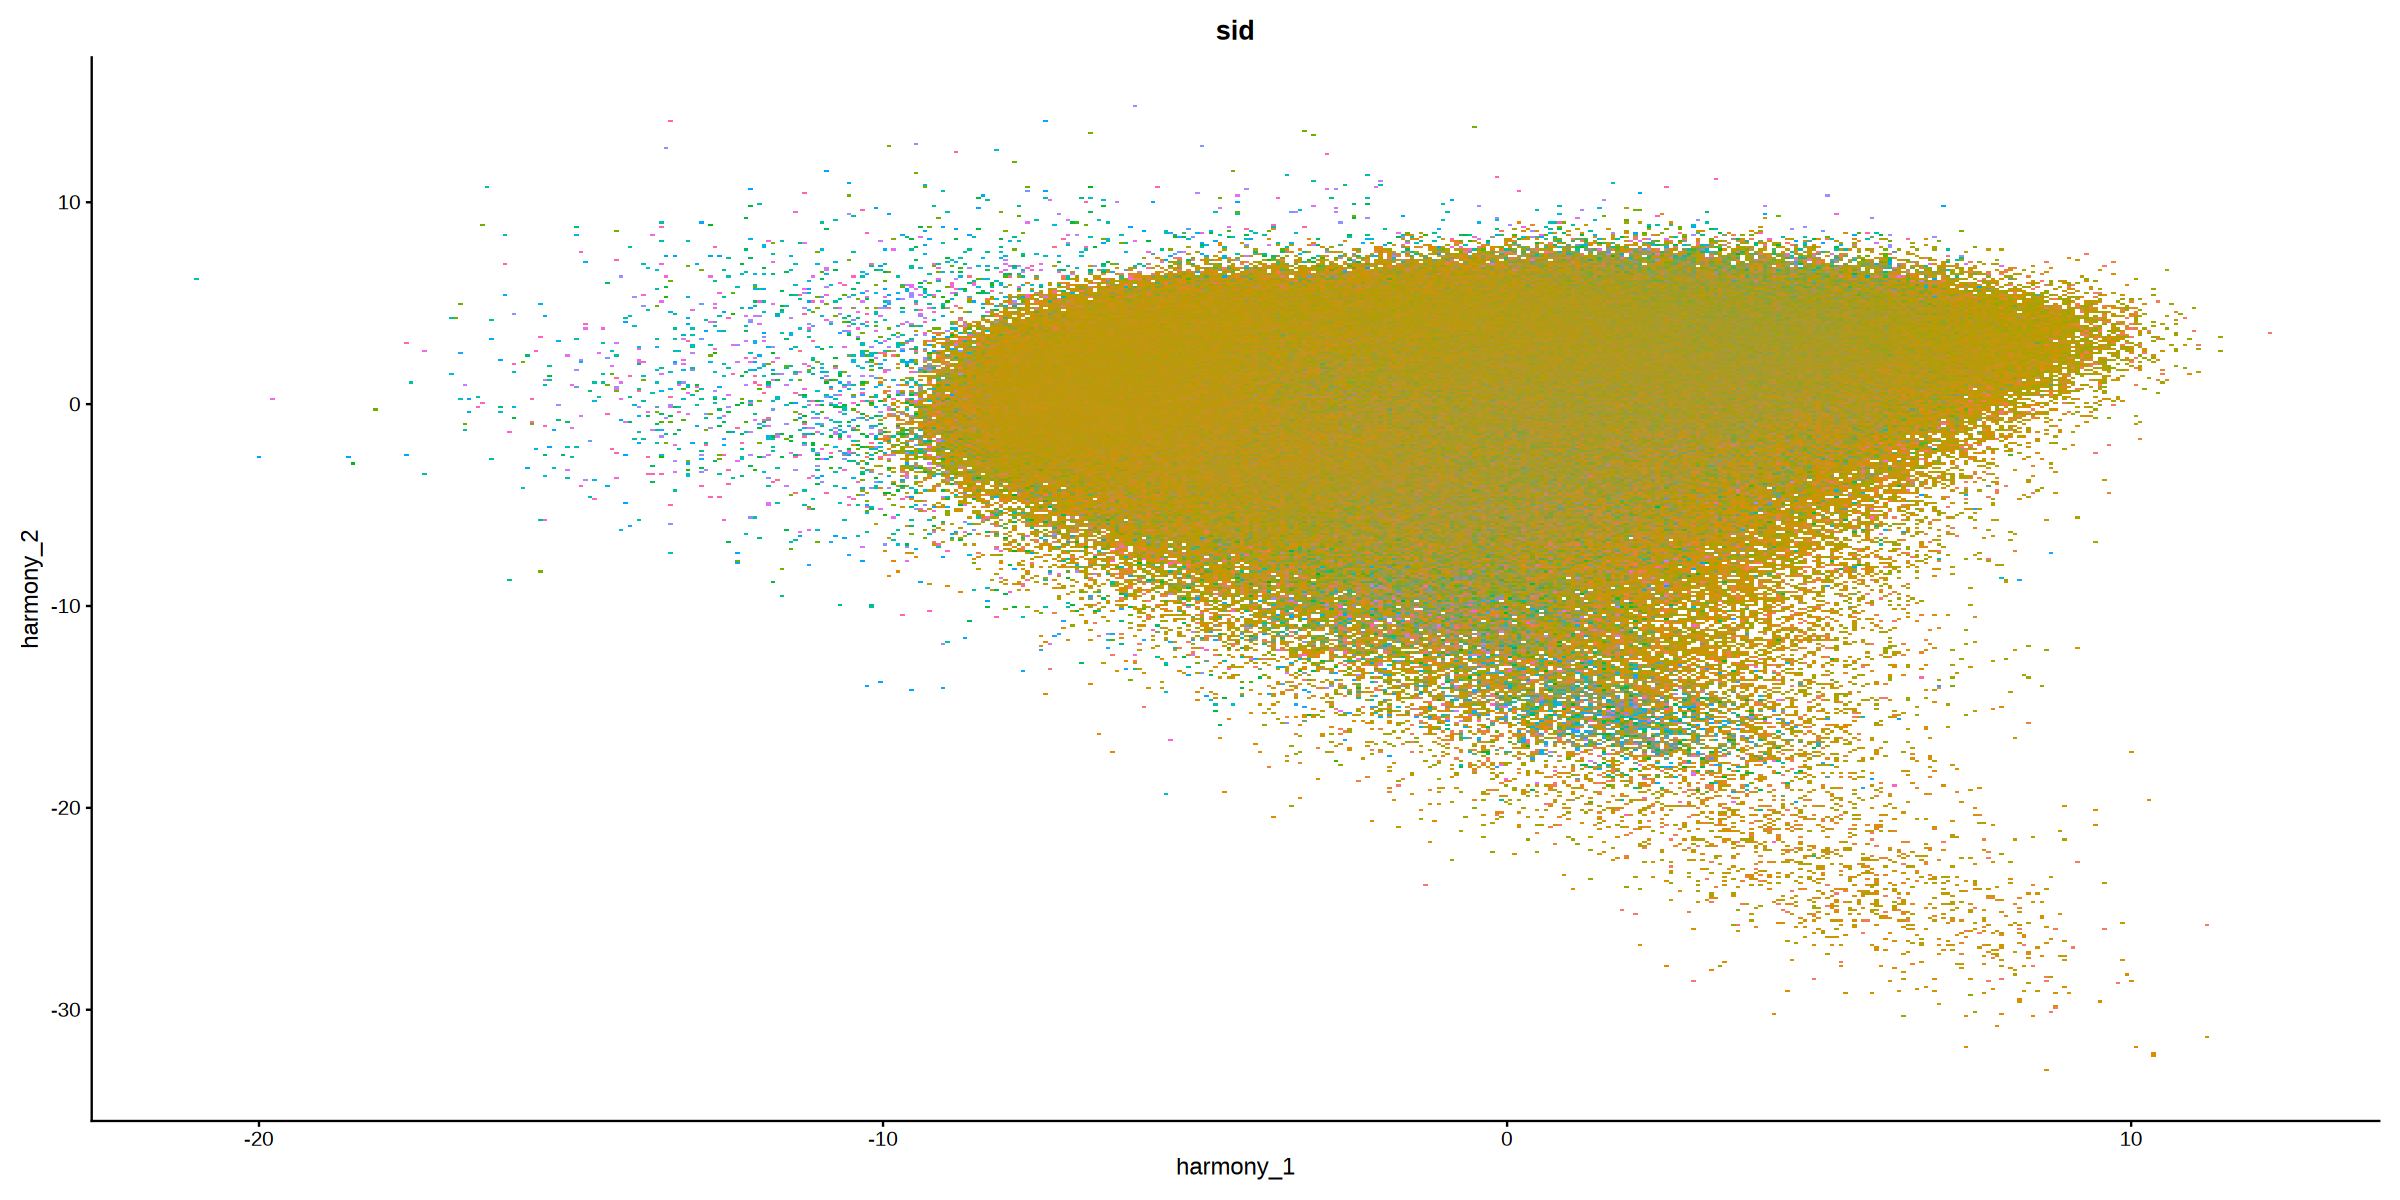

In [39]:
f_merged <- BuildIntegratedReference(
    xen = xen,
    sc = sc,
    normalization_target = "mean_of_medians",
    hvgs = hvgs,
    annotation_var = "cell_type"
)

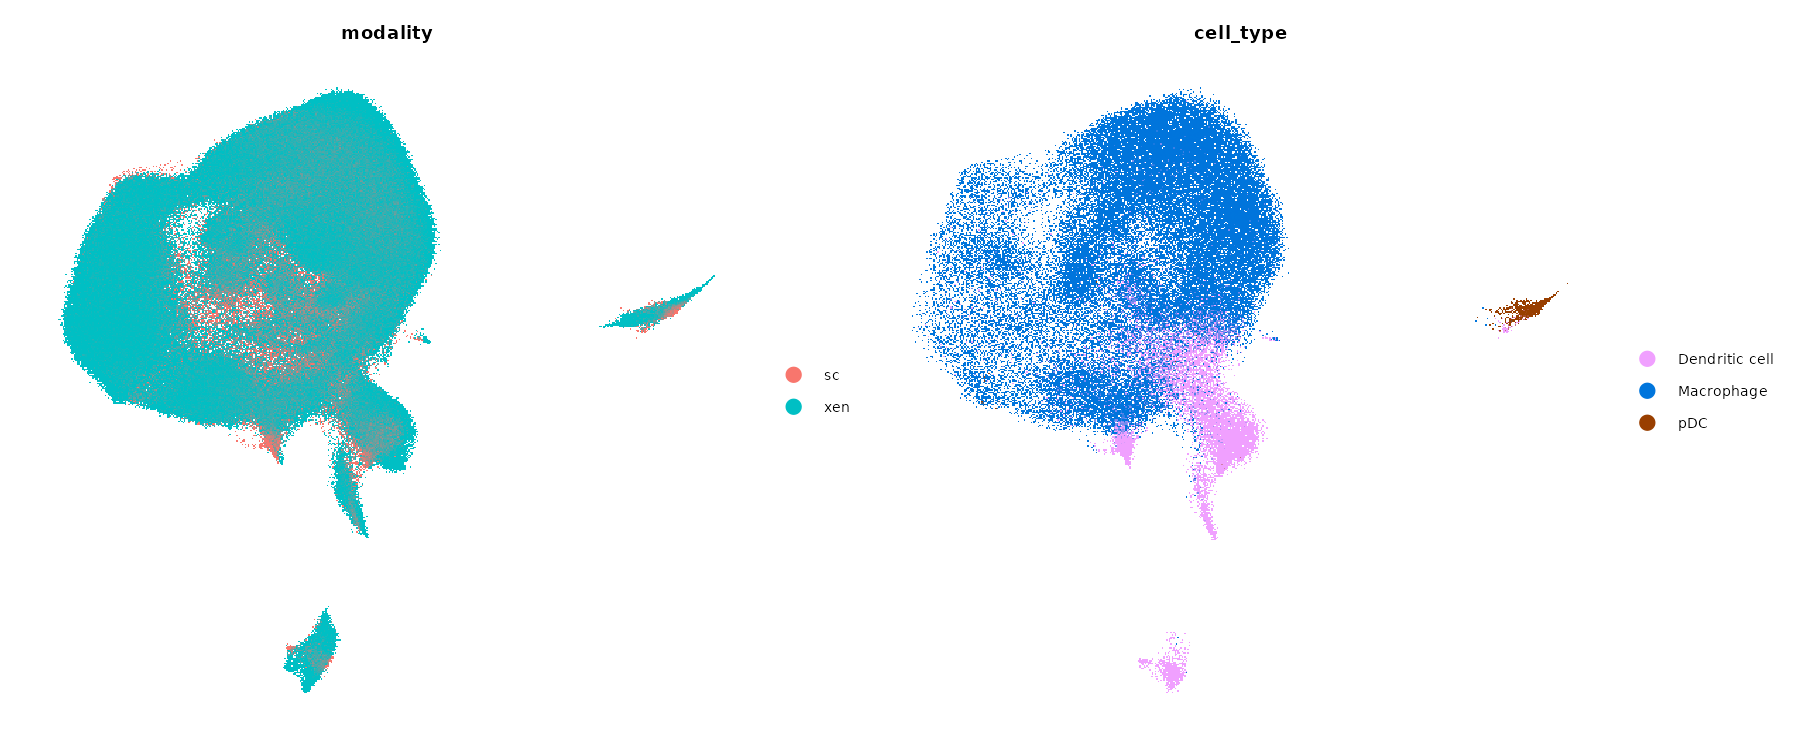

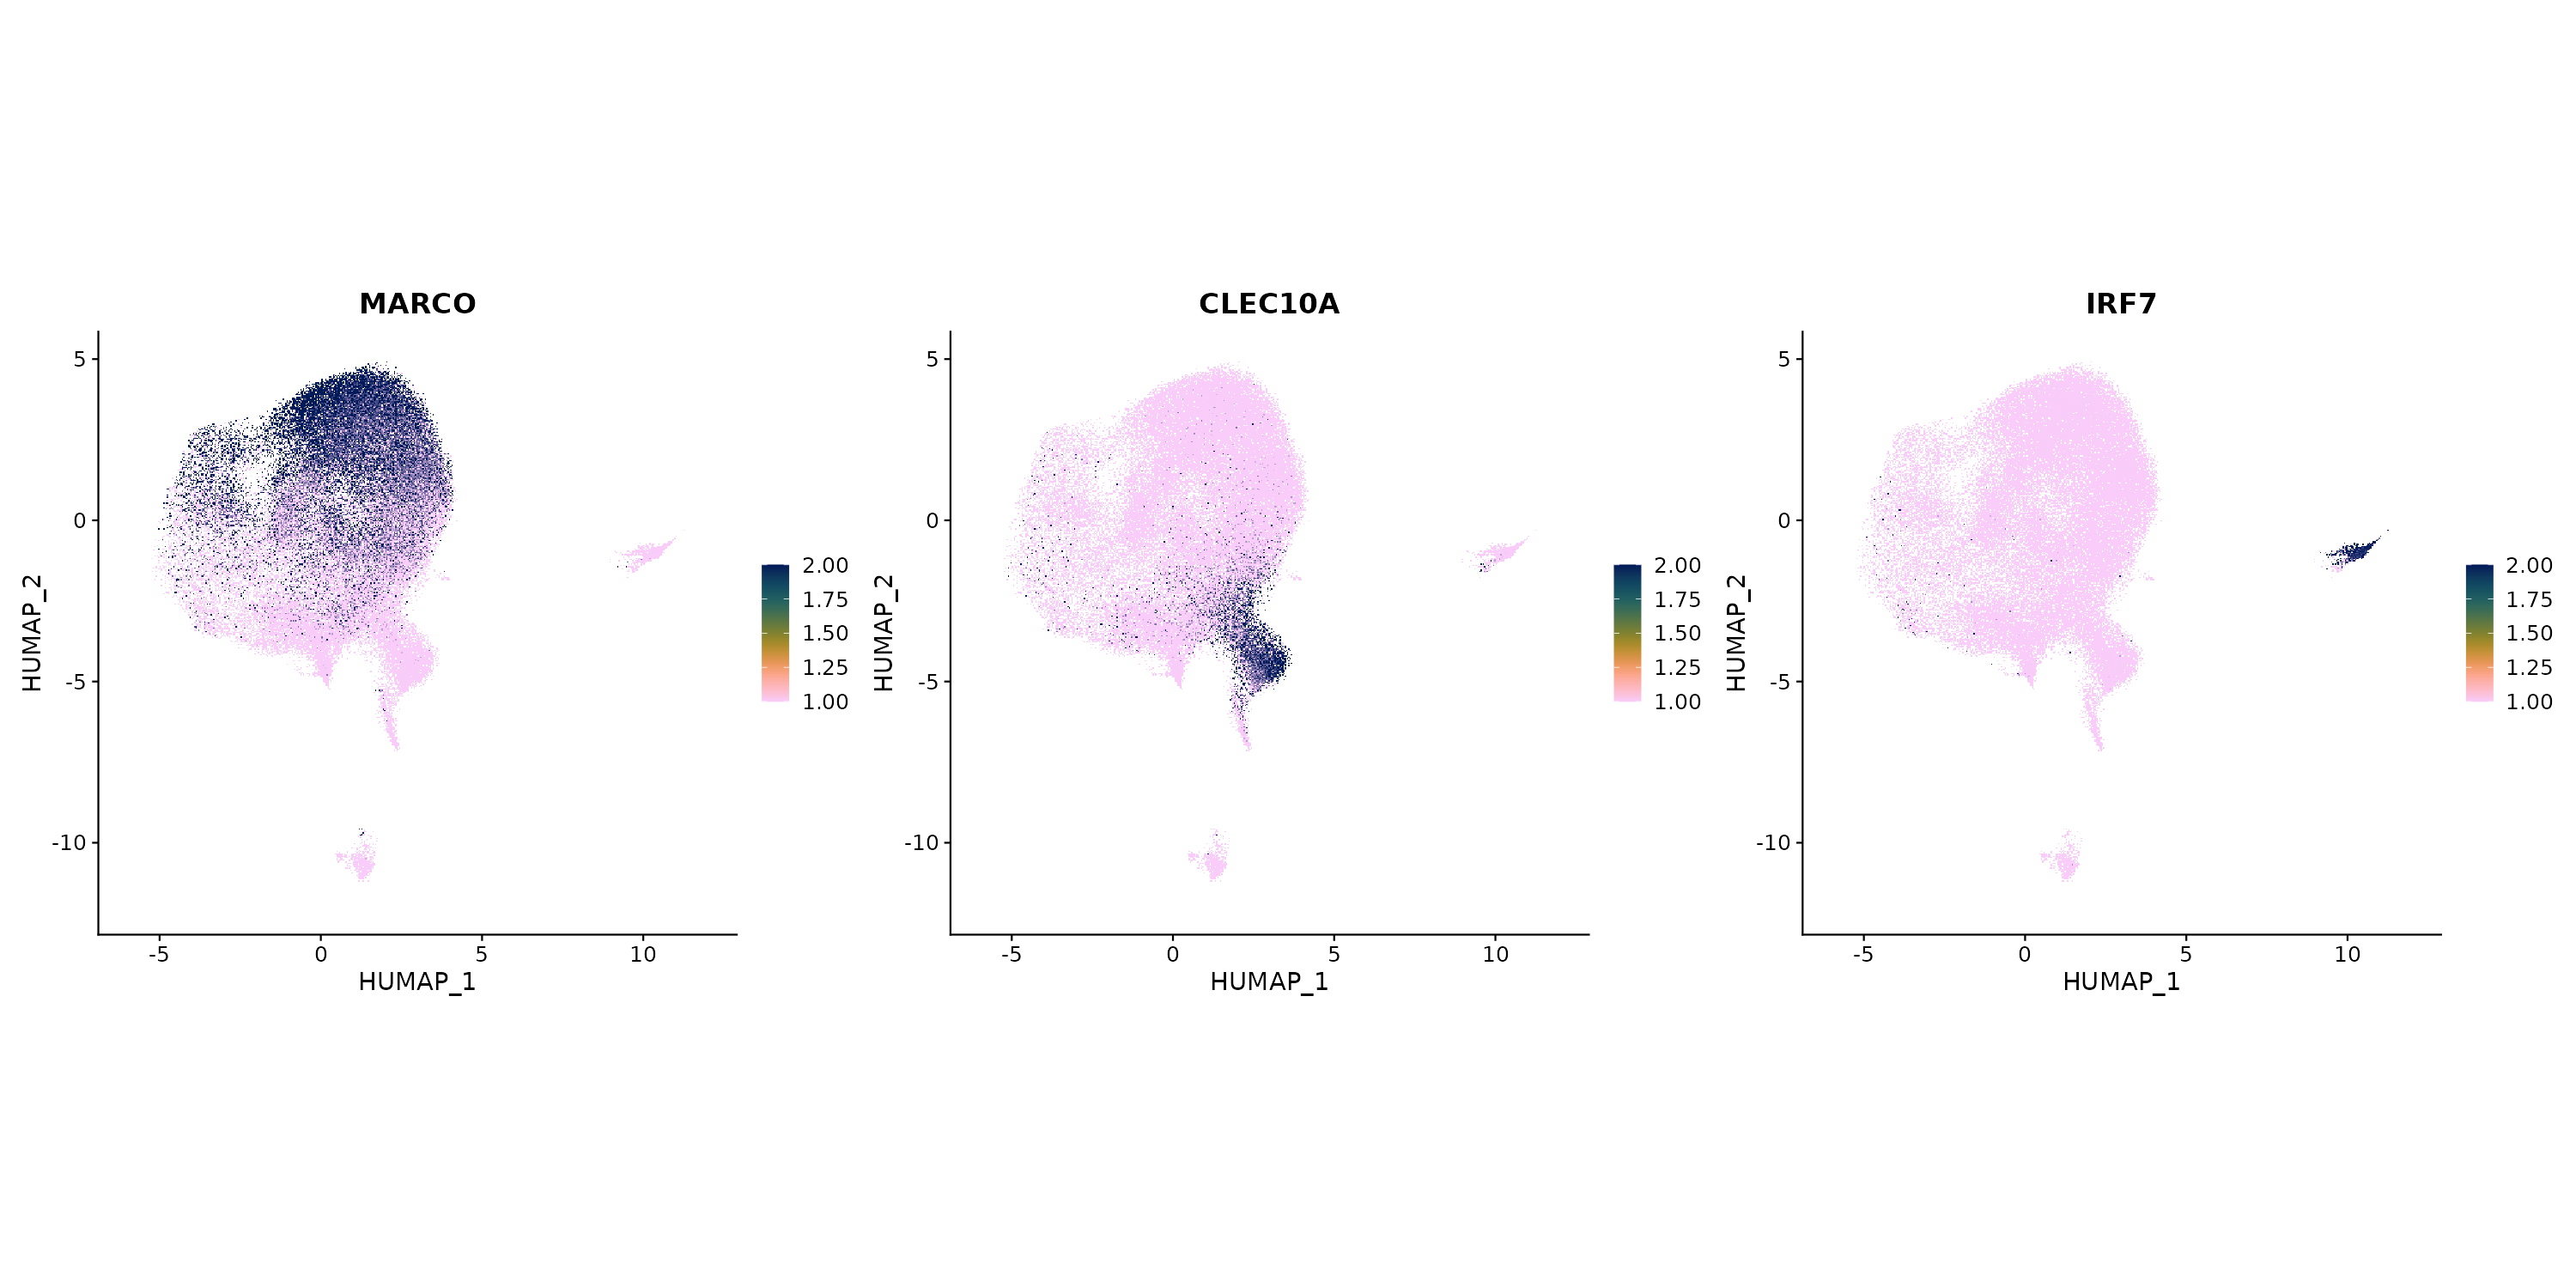

In [40]:
ShowTransferDiagnostics(
    merged = f_merged,
    annotation_var = "cell_type",
    genes_to_visualize = c("MARCO", "CLEC10A", "IRF7")
)

## Label transfer


[1/4] Checking inputs... 
  Using annotation variable: cell_type 
  Using n_neighbors = 50 and min_ratio = 1.1 

[2/4] Computing nearest-neighbor graph from Harmony embedding... 
  Graph computation complete. 

[3/4] Transferring labels from sc cells to xen cells... 
  Labels written to: cell_type 
  Xen cells without transferred labels: 85748 

[4/4] Plotting unlabeled cells and final xen label map... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



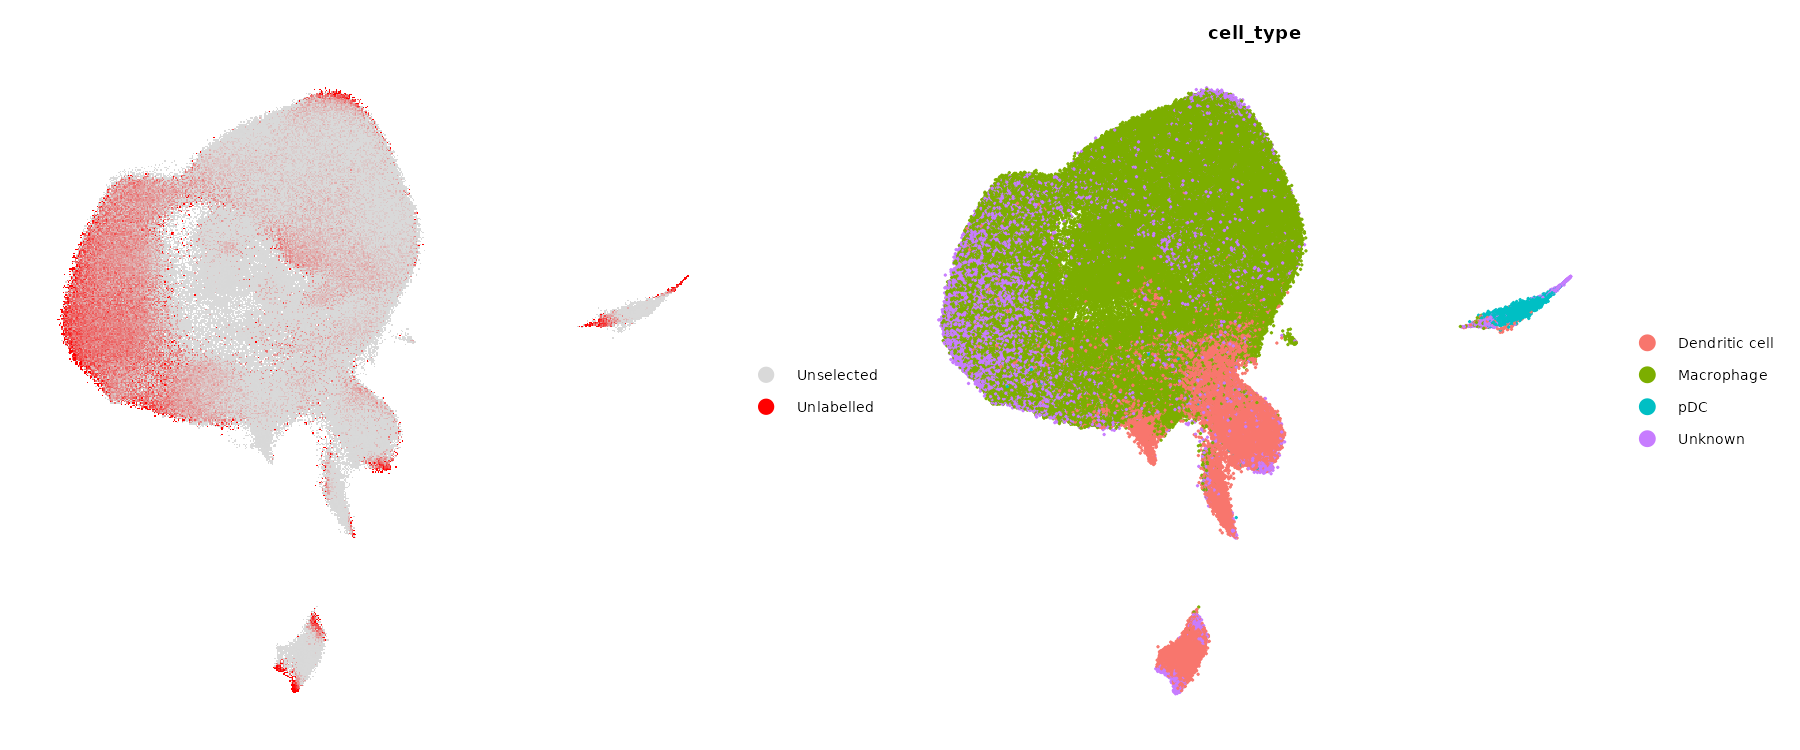

In [41]:
source('typing_utils.r')
f_merged <- TransferLabelsGraph(
    merged = f_merged,
    annotation_var = "cell_type",
    n_neighbors = 50,
    min_ratio = 1.1
)

## Examine marker genes

In [42]:
# verify that the new lining vs sublining assignment is better than the one from the coarse typing notebook
expr <- GetAssayData(xen, layer = "data")
clusters.markers.original <- presto::wilcoxauc(expr, xen[["cell_type"]][,1])

expr <- GetAssayData(f_merged[, f_merged$modality == "xen"], layer = "data")
clusters.markers.new <- presto::wilcoxauc(expr, f_merged[, f_merged$modality == "xen"][["cell_type"]][,1])

expr <- GetAssayData(f_merged[, f_merged$modality == "sc"], layer = "data")
clusters.markers.truth <- presto::wilcoxauc(expr, f_merged[, f_merged$modality == "sc"][["cell_type"]][,1])

[1] 0.7141962

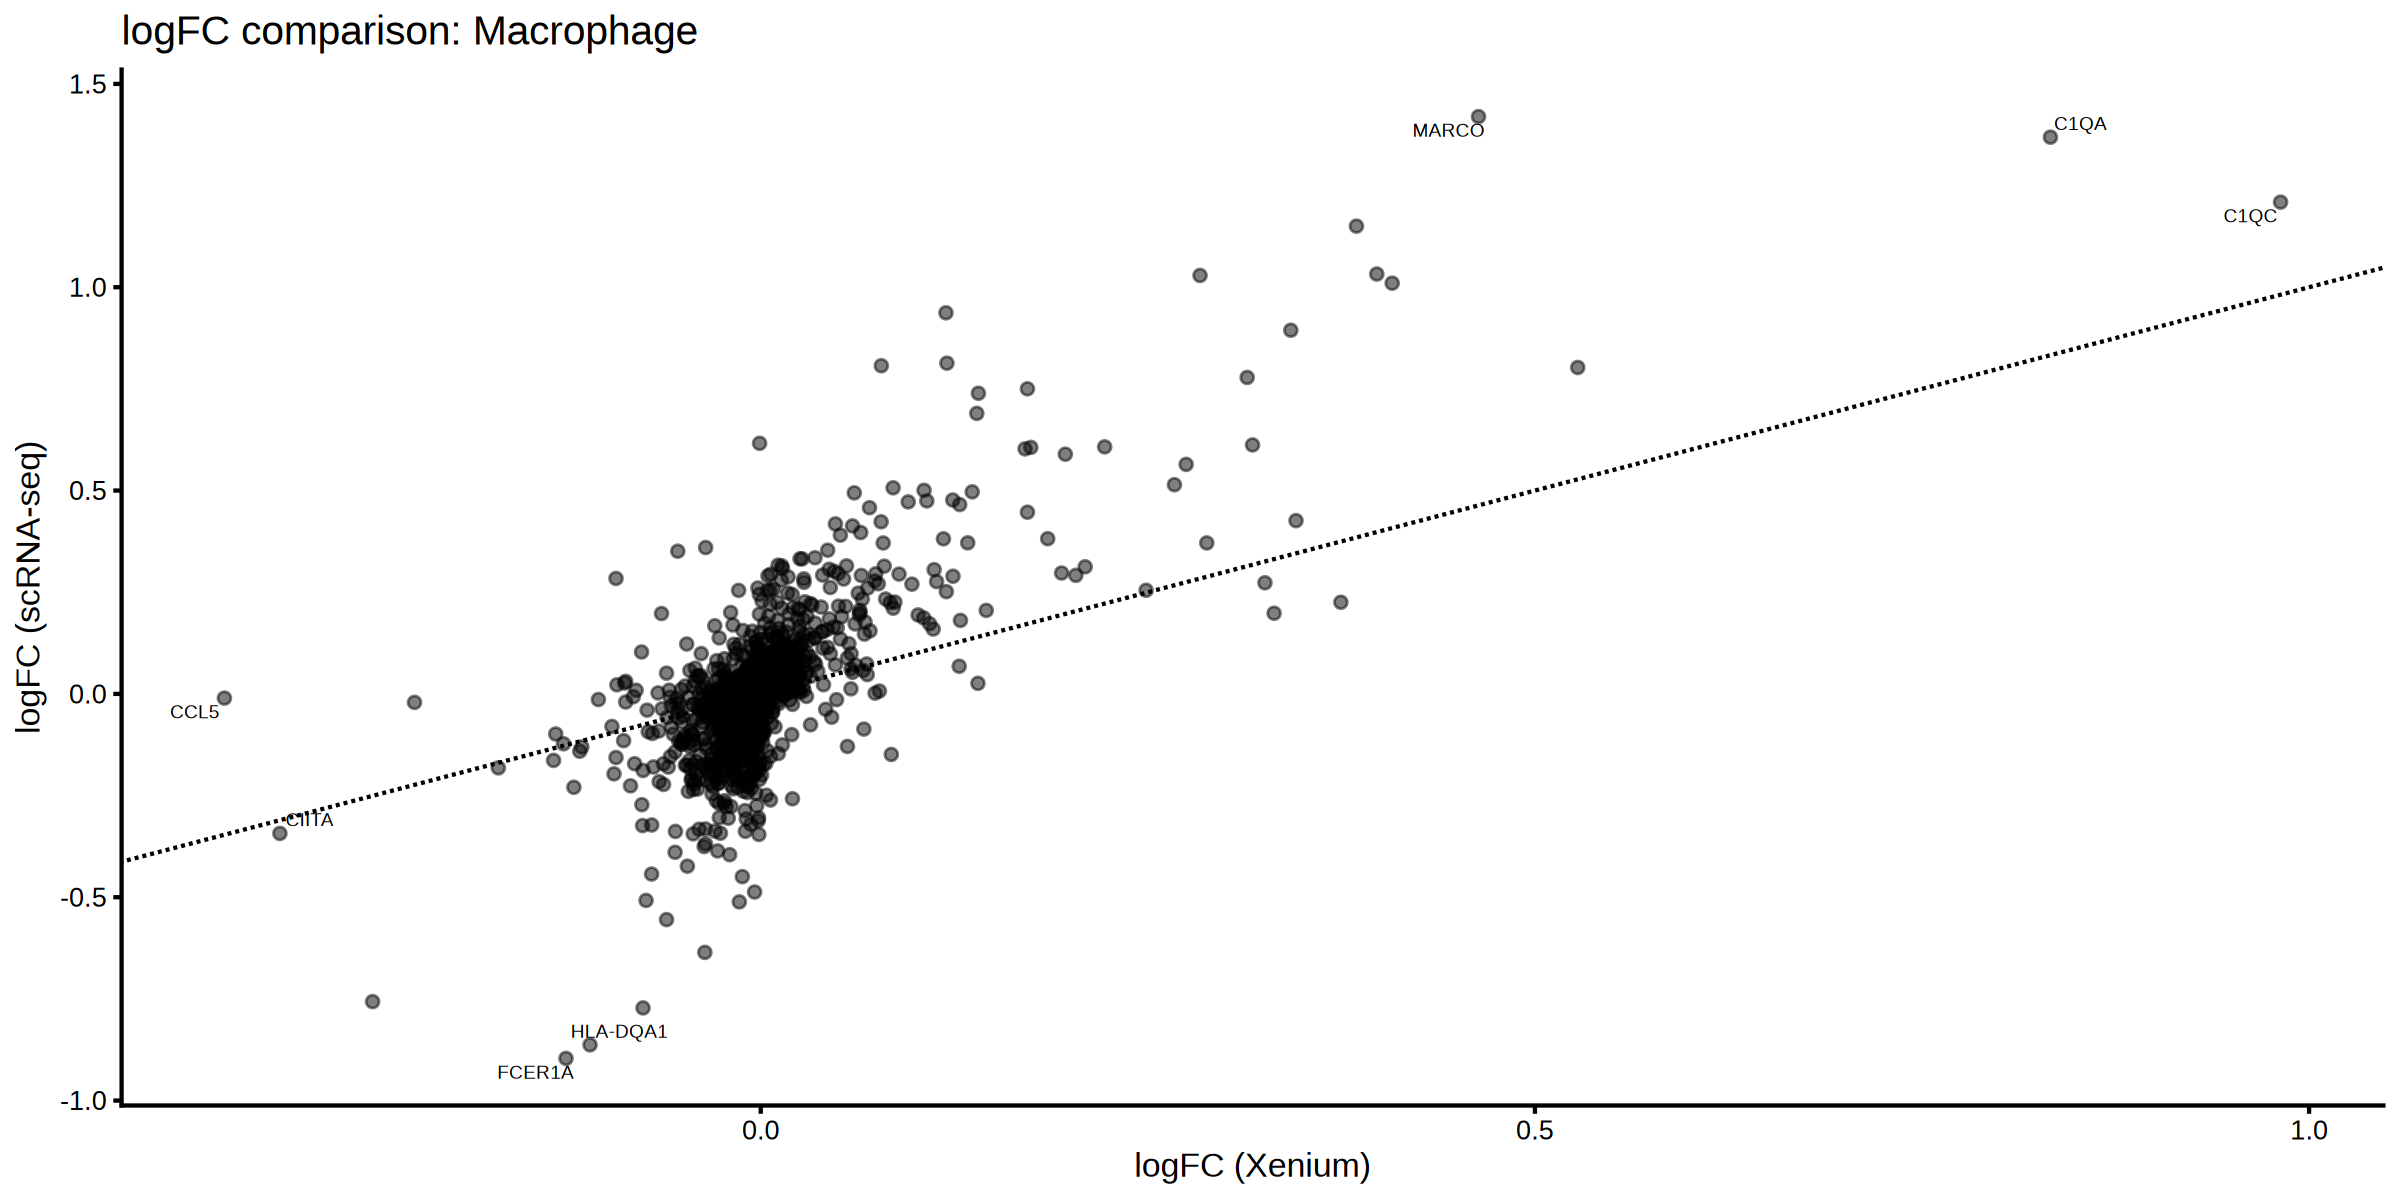

In [43]:
# old mac vs l assignment
PlotStateLogFCComparison(
  markers_sc = clusters.markers.truth,
  markers_xen = clusters.markers.original,
  cell_state = "Macrophage"
)$correlation

[1] 0.7661731

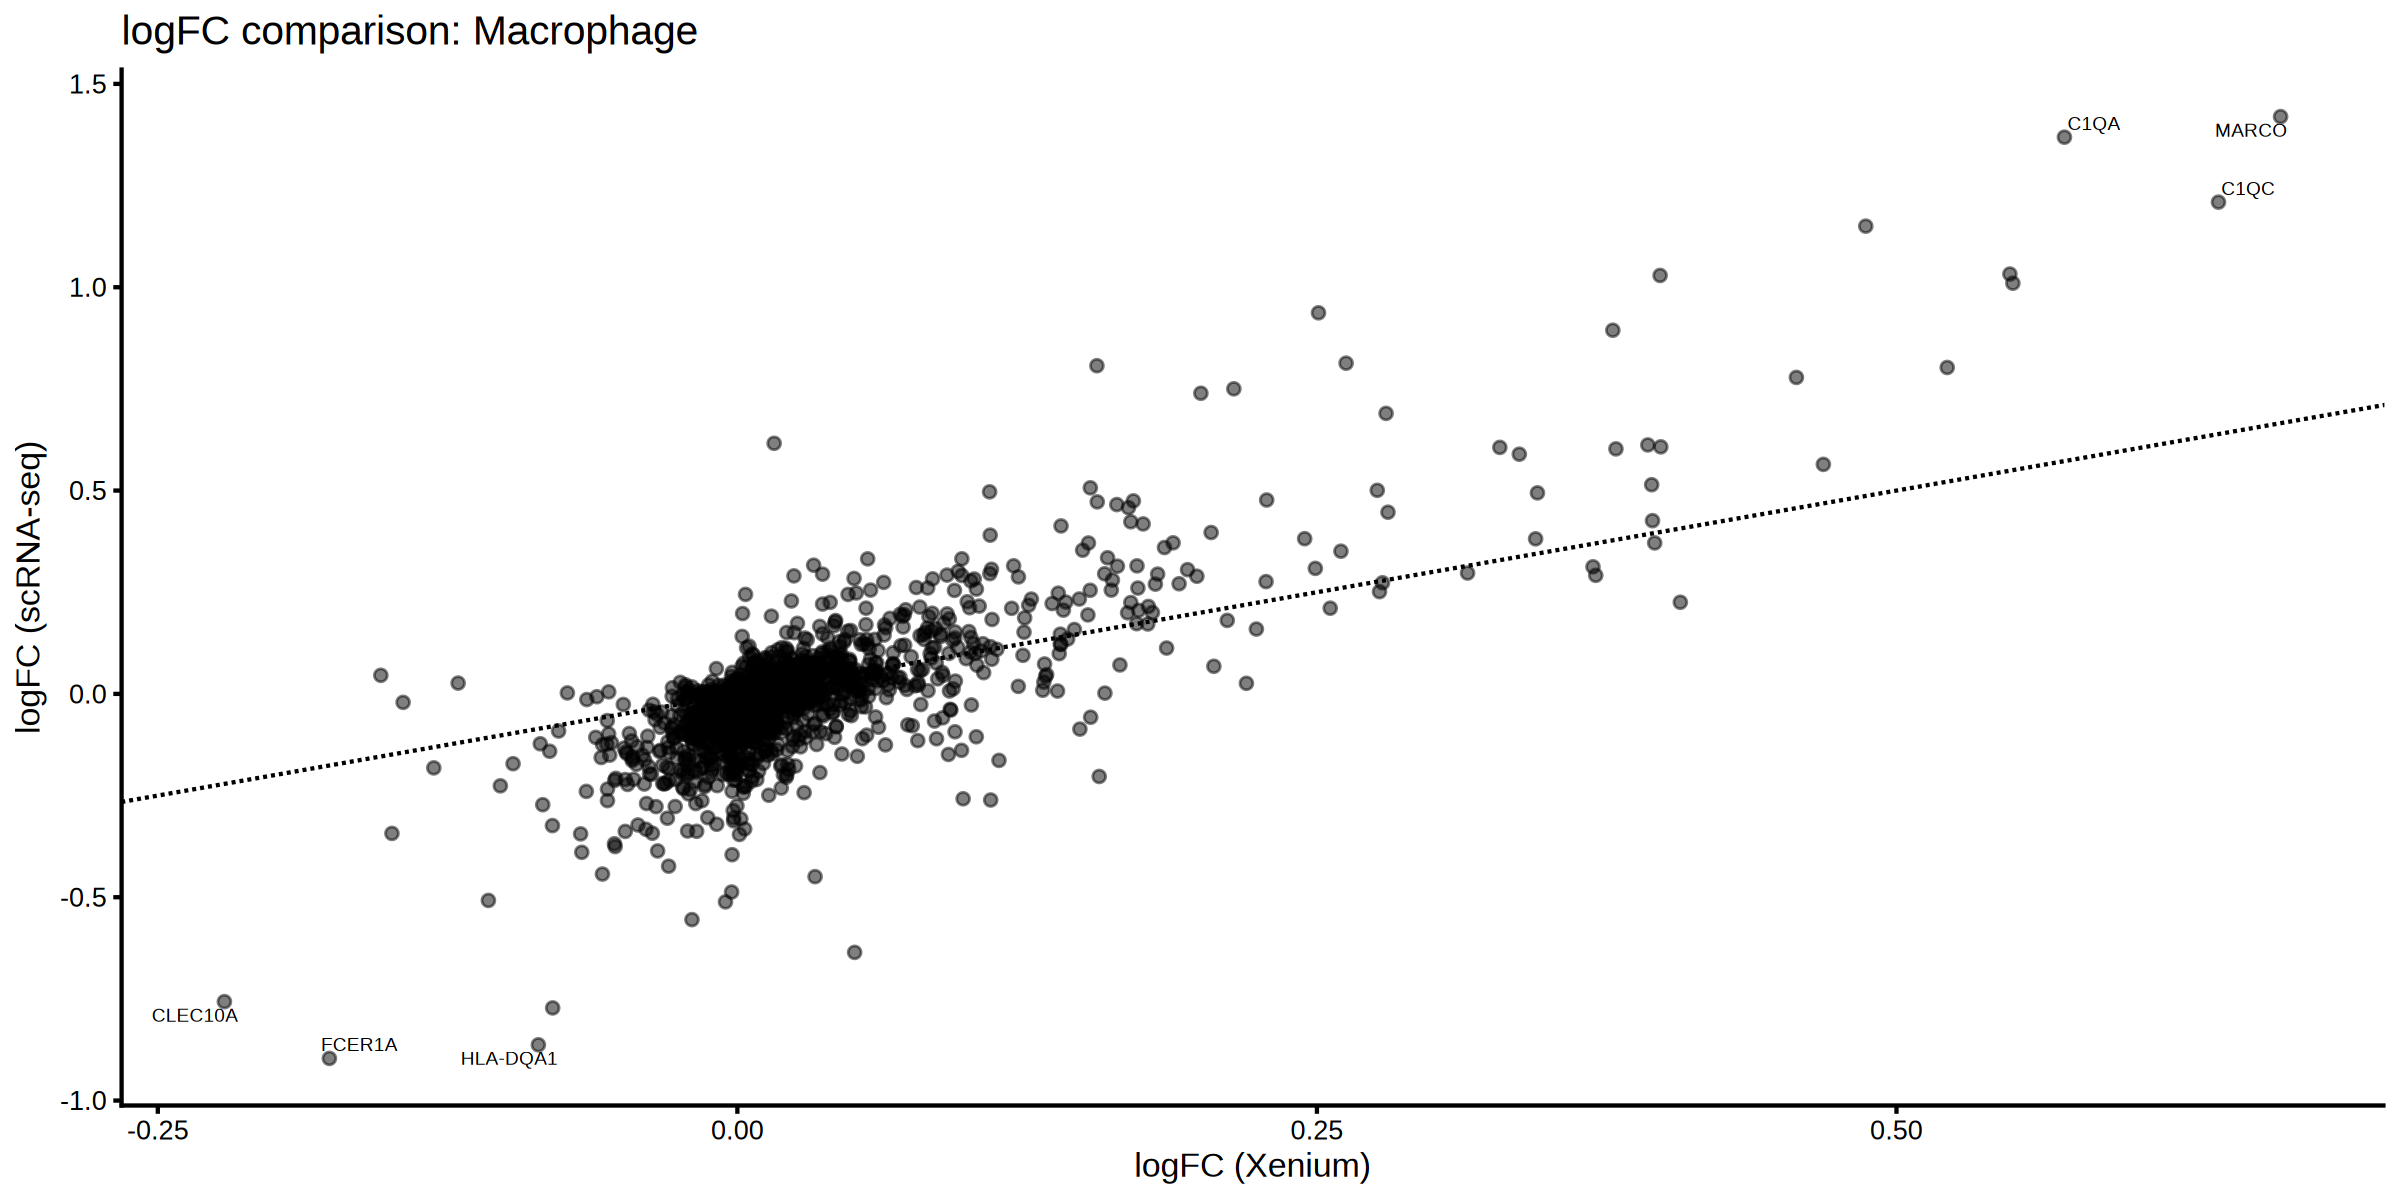

In [44]:
# new mac vs l assignment
PlotStateLogFCComparison(
  markers_sc = clusters.markers.truth,
  markers_xen = clusters.markers.new,
  cell_state = "Macrophage"
)$correlation

In [45]:
# examine top markers from new assignment
ShowClusterMarkers(f_merged[, f_merged$modality == "xen"], "cell_type", n_show = 5)

row,Dendritic cell,Macrophage,Unknown,pDC
<int>,<chr>,<chr>,<chr>,<chr>
1,CIITA,MARCO,F13A1,GZMB
2,CLEC10A,C1QC,CXCL12,MAPKAPK2
3,CCL5,C1QA,AEBP1,IRF7
4,HLA-DQA1,GPNMB,MZB1,IRF8
5,EEF1G,CTSL,DERL3,CCDC50


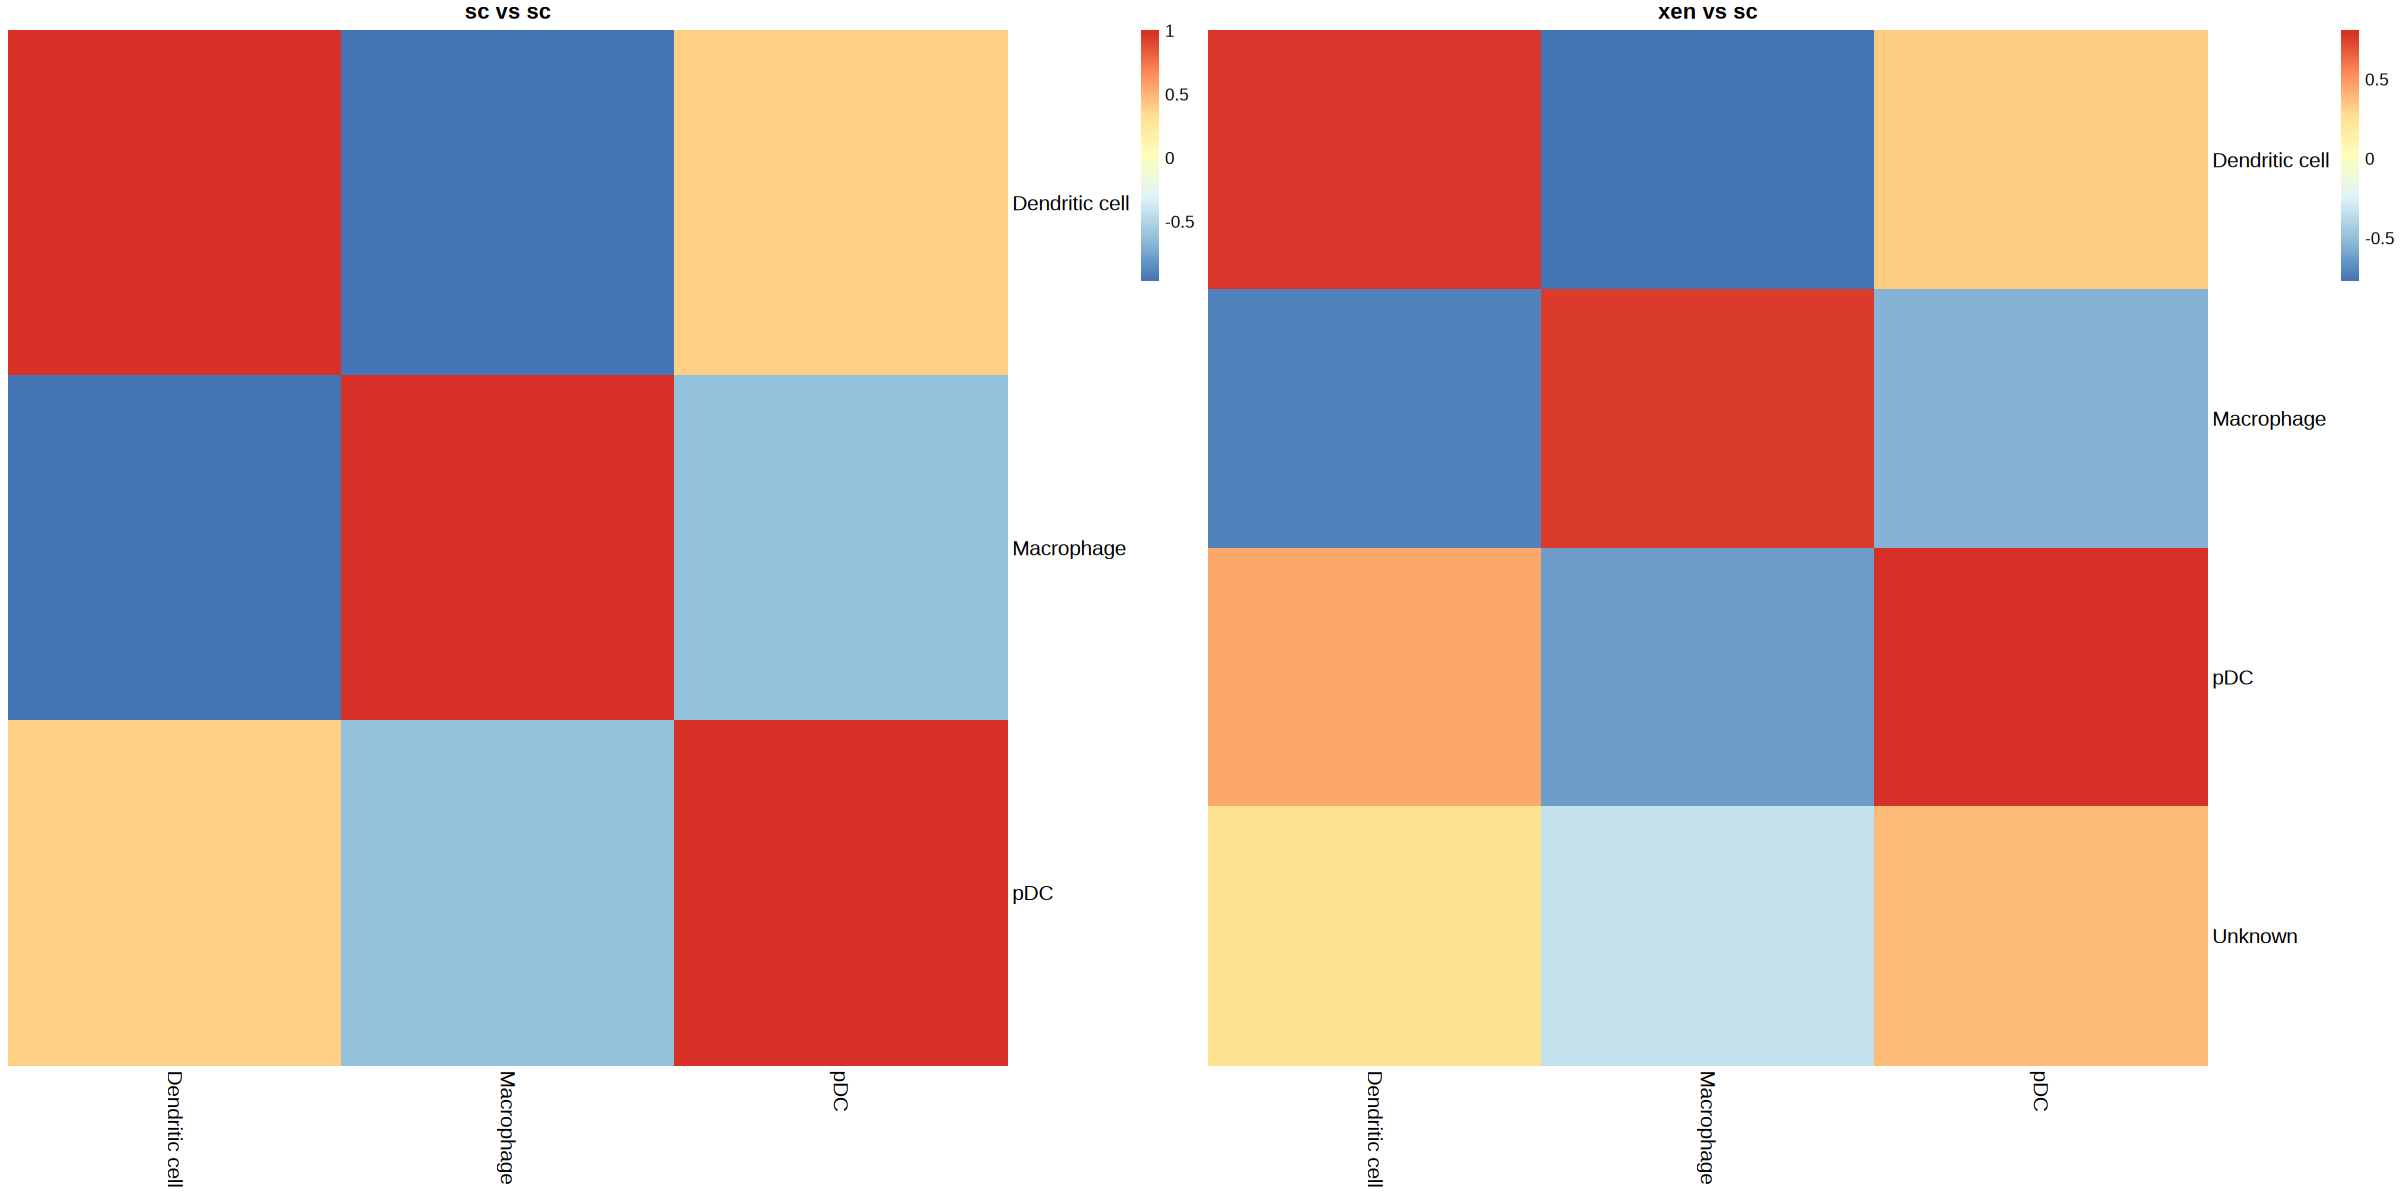

In [46]:
source('typing_utils.r')
res <- CompareMarkerCorrelations(f_merged[,f_merged$modality == "xen"],
                                 f_merged[,f_merged$modality == "sc"], "cell_type")

[1] 0.7661731

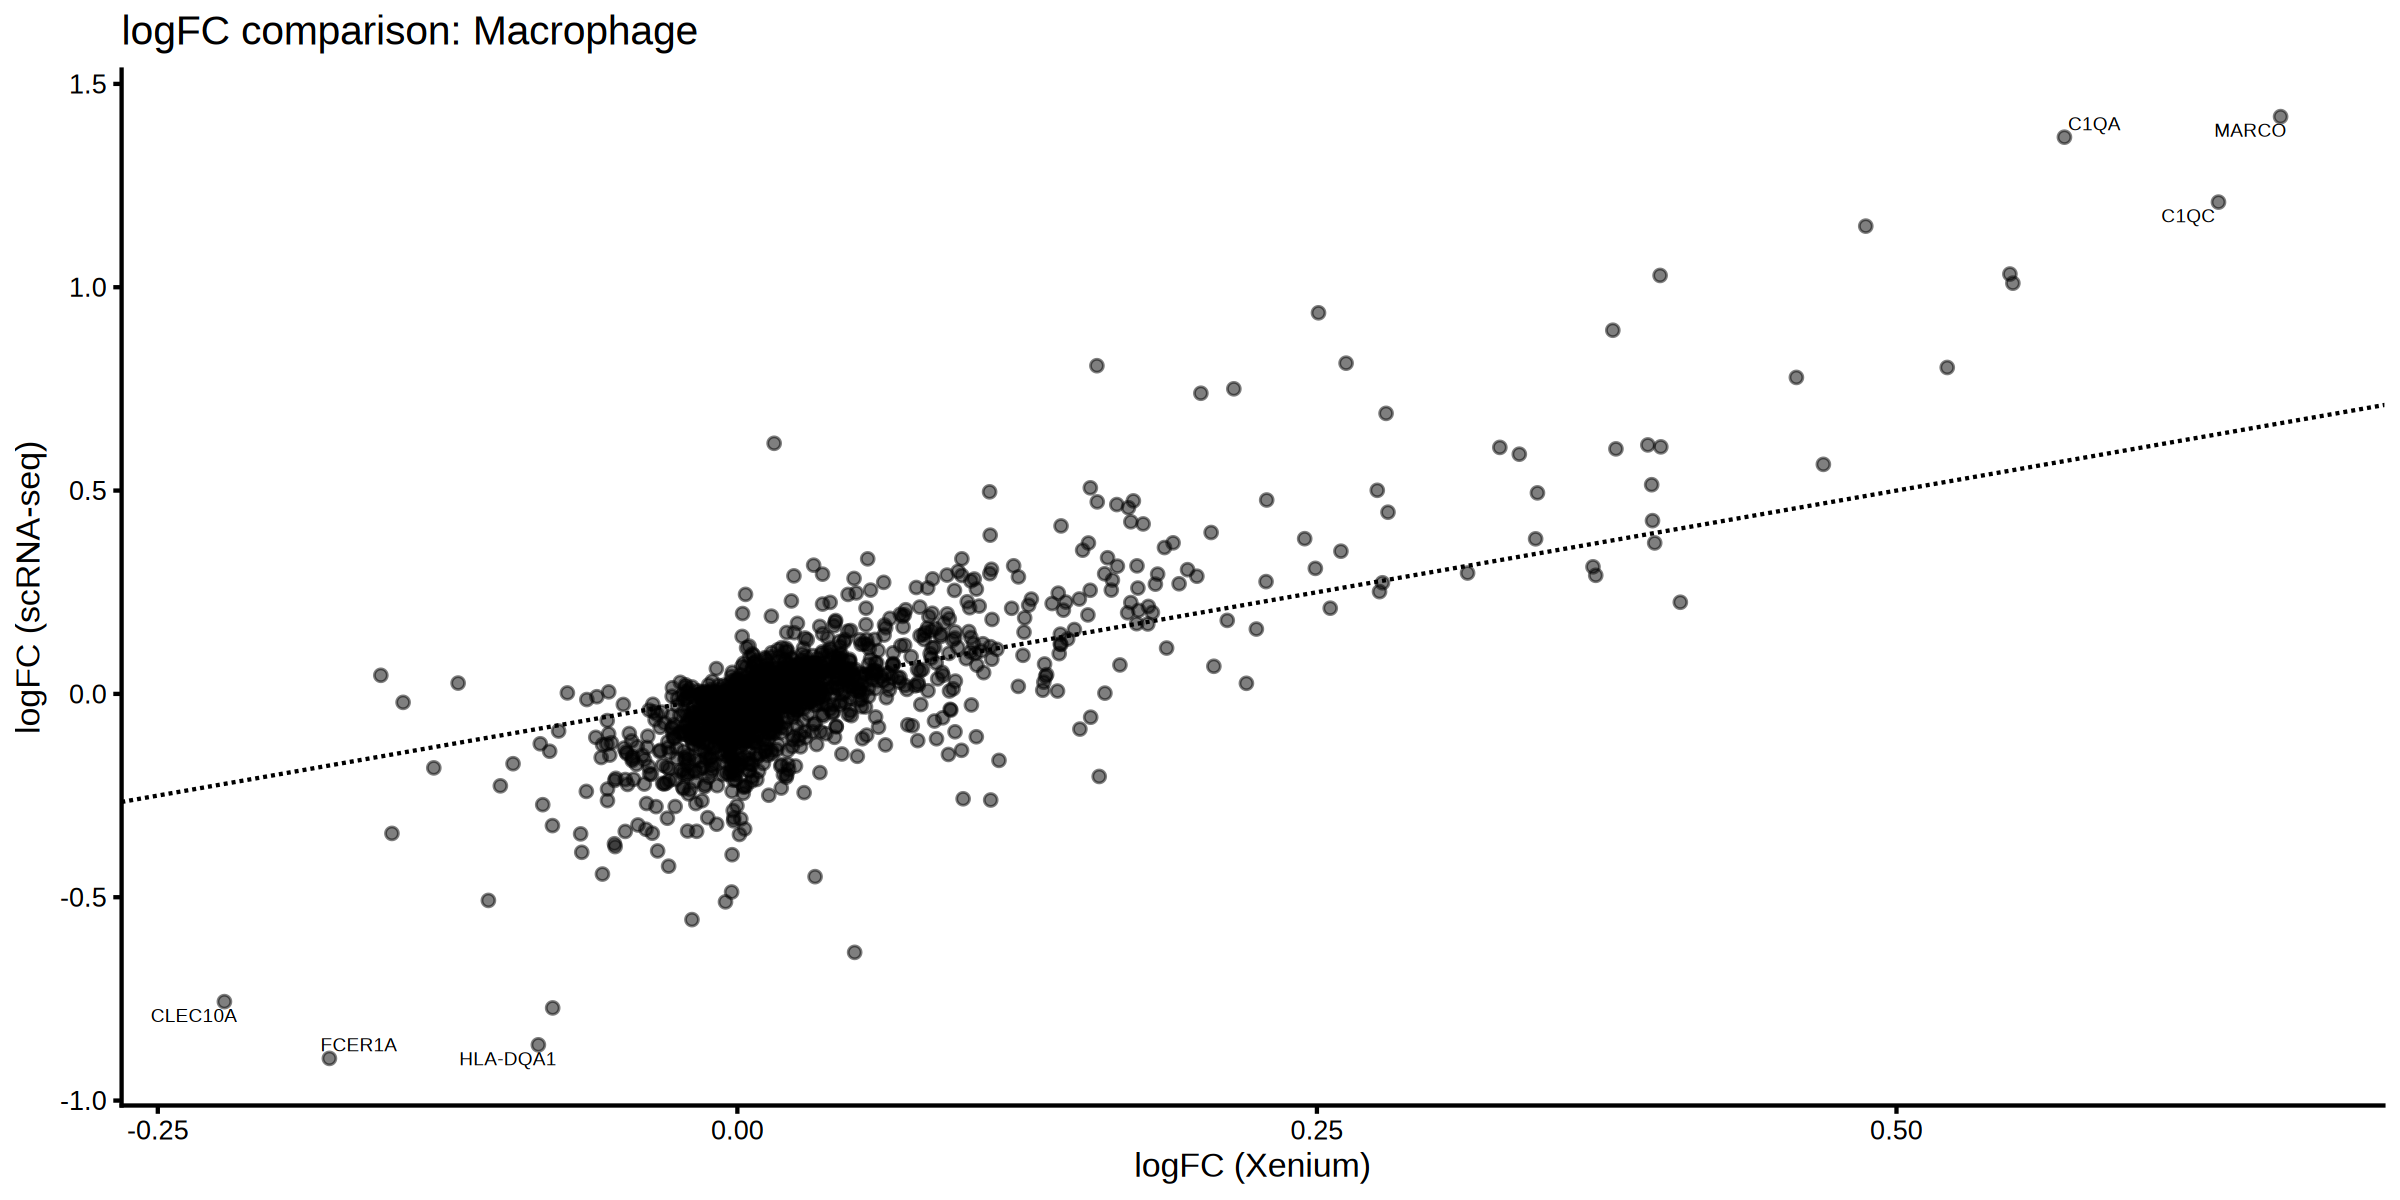

In [47]:
mac_res <- PlotStateLogFCComparison(
  markers_sc = res$markers.sc,
  markers_xen = res$markers.xen,
  cell_state = "Macrophage"
)

mac_res$correlation

## Save resulting cell types into original xenium object

In [48]:
xen_mac.meta <- f_merged@meta.data %>%
    filter(cell_type == "Macrophage") %>%
    filter(modality == "xen")
rownames(xen_mac.meta) <- sub("^xen_", "", rownames(xen_mac.meta))
xen_mac <- subset(xen, cells = rownames(xen_mac.meta))
xen_mac$celltypes.med <- "Macrophage"
dim(xen_mac)
saveRDS(xen_mac, "out_rds/intermediate/_Macrophage.rds")

xen_dc.meta <- f_merged@meta.data %>%
    filter(cell_type == "Dendritic cell") %>%
    filter(modality == "xen")
rownames(xen_dc.meta) <- sub("^xen_", "", rownames(xen_dc.meta))
xen_dc <- subset(xen, cells = rownames(xen_dc.meta))
xen_dc$celltypes.med <- "Dendritic cell"
dim(xen_dc)
saveRDS(xen_dc, "out_rds/intermediate/_Dendritic cell.rds")

xen_pdc.meta <- f_merged@meta.data %>%
    filter(cell_type == "pDC") %>%
    filter(modality == "xen")
rownames(xen_pdc.meta) <- sub("^xen_", "", rownames(xen_pdc.meta))
xen_pdc <- subset(xen, cells = rownames(xen_pdc.meta))
xen_pdc$celltypes.med <- "pDC"
dim(xen_pdc)
saveRDS(xen_pdc, "out_rds/intermediate/_pDC.rds")

[1]   4008 397685

[1]  4008 47632

[1] 4008 3885

# Call macrophage subtypes

In [49]:
xen_mac <- readRDS("out_rds/intermediate/_Macrophage.rds")

## Get discriminatory genes from sc

In [50]:
# select genes that differentiate sublining types in AMPp2
res <- FindHVGsFromGroups(sc[, ((sc$cell_type == "Macrophage") & !(grepl('LAMP3', sc$cluster_name)))], group_var = "cluster_name", logFC_thresh = 0.2)
hvgs <- res$hvgs
info <- res$info

info %>%
    dplyr::select(feature, group) %>%
    dplyr::mutate(row = dplyr::row_number()) %>%
    tidyr::pivot_wider(names_from = group, values_from = feature) %>%
    head(n = 10)

Number of HVGs found: 479 


row,M-0: MERTK+ SELENOP+ LYVE1+,M-1: MERTK+ SELENOP+ LYVE1-,M-2: MERTK+ S100A8+,M-3: MERTK+ HBEGF+,M-4: SPP1+,M-5: C1QA+,M-6: STAT1+ CXCL10+,M-7: IL1B+ FCN1+,M-8: PLCG2+
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,C1QA,C1QA,MARCO,SPP1,SPP1,MS4A2,CXCL10,FCN1,PLCG2
2,C1QC,C1QC,C1QA,CXCL2,FBP1,SLC18A2,GBP1,IL1B,NR4A1
3,FOLR2,HLA-DQA1,C1QC,CXCL8,LDHA,GATA2,GBP5,NAMPT,HEXIM1
4,PLTP,NR4A2,TIMD4,CTSL,S100A10,HDC,STAT1,S100A12,TNF
5,DAB2,F13A1,NCF1,ATF3,ANPEP,CD27,CXCL9,ATF3,H3F3B
6,LGMN,ATF3,GPNMB,MARCO,PKM,KIT,IFIT3,CD52,IRF1
7,F13A1,CXCL2,VSIG4,OLR1,CTSL,CTSG,WARS,PLAUR,MCL1
8,LILRB5,PLTP,LILRB5,NR4A2,PGK1,CD8A,TNFSF10,NR4A2,NAMPT
9,SLC40A1,CCL3,FCGR3A,SGK1,CLEC5A,IL1RL1,TAP1,SOCS3,DDX3X


## filter xenium + sc to these genes and merge


[1/7] Retrieving count matrices and checking gene overlap... 
  Xenium counts dimensions: 4008 genes x 397685 cells 
  Single-cell counts dimensions: 4004 genes x 61057 cells 
  Number of genes shared between objects: 4004 

[2/7] Preparing Seurat objects for merging... 
  Merged object created. 
  Merged object summary: 
An object of class Seurat 
4004 features across 458742 samples within 1 assay 
Active assay: RNA (4004 features, 0 variable features)
 1 layer present: counts
  Merged object dimensions: 4004 genes x 458742 cells 
  Cells by modality: 

    sc    xen 
 61057 397685 

[3/7] Choosing normalization scale factor... 
  Using mean of modality-specific medians. 
  Xen median nCount_RNA: 247 
  SC median nCount_RNA: 2558 
  Selected normalization scale factor: 1402.5 

[4/7] Normalizing data, setting variable features, and scaling... 
  HVGs supplied: 479 
  HVGs present in merged object: 479 


Centering and scaling data matrix

Centering and scaling data from split sc

Centering and scaling data from split xen




[5/7] Running dimensional reduction... 
  cca_weights is NULL/NA; running PCA. 


PC_ 1 
Positive:  MARCO, VSIG4, GRN, GPNMB, CD68, C1QC, ANXA2, C1QA, FCGR3A, TIMD4 
	   S100A4, NCF1, MSR1, LILRB5, ALDH2, CYBB, CTSL, S100A10, LGMN, LAMP1 
	   AP1B1, FLNA, PLEC, EMP1, GAA, HEXB, LRP1, HTRA1, CTSS, COMT 
Negative:  FCN1, CCR2, ITGAX, CD1D, CD93, ADGRE2, S100A12, IL1B, PID1, AOAH 
	   SNHG15, VEGFA, CLEC5A, SPP1, CD300E, ICAM3, ADAM8, CD52, BCL2A1, ADAM28 
	   VSIR, CYTOR, CXCL8, IL1RN, NR4A2, MXD1, ATF3, NR4A3, FCAR, AREG 
PC_ 2 
Positive:  C1QC, LYVE1, C1QA, F13A1, LGMN, SLC40A1, FOLR2, COLEC12, FCGRT, PLTP 
	   DAB2, MRC1, MAF, GPR34, FUCA1, PMP22, CCL18, CD59, GAS6, LILRB5 
	   HPGDS, CREG1, EPHX1, PEPD, VSIG4, MARCO, CD99, SCN9A, GPNMB, ITGB5 
Negative:  TYMP, MCL1, PLAUR, IRF1, ITGAX, CIITA, SOD2, NAMPT, WARS, SGK1 
	   CD300E, ADAM8, CD44, ANPEP, STAT1, GBP1, SLC2A3, SOCS3, FCN1, TAP1 
	   CXCR4, HNRNPH1, LDHA, CSF3R, GBP5, ADGRE2, CLEC7A, CFLAR, TREM1, CXCL10 
PC_ 3 
Positive:  S100A10, S100A4, FLNA, MARCO, FBP1, PKM, TIMD4, ANXA2, TREM1, LDHA 
	   PRG4, ALDH2,

  Printing PCA diagnostic plots... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[6/7] Running Harmony... 


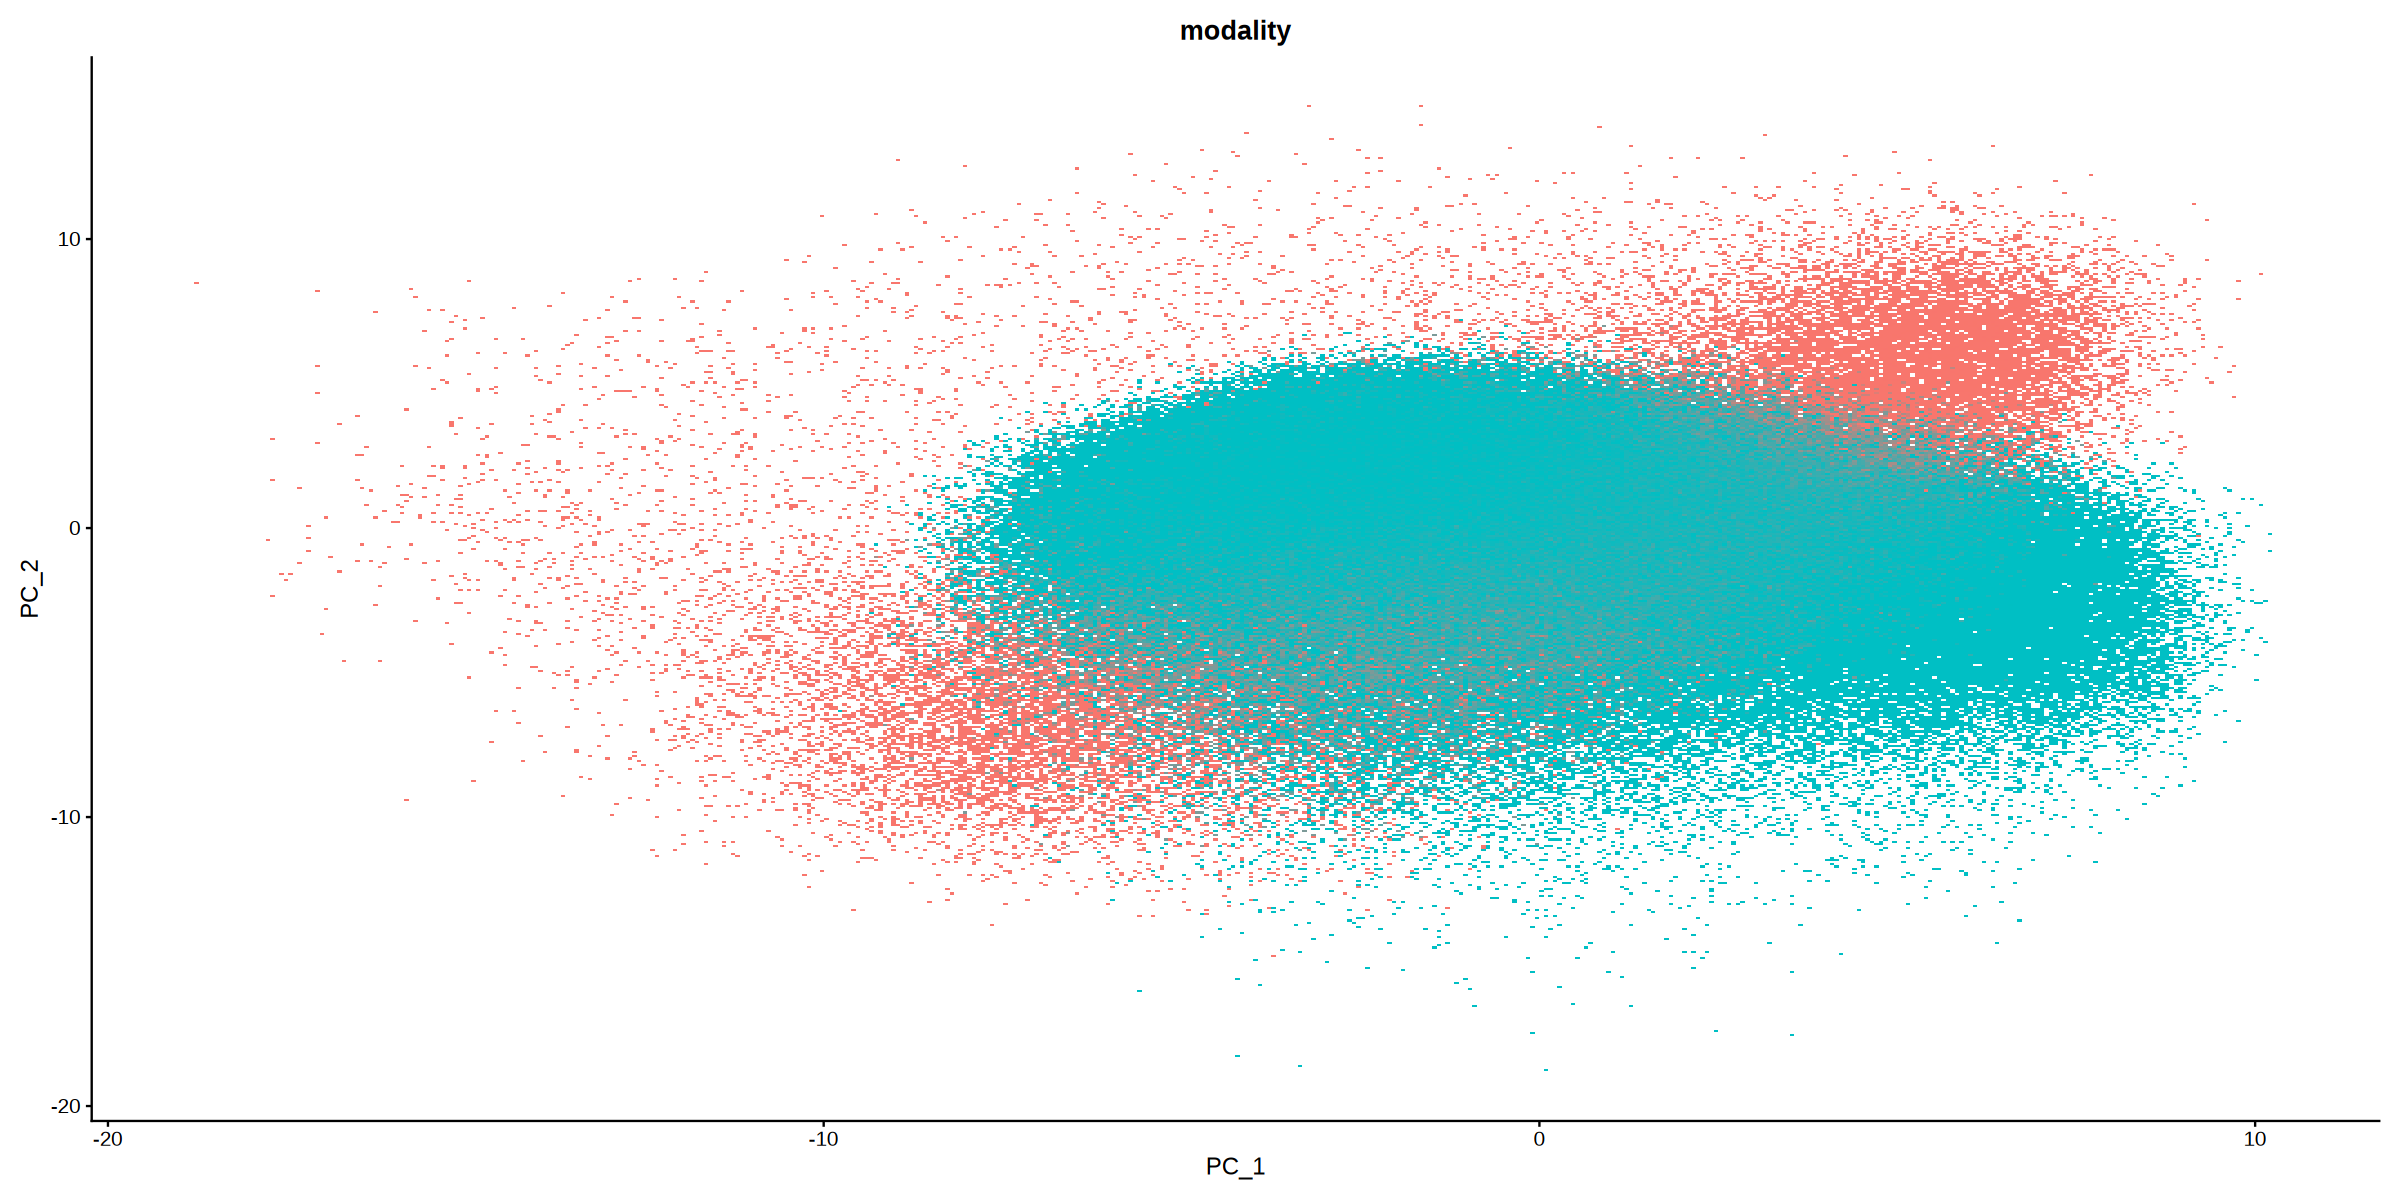

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 22937100)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony 8/10

Harmony 9/10

Harmony 10/10



  Printing Harmony diagnostic plots... 


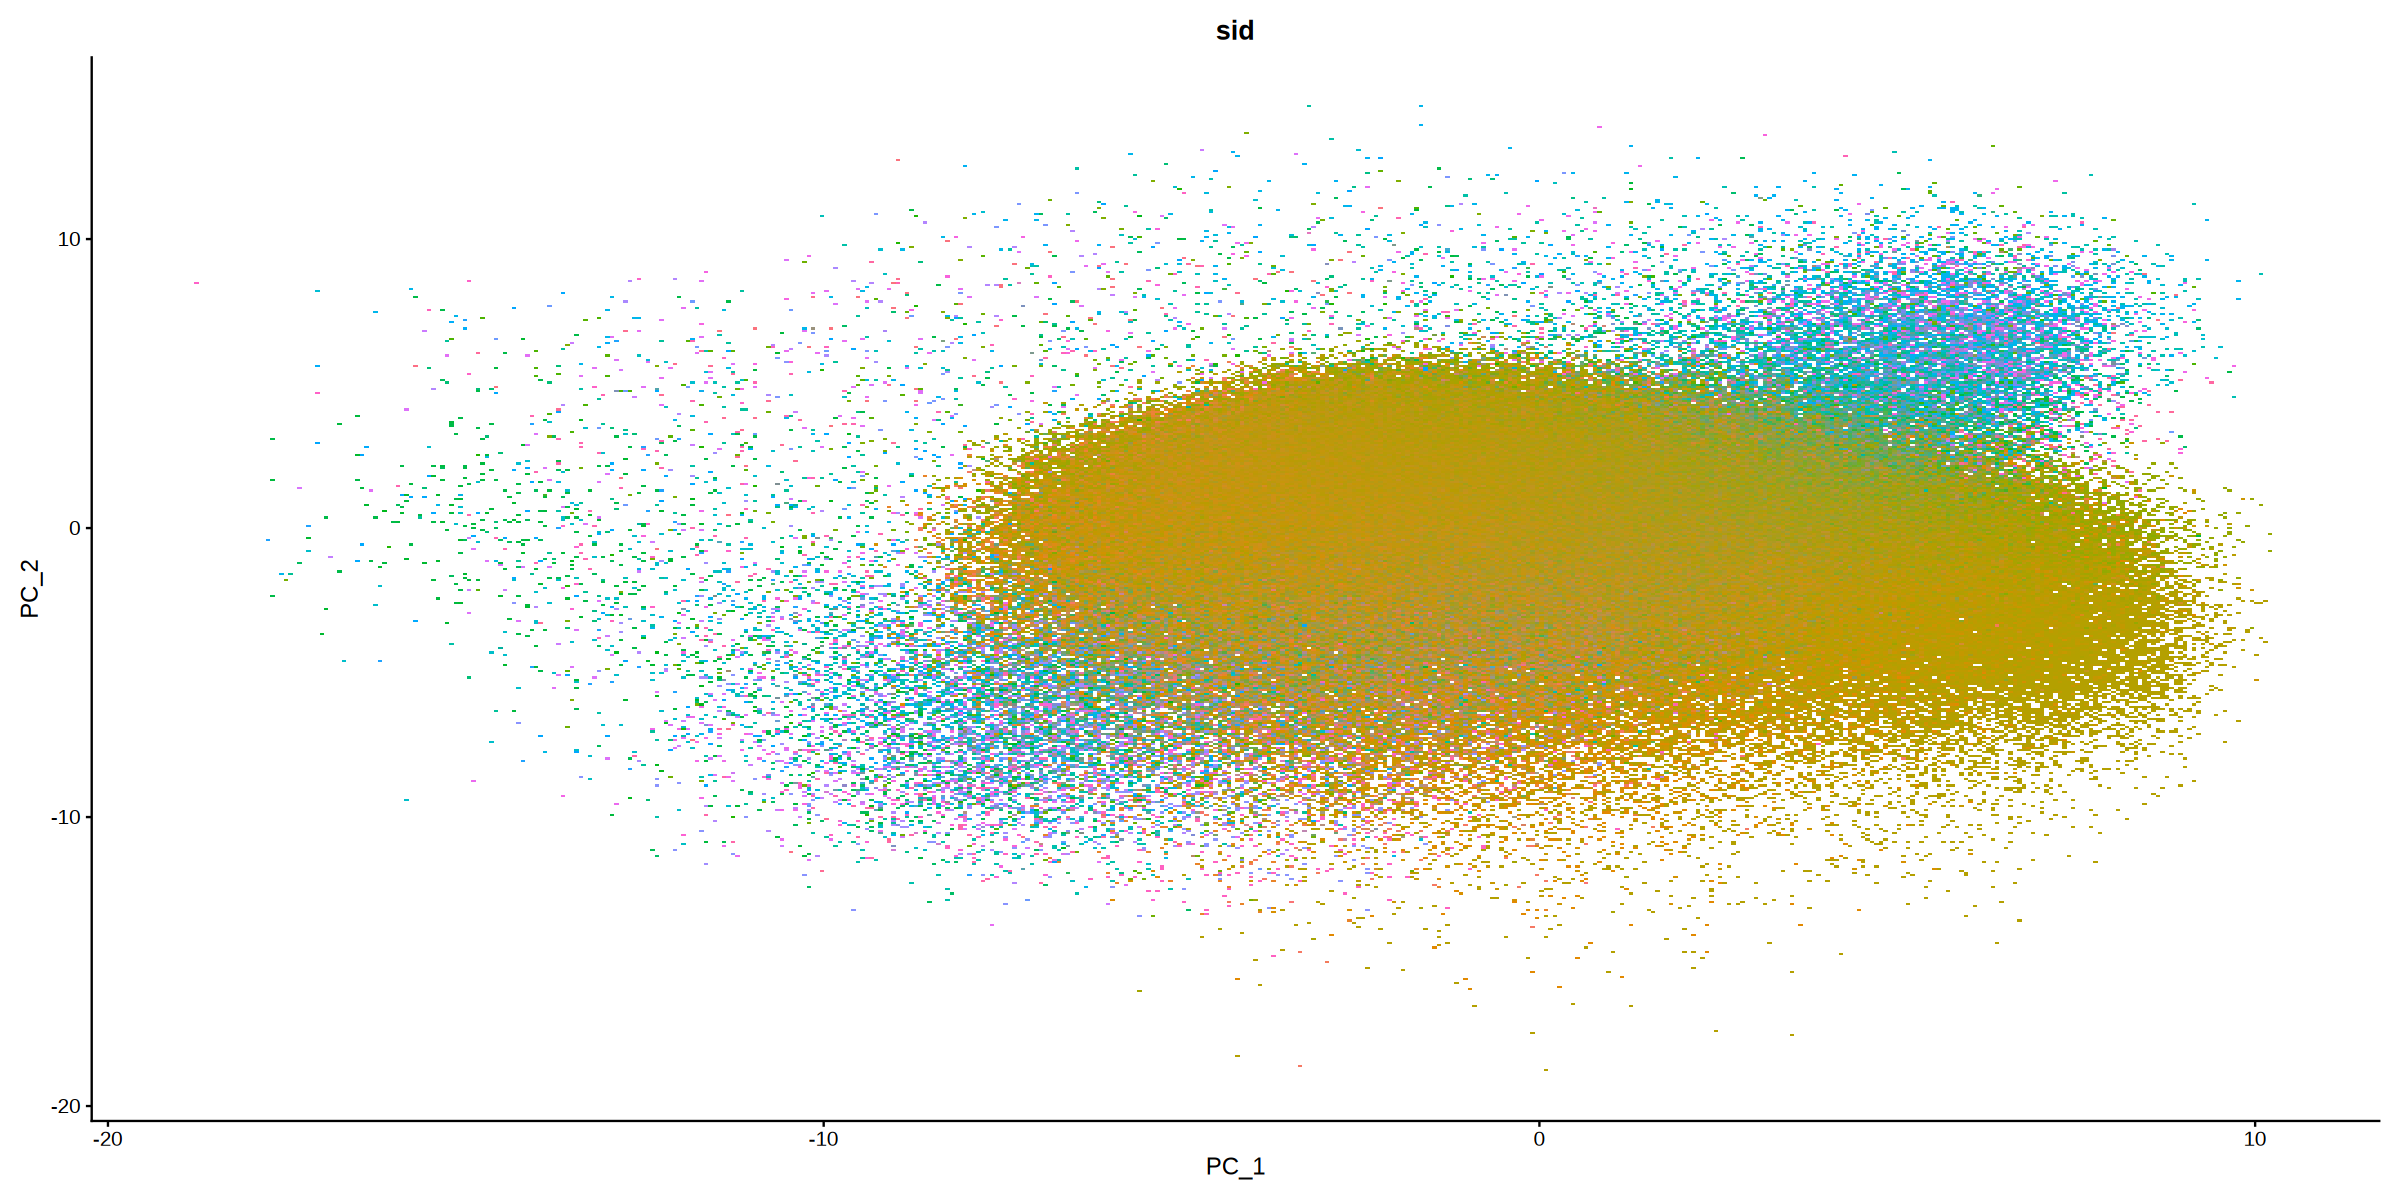

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



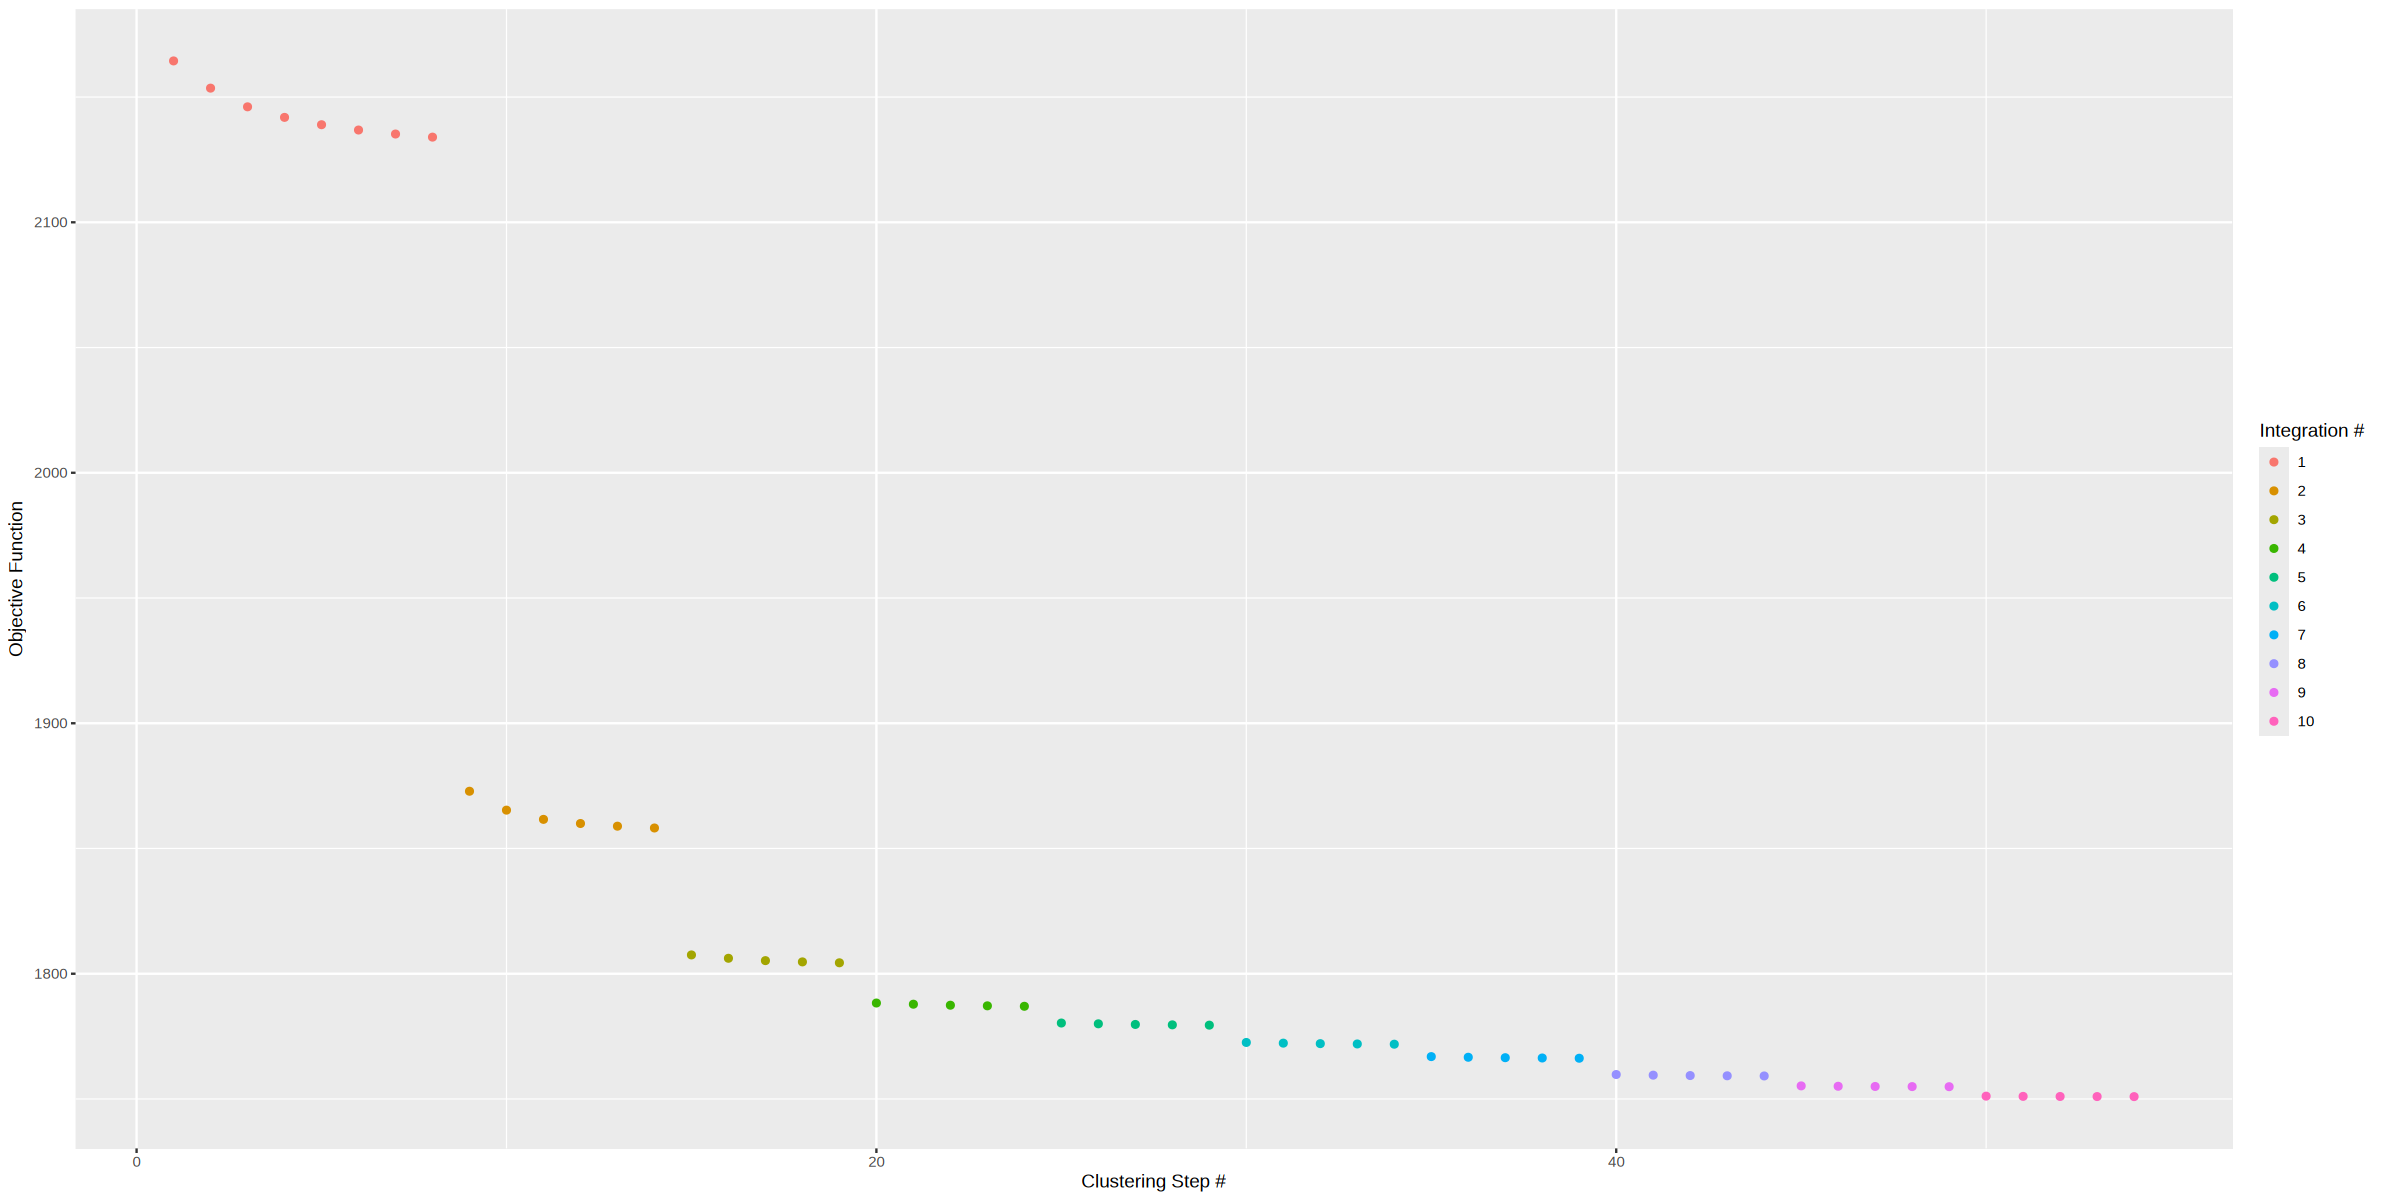

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[7/7] Running UMAP on the Harmony reduction... 


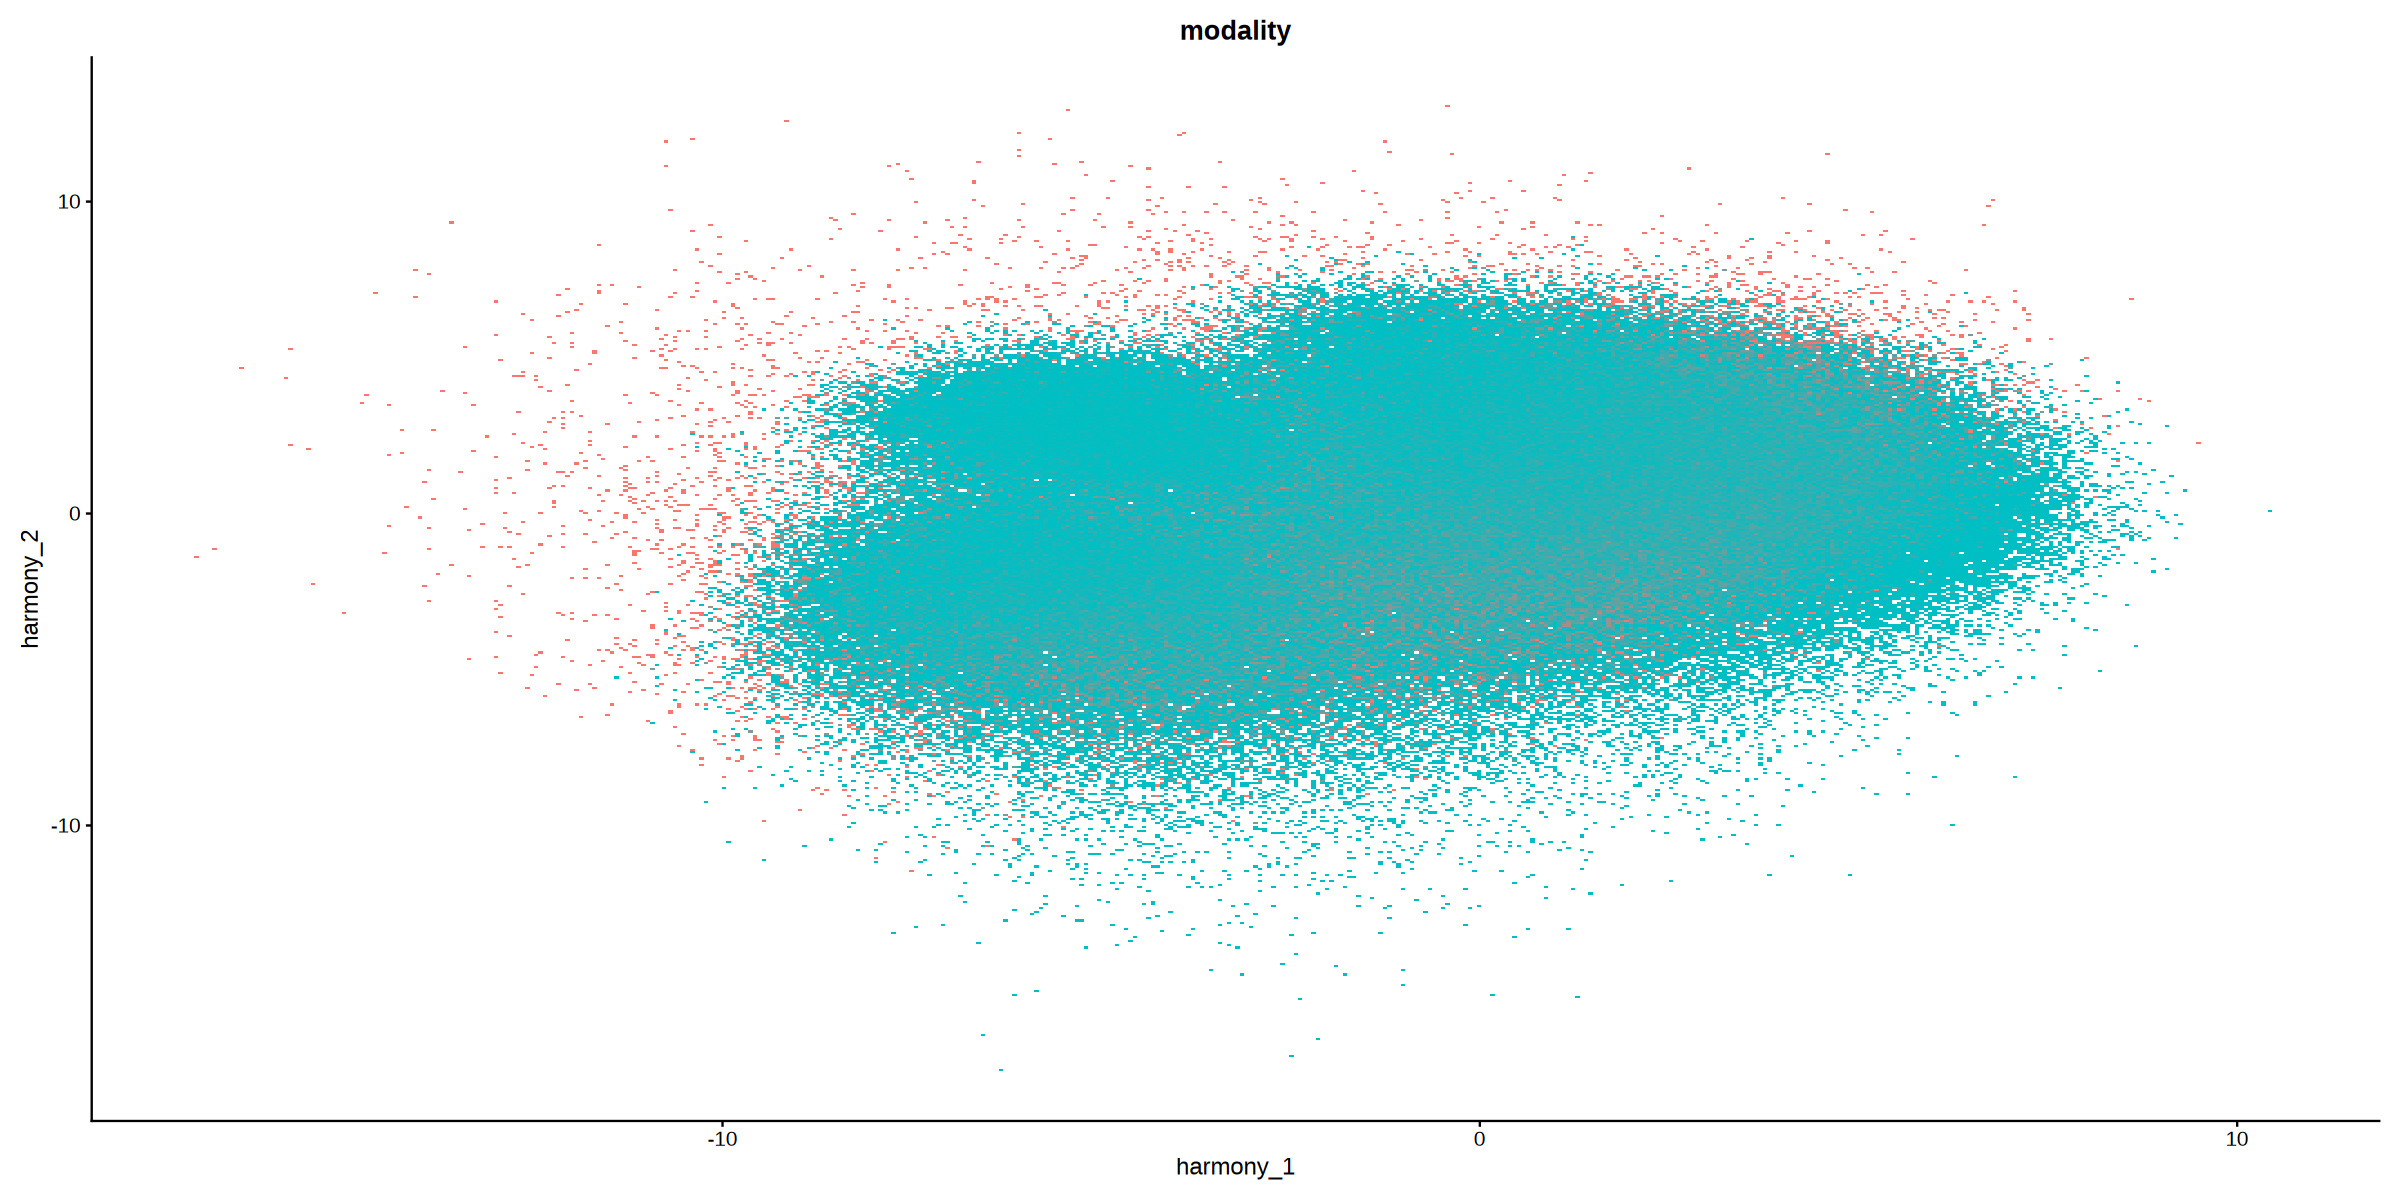

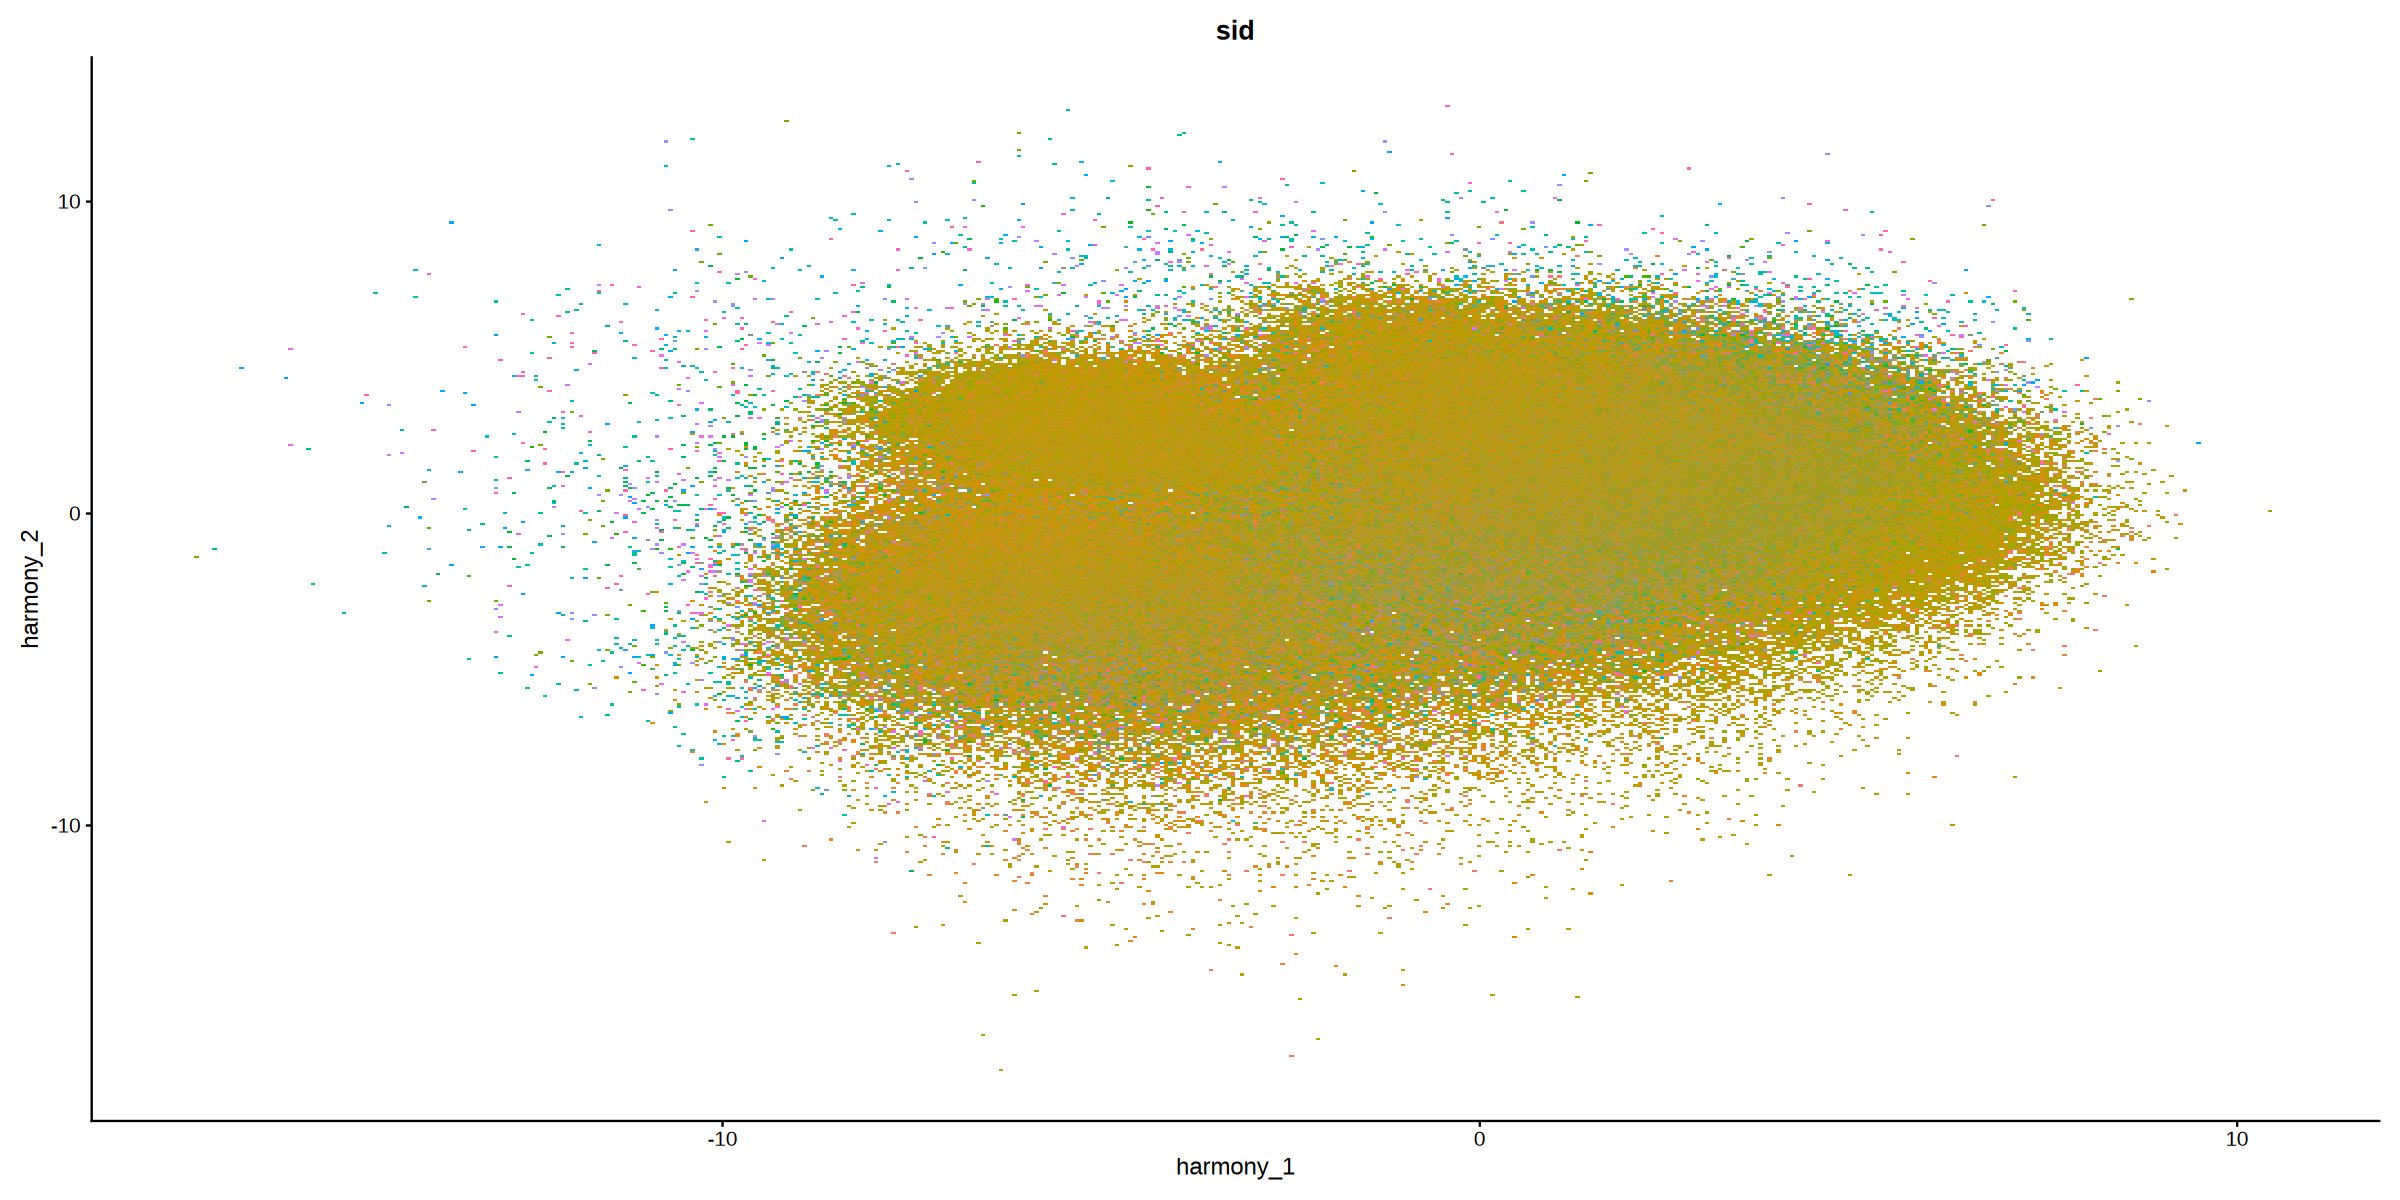

In [51]:
mac_merged <- BuildIntegratedReference(
    xen = xen_mac,
    sc = sc[, ((sc$cell_type == "Macrophage") & !(grepl('LAMP3', sc$cluster_name)))],
    normalization_target = "mean_of_medians",
    hvgs = hvgs,
    annotation_var = "cluster_name"
)

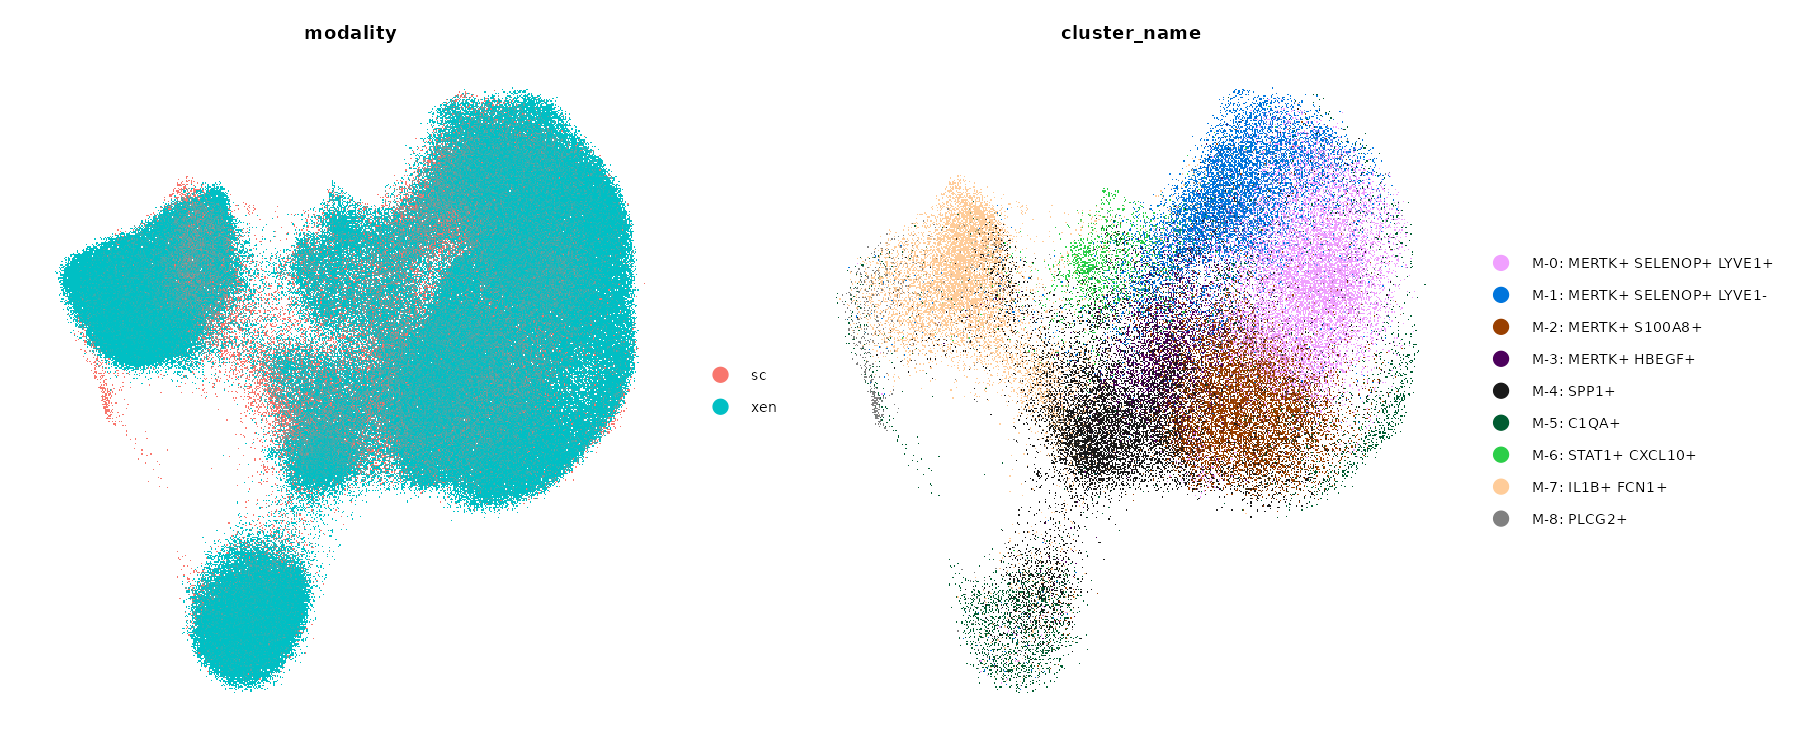

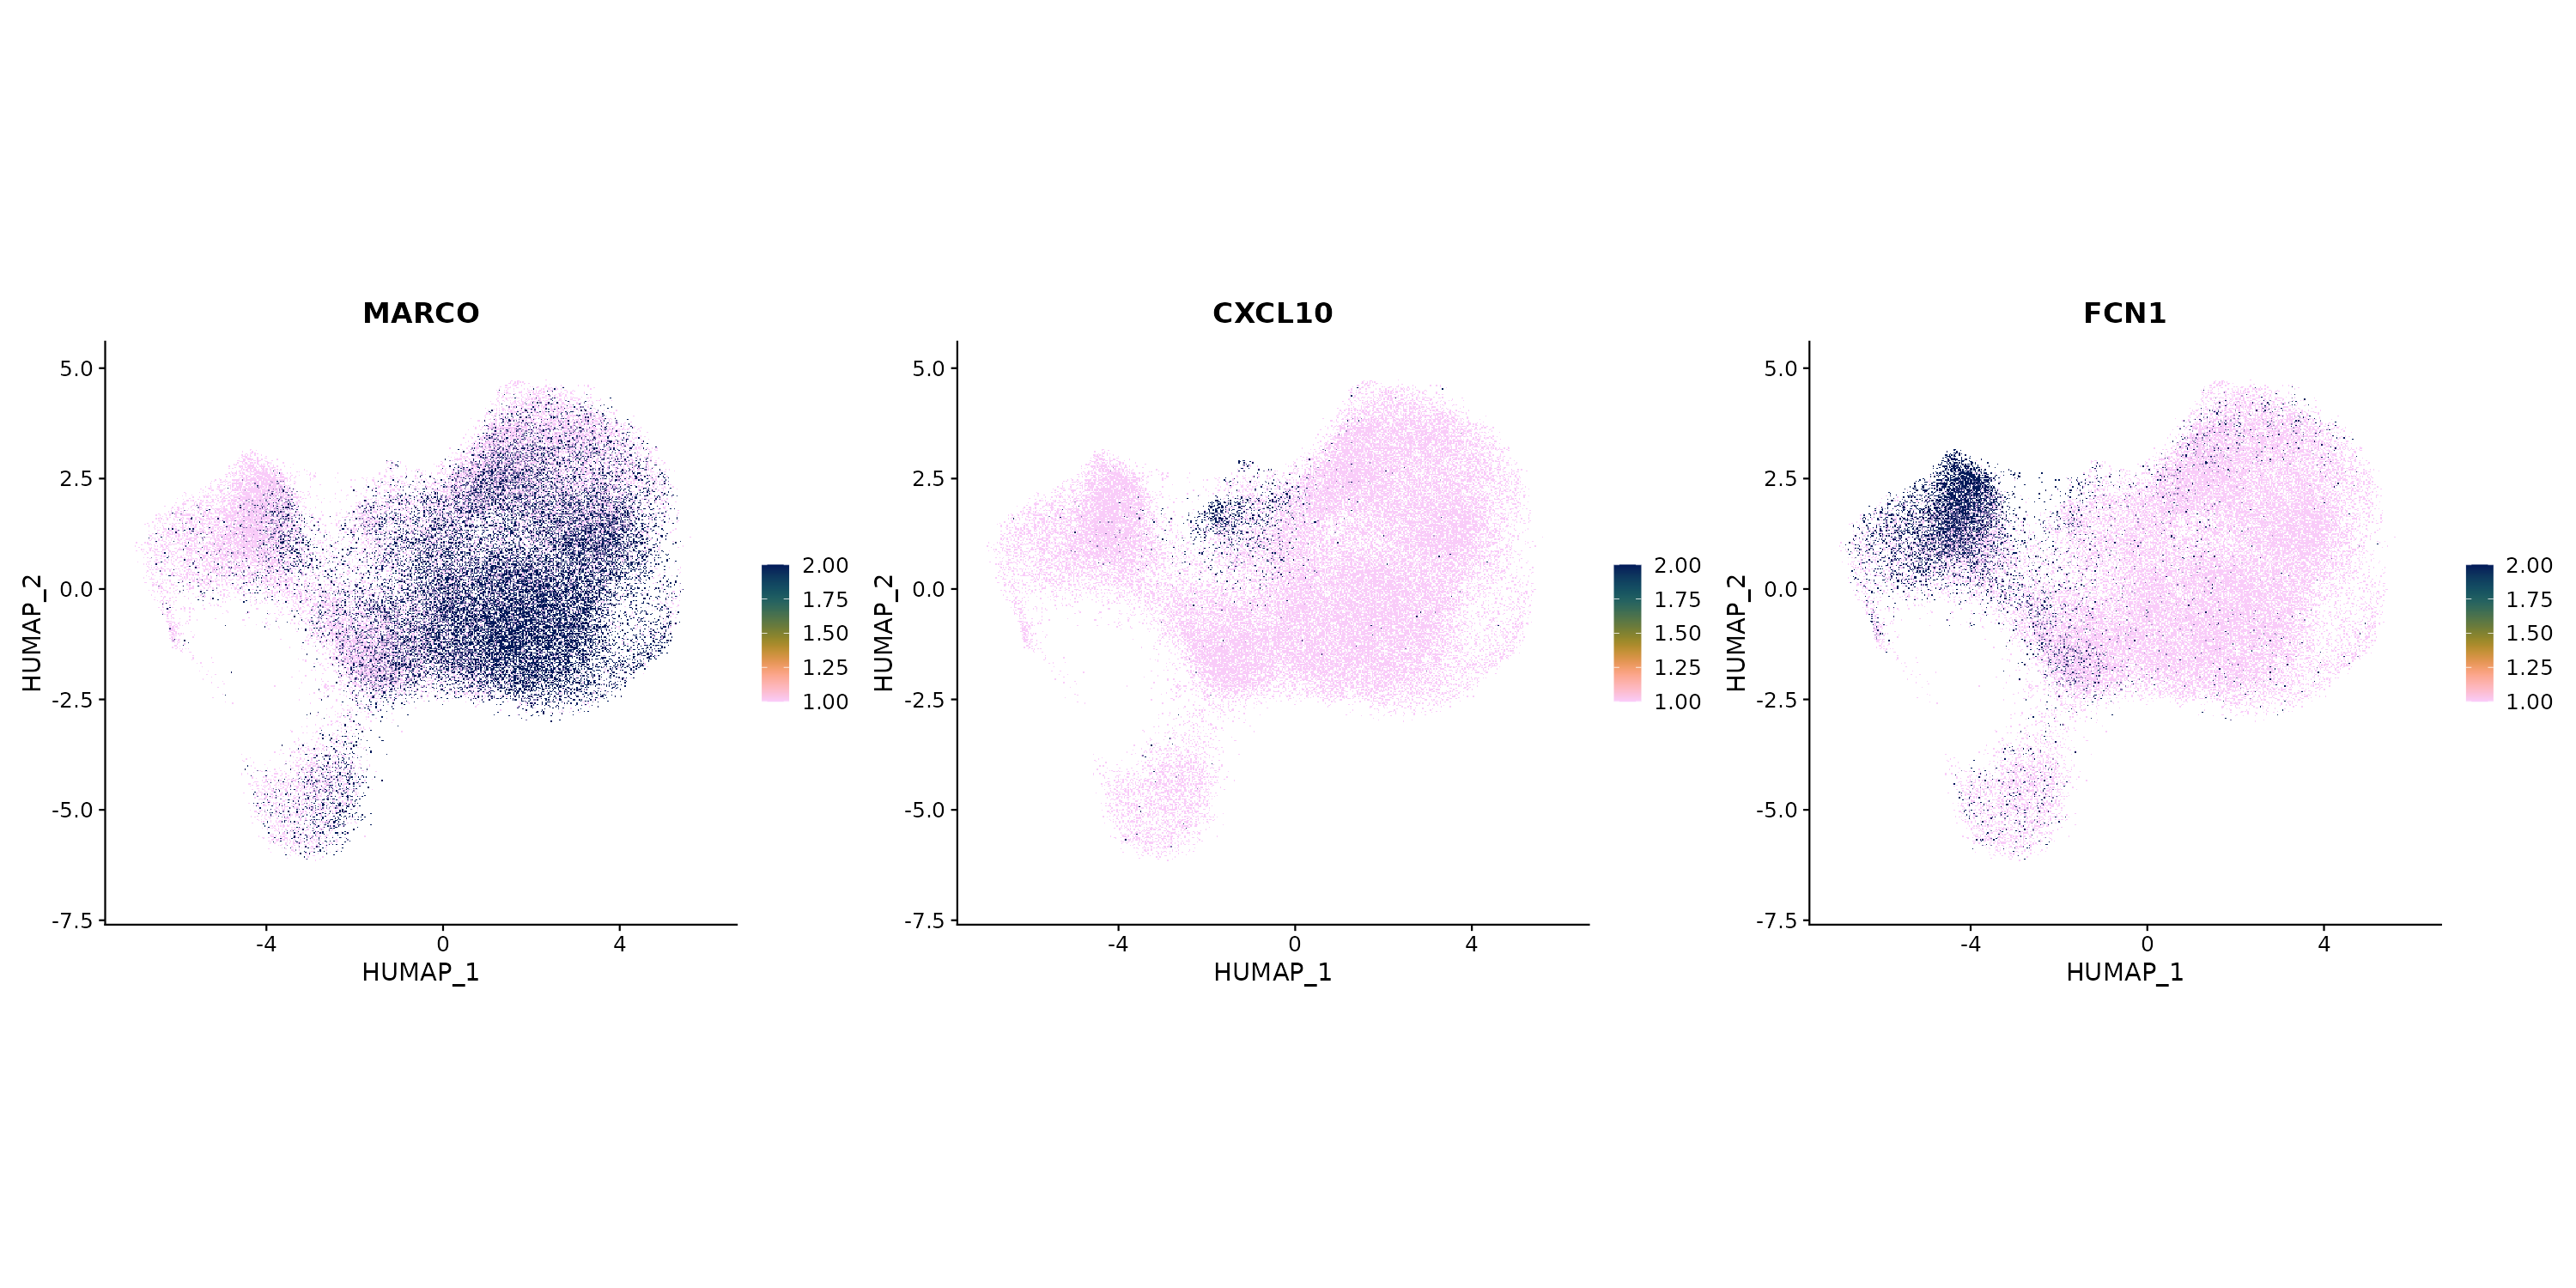

In [52]:
ShowTransferDiagnostics(
    merged = mac_merged,
    annotation_var = "cluster_name",
    genes_to_visualize = c("MARCO", "CXCL10", "FCN1")
)

## Label transfer


[1/4] Checking inputs... 
  Using annotation variable: cluster_name 
  Using n_neighbors = 50 and min_ratio = 1.1 

[2/4] Computing nearest-neighbor graph from Harmony embedding... 
  Graph computation complete. 

[3/4] Transferring labels from sc cells to xen cells... 
  Labels written to: cluster_name 
  Xen cells without transferred labels: 47464 

[4/4] Plotting unlabeled cells and final xen label map... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



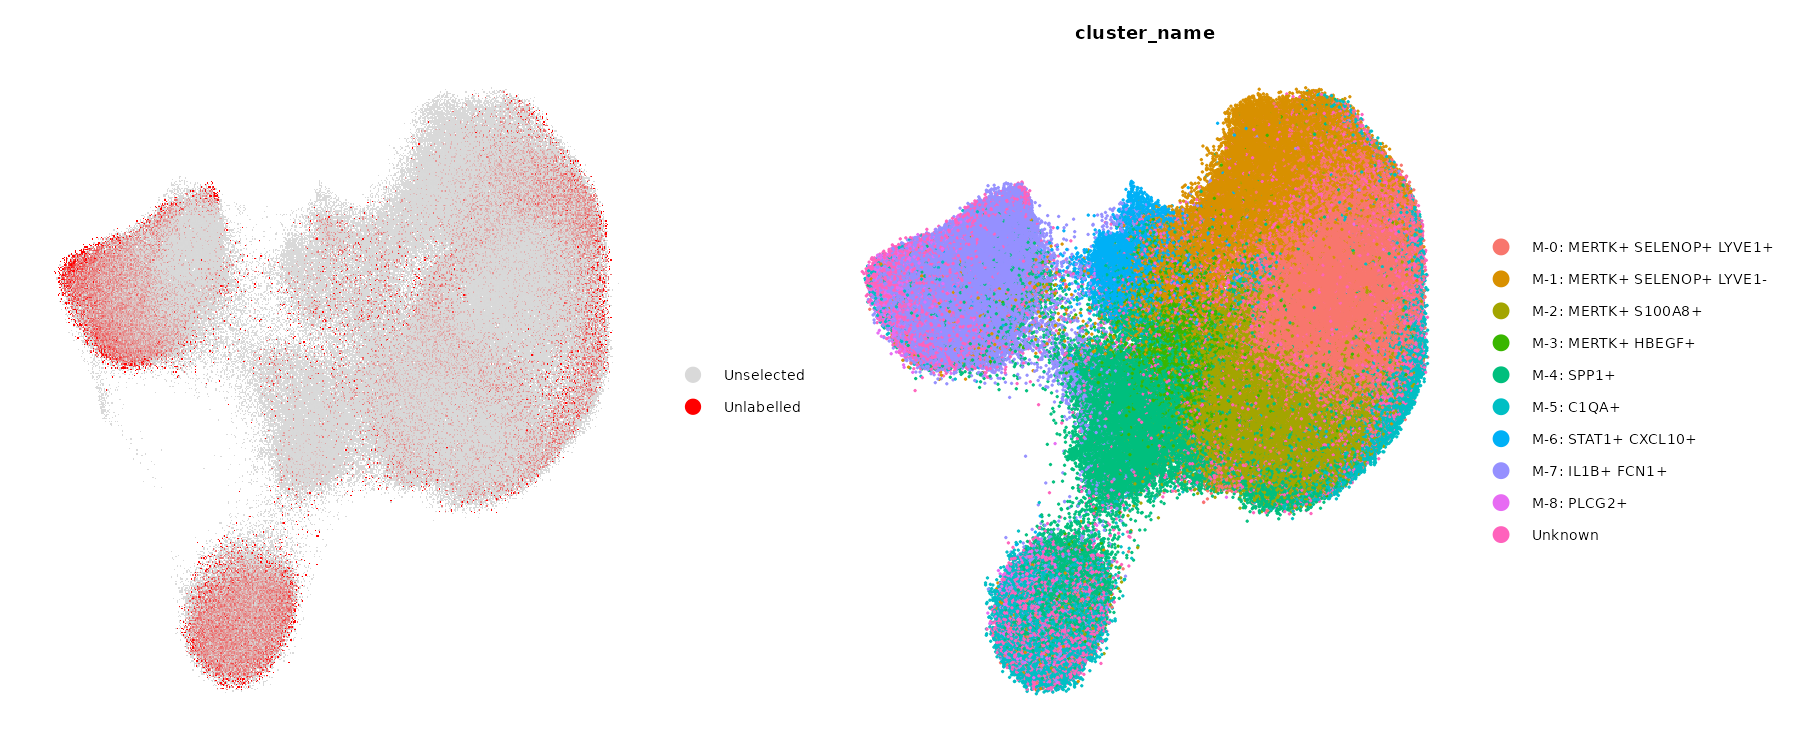

In [53]:
mac_merged <- TransferLabelsGraph(
    merged = mac_merged,
    annotation_var = "cluster_name",
    n_neighbors = 50,
    min_ratio = 1.1
)

## Examine marker genes

In [54]:
ShowClusterMarkers(mac_merged[, mac_merged$modality == "xen"], "cluster_name", n_show = 5)

row,M-0: MERTK+ SELENOP+ LYVE1+,M-1: MERTK+ SELENOP+ LYVE1-,M-2: MERTK+ S100A8+,M-3: MERTK+ HBEGF+,M-4: SPP1+,M-5: C1QA+,M-6: STAT1+ CXCL10+,M-7: IL1B+ FCN1+,M-8: PLCG2+,Unknown
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,LYVE1,STAB1,MARCO,S100A10,SPP1,C1QA,CXCL10,CCL5,CCL5,F13A1
2,F13A1,SLCO2B1,S100A10,FLNA,S100A10,C1QC,GBP1,CIITA,STAB1,NA
3,LGMN,CD14,S100A4,MARCO,FLNA,F13A1,STAT1,ITGAX,PLCG2,NA
4,SLC40A1,NAIP,GPNMB,ANXA2,ANXA2,HLA-DRB1,SOD2,NOTCH2NL,CCDC136,NA
5,STAB1,CCL5,FLNA,NCF1,S100A4,CCL18,CXCL9,LENG8,DUX4,NA


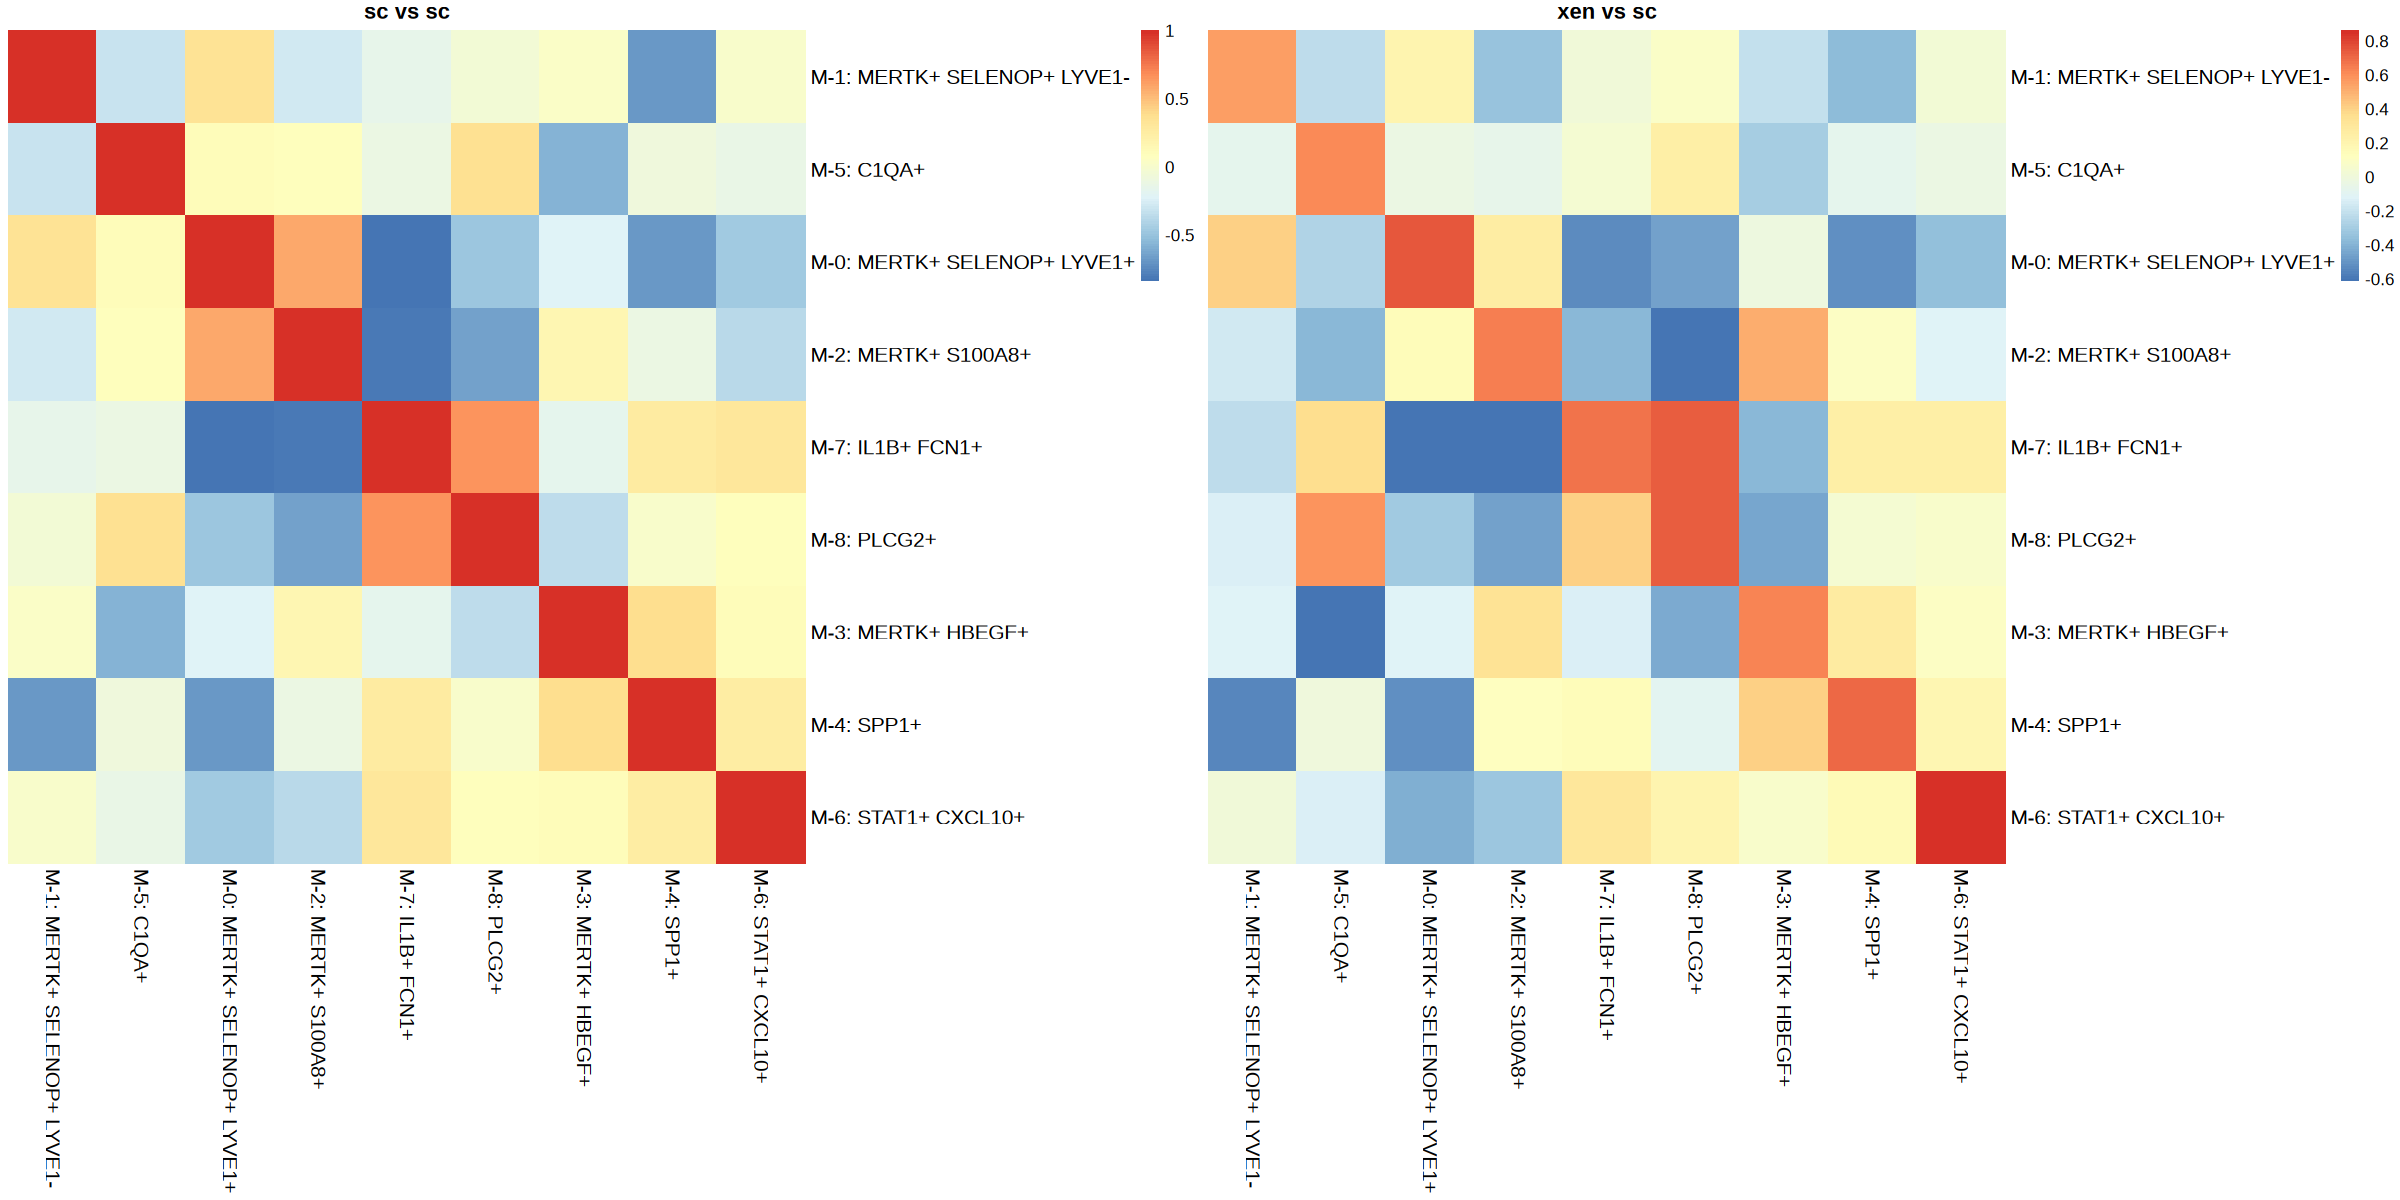

In [55]:
res <- CompareMarkerCorrelations(mac_merged[,mac_merged$modality == "xen"],
                                 mac_merged[,mac_merged$modality == "sc"], "cluster_name", bicluster = T)

In [54]:
xen_mac

ERROR: Error: object 'xen_mac' not found


## Save

In [56]:
xen_mac@meta.data <- subset(
  xen_mac@meta.data,
  select = -c(humap_fgraph_res.0.8, seurat_clusters)
)

colnames(mac_merged) <- sub("^xen_", "", colnames(mac_merged))

xen_mac$celltype.fine <- mac_merged$cluster_name[
  match(colnames(xen_mac), colnames(mac_merged))
]
xen_mac[[]]$celltype.fine[is.na(xen_mac[[]]$celltype.fine)] <- "F-9: Untyped"

In [57]:
saveRDS(xen_mac, file = "out_rds/intermediate/_Macrophage_finetyped.rds")

# Call DC subtypes

In [26]:
xen_dc <- readRDS("out_rds/intermediate/_Dendritic cell.rds")

## Get discriminatory genes from sc

In [38]:
# select genes that differentiate sublining types in AMPp2
res <- FindHVGsFromGroups(sc[, sc$cell_type == "Dendritic cell"], group_var = "cluster_name", logFC_thresh = 0.1)
hvgs <- res$hvgs
info <- res$info

info %>%
    dplyr::select(feature, group) %>%
    dplyr::mutate(row = dplyr::row_number()) %>%
    tidyr::pivot_wider(names_from = group, values_from = feature) %>%
    head(n = 10)

Number of HVGs found: 1292 


row,M-10: DC2,M-11: DC4,M-12: DC1,M-14: LAMP3+,M-9: DC3
<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,FCER1A,FCGR3A,C1orf54,LAMP3,CD14
2,CLEC10A,CDKN1C,IRF8,IL7R,C1QA
3,CD1C,FCN1,CLEC9A,FSCN1,C1QC
4,FCGR2B,TCF7L2,WDFY4,CCR7,CD163
5,SGK1,CD52,CCND1,IDO1,FCGR3A
6,AREG,POU2F2,CPVL,RASSF4,VSIG4
7,HLA-DQA1,TNFRSF1B,DNASE1L3,CSF2RA,CYBB
8,ATF3,HES4,CLNK,EBI3,MARCO
9,IL1B,CTSS,BATF3,PTPN1,CSF1R


## filter xenium + sc to these genes and merge


[1/7] Retrieving count matrices and checking gene overlap... 
  Xenium counts dimensions: 4008 genes x 47632 cells 
  Single-cell counts dimensions: 4004 genes x 13492 cells 
  Number of genes shared between objects: 4004 

[2/7] Preparing Seurat objects for merging... 
  Merged object created. 
  Merged object summary: 
An object of class Seurat 
4004 features across 61124 samples within 1 assay 
Active assay: RNA (4004 features, 0 variable features)
 1 layer present: counts
  Merged object dimensions: 4004 genes x 61124 cells 
  Cells by modality: 

   sc   xen 
13492 47632 

[3/7] Choosing normalization scale factor... 
  Using mean of modality-specific medians. 
  Xen median nCount_RNA: 265 
  SC median nCount_RNA: 2427 
  Selected normalization scale factor: 1346 

[4/7] Normalizing data, setting variable features, and scaling... 
  HVGs supplied: 1292 
  HVGs present in merged object: 1292 


Centering and scaling data matrix

Centering and scaling data from split sc

Centering and scaling data from split xen




[5/7] Running dimensional reduction... 
  cca_weights is NULL/NA; running PCA. 


PC_ 1 
Positive:  WDFY4, SLAMF7, CLEC9A, XCR1, CLNK, IDO1, IRF8, TAP1, BTLA, LAMP3 
	   BATF3, C1orf54, FSCN1, DNASE1L3, CCND1, FLT3, TAP2, ENPP1, CST7, CCR7 
	   GNAO1, KIF2A, ICAM3, TRAF1, SEPT6, LY75, LMNB1, DBN1, EGLN3, MCM5 
Negative:  CD14, C1QA, C1QC, STAB1, CSF1R, CYBB, CTSS, FCGR2A, CD163, SLCO2B1 
	   TYROBP, CD68, MAFB, F13A1, MSR1, FCGR3A, LAIR1, PLTP, LRP1, VSIG4 
	   ZEB2, C3AR1, CTSL, FCGR2B, C5AR1, S100A4, LAMP1, GPNMB, FCGRT, MARCO 
PC_ 2 
Positive:  FCER1A, HLA-DRB1, CD1C, IL1R2, HLA-DQA1, CD1E, EEF1B2, MRC1, NDRG2, TMEM14C 
	   FLT3, SLC40A1, DEPTOR, IL1R1, FCGR2B, P2RY14, MEF2C, PON2, FILIP1L, IL18 
	   AXL, GPR34, F13A1, USP53, C1orf54, CLEC10A, CCND2, C1QC, CCR6, CD302 
Negative:  TYMP, FLNA, DMXL2, PLXNB2, STAT1, ADGRE5, IRF1, CD44, HNRNPH1, WARS 
	   MVP, GRK2, LTA4H, HCK, TNFRSF1B, NOTCH2, PLEC, STAT6, THEMIS2, ZFAND5 
	   LENG8, LILRB1, SLC7A7, ABI3, LILRB2, RELT, ZEB2, ZYX, ANPEP, ADGRE2 
PC_ 3 
Positive:  CPVL, SAMHD1, CLEC9A, XCR1, CLNK, WDFY4, ITGB2, PYCAR

  Printing PCA diagnostic plots... 

[6/7] Running Harmony... 


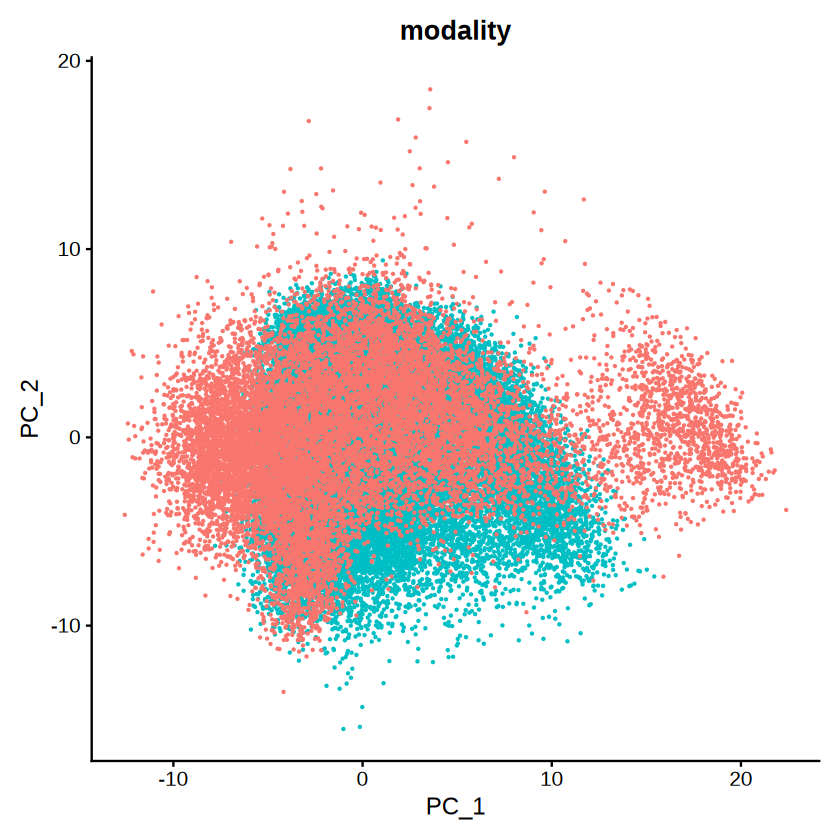

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3056200)”
Warning message:
“did not converge in 25 iterations”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony 8/10

Harmony 9/10

Harmony 10/10



  Printing Harmony diagnostic plots... 


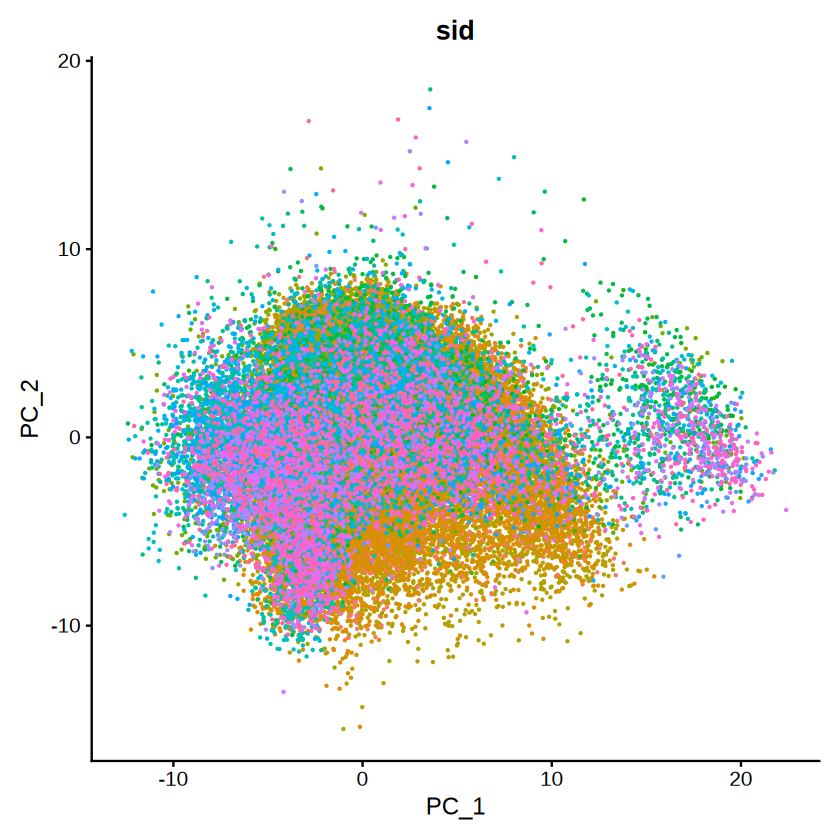

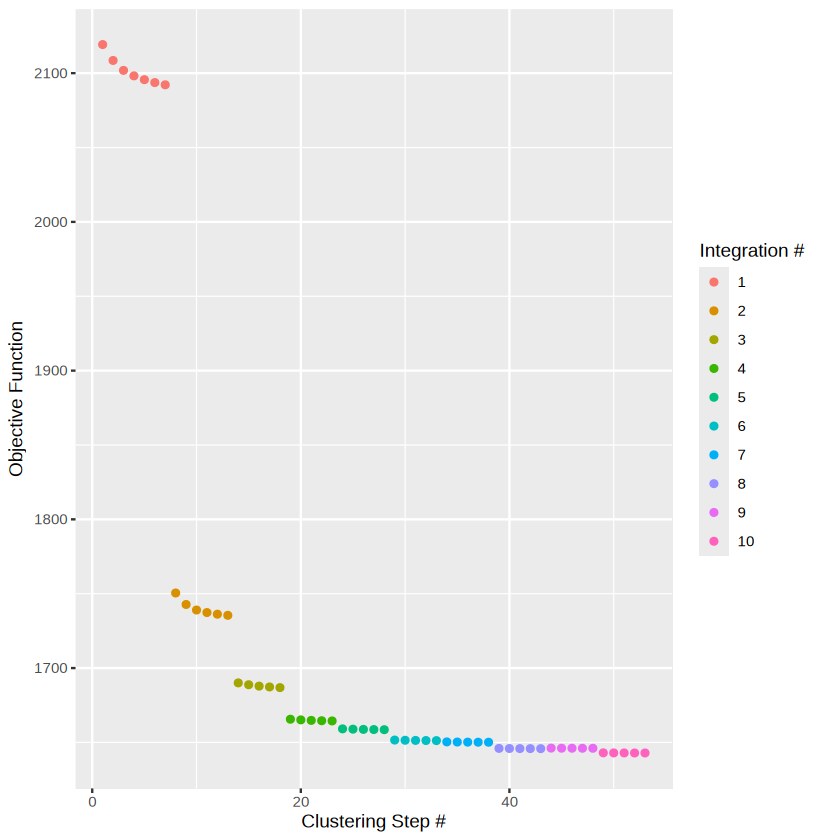


[7/7] Running UMAP on the Harmony reduction... 


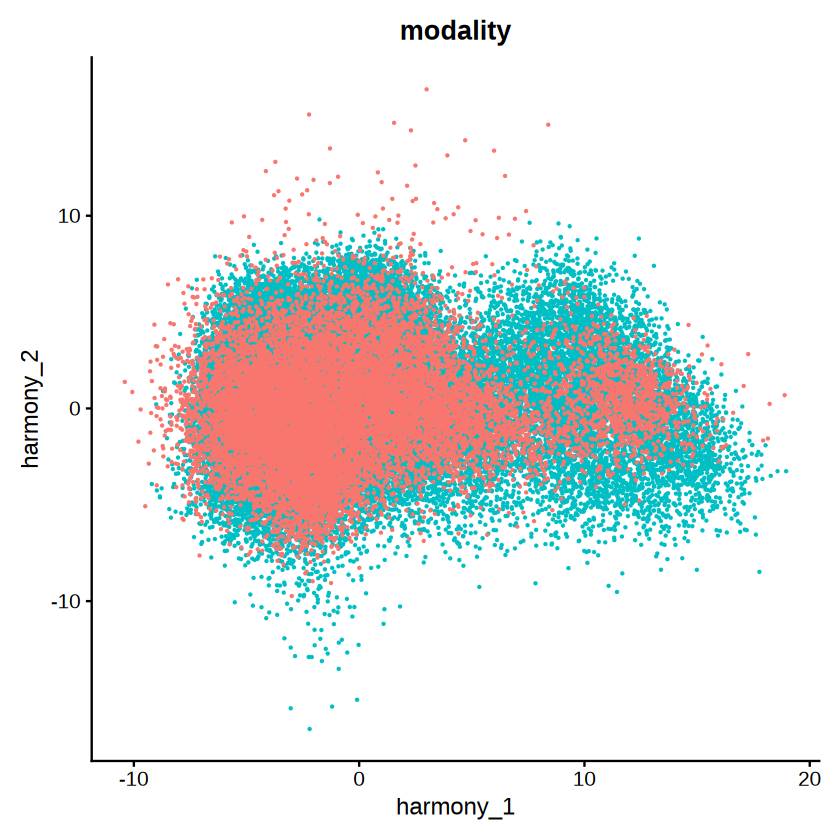

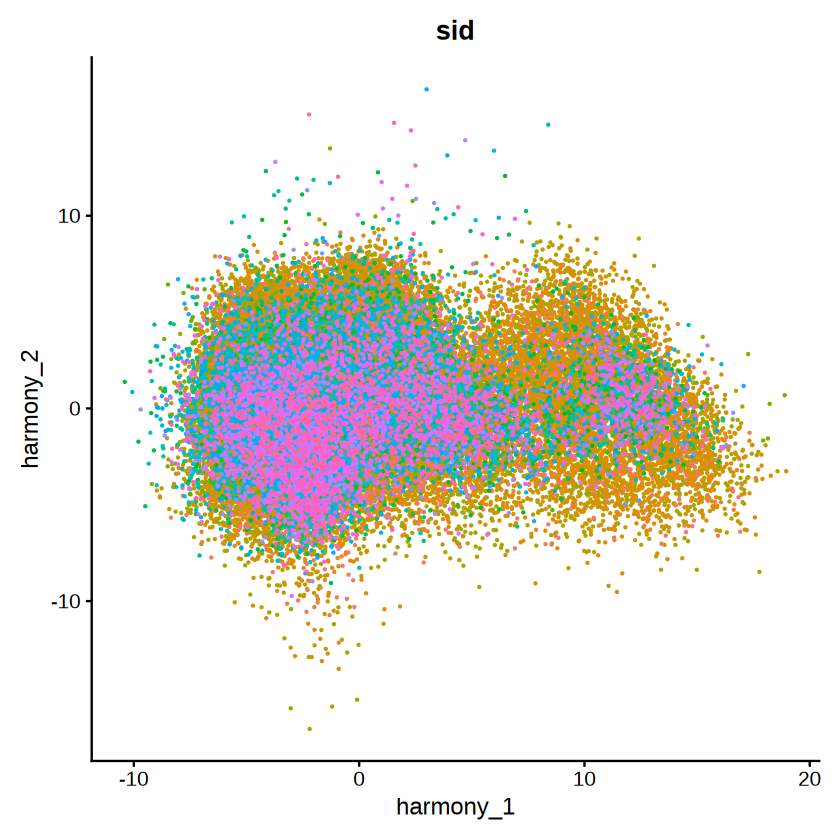

In [39]:
l_merged <- BuildIntegratedReference(
    xen = xen_dc,
    sc = sc[, sc$cell_type == "Dendritic cell"],
    normalization_target = "mean_of_medians",
    hvgs = hvgs,
    annotation_var = "cluster_name"
)

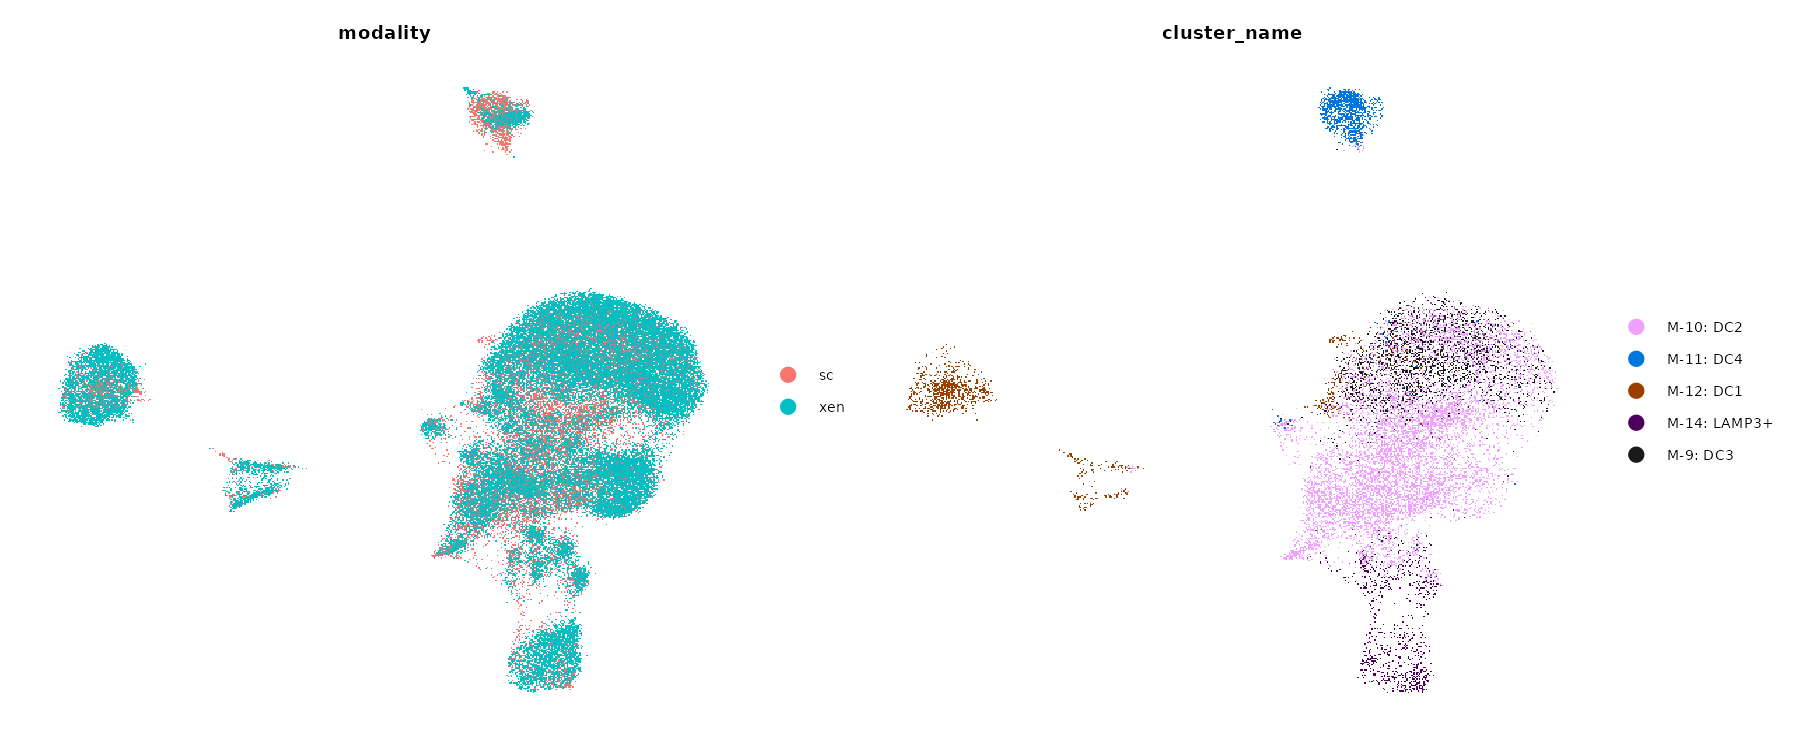

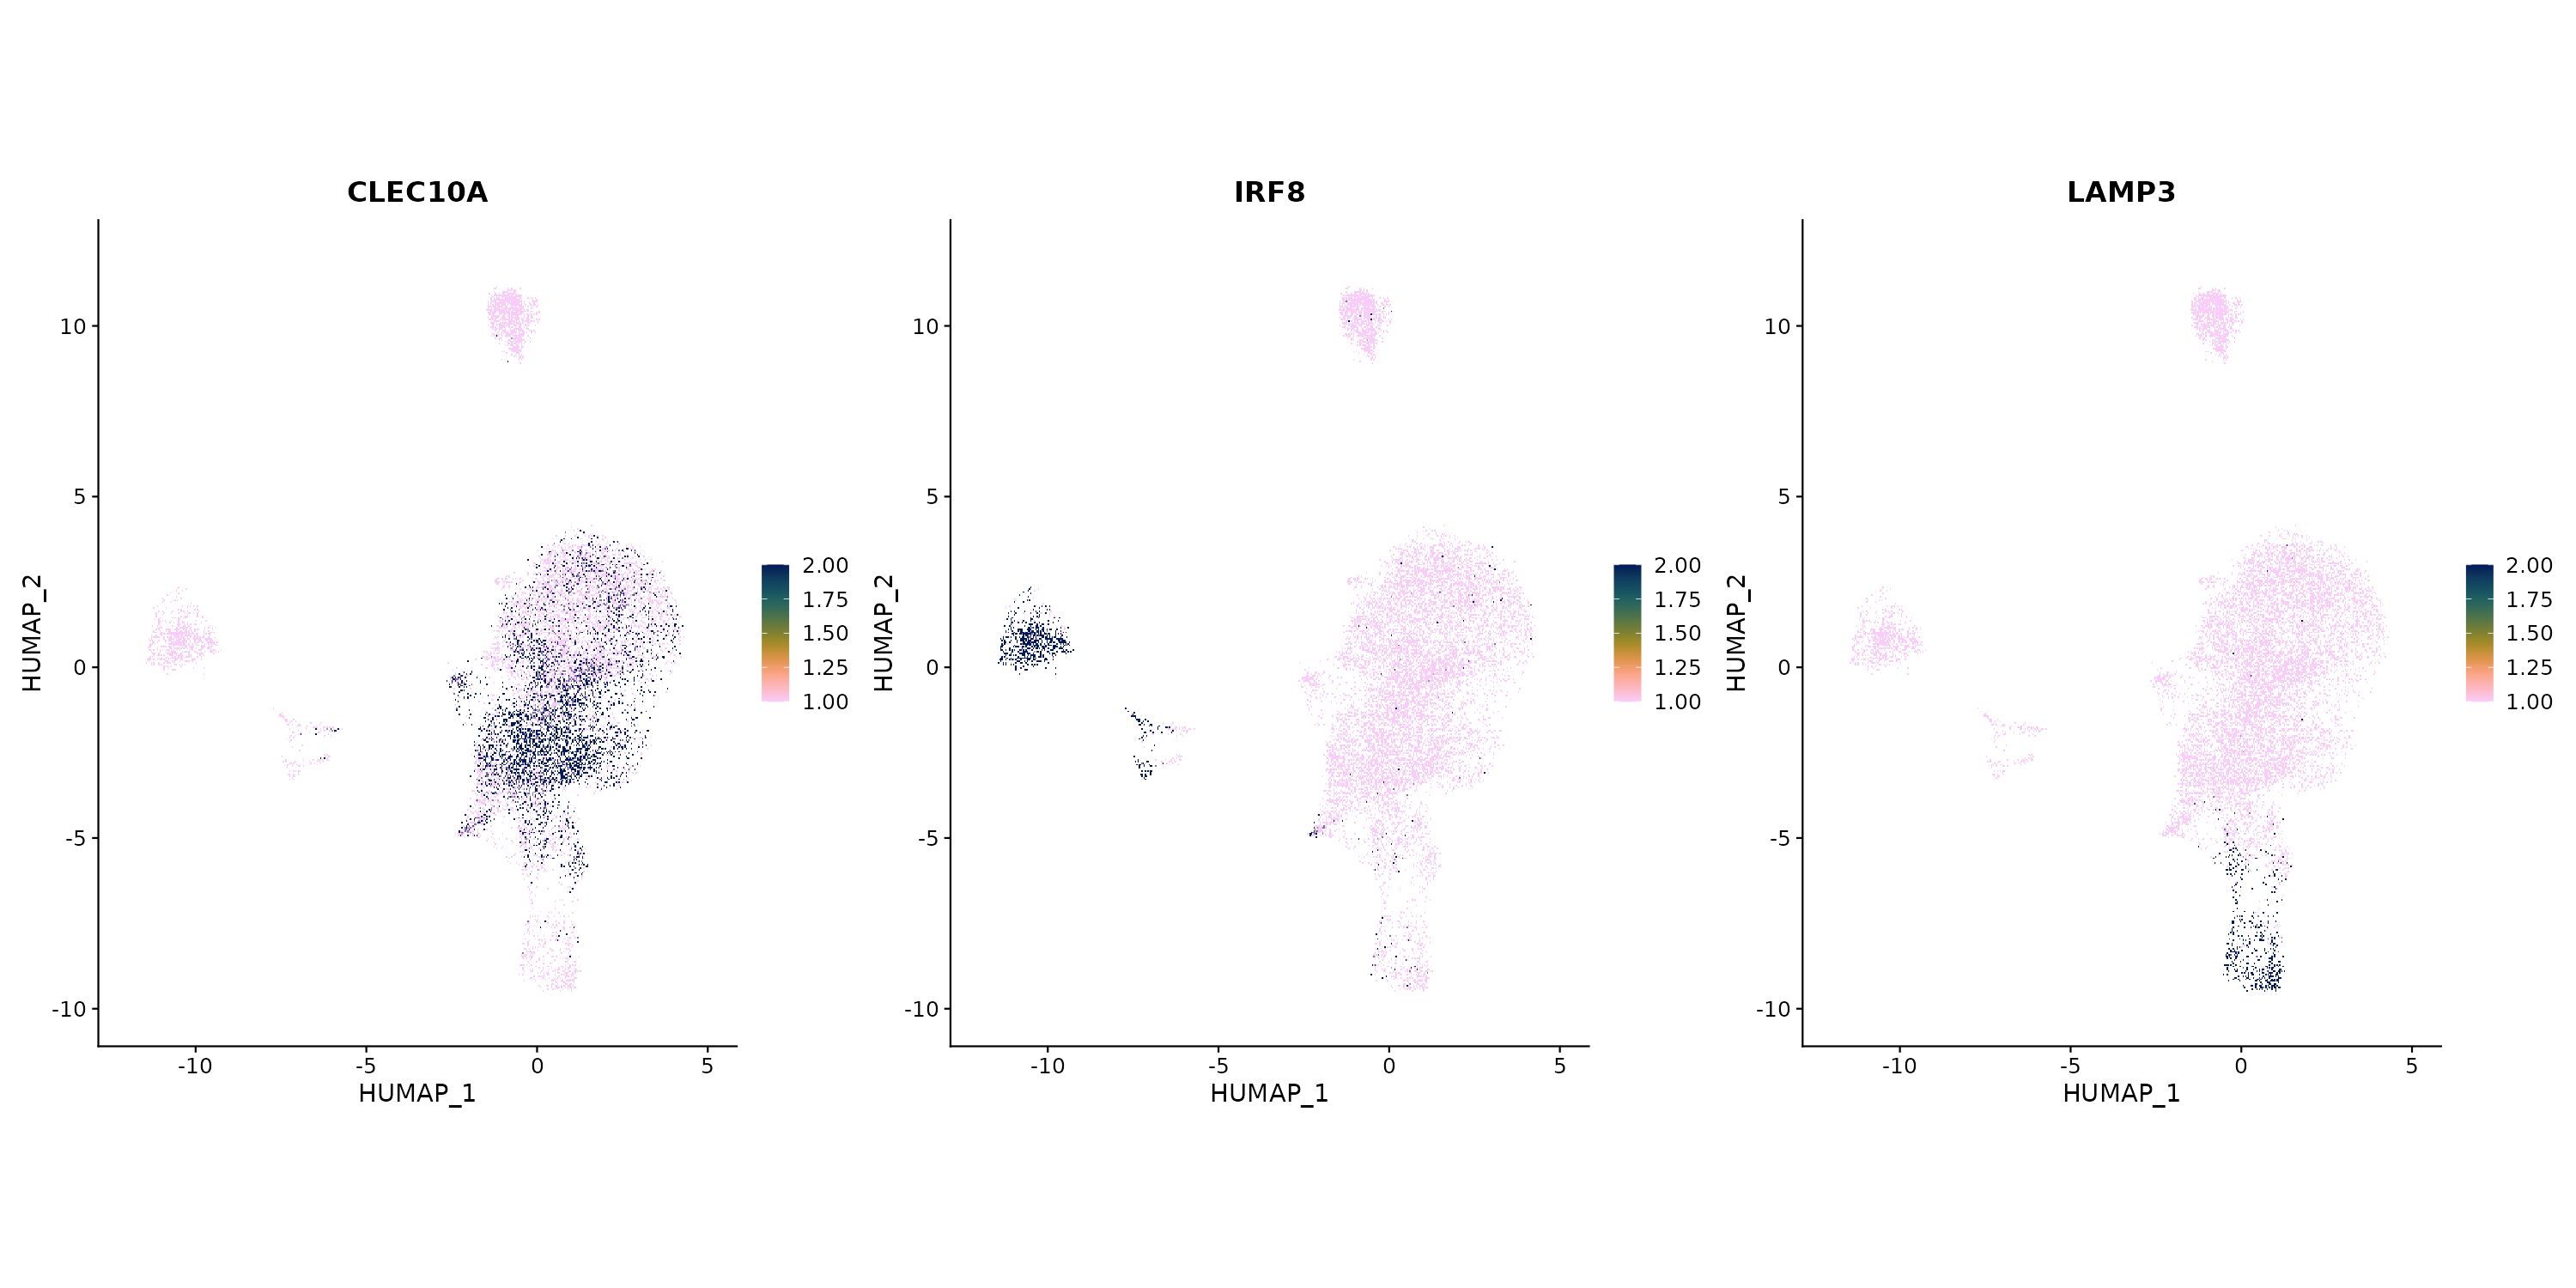

In [76]:
ShowTransferDiagnostics(
    merged = l_merged,
    annotation_var = "cluster_name",
    genes_to_visualize = c("CLEC10A", "IRF8", "LAMP3")
)

## Label transfer


[1/4] Checking inputs... 
  Using annotation variable: cluster_name 

[2/4] Skipping NNG construction since graph is provided... 

[3/4] Transferring labels from sc cells to xen cells... 
  Labels written to: cluster_name 
  Xen cells without transferred labels: 2441 

[4/4] Plotting unlabeled cells and final xen label map... 


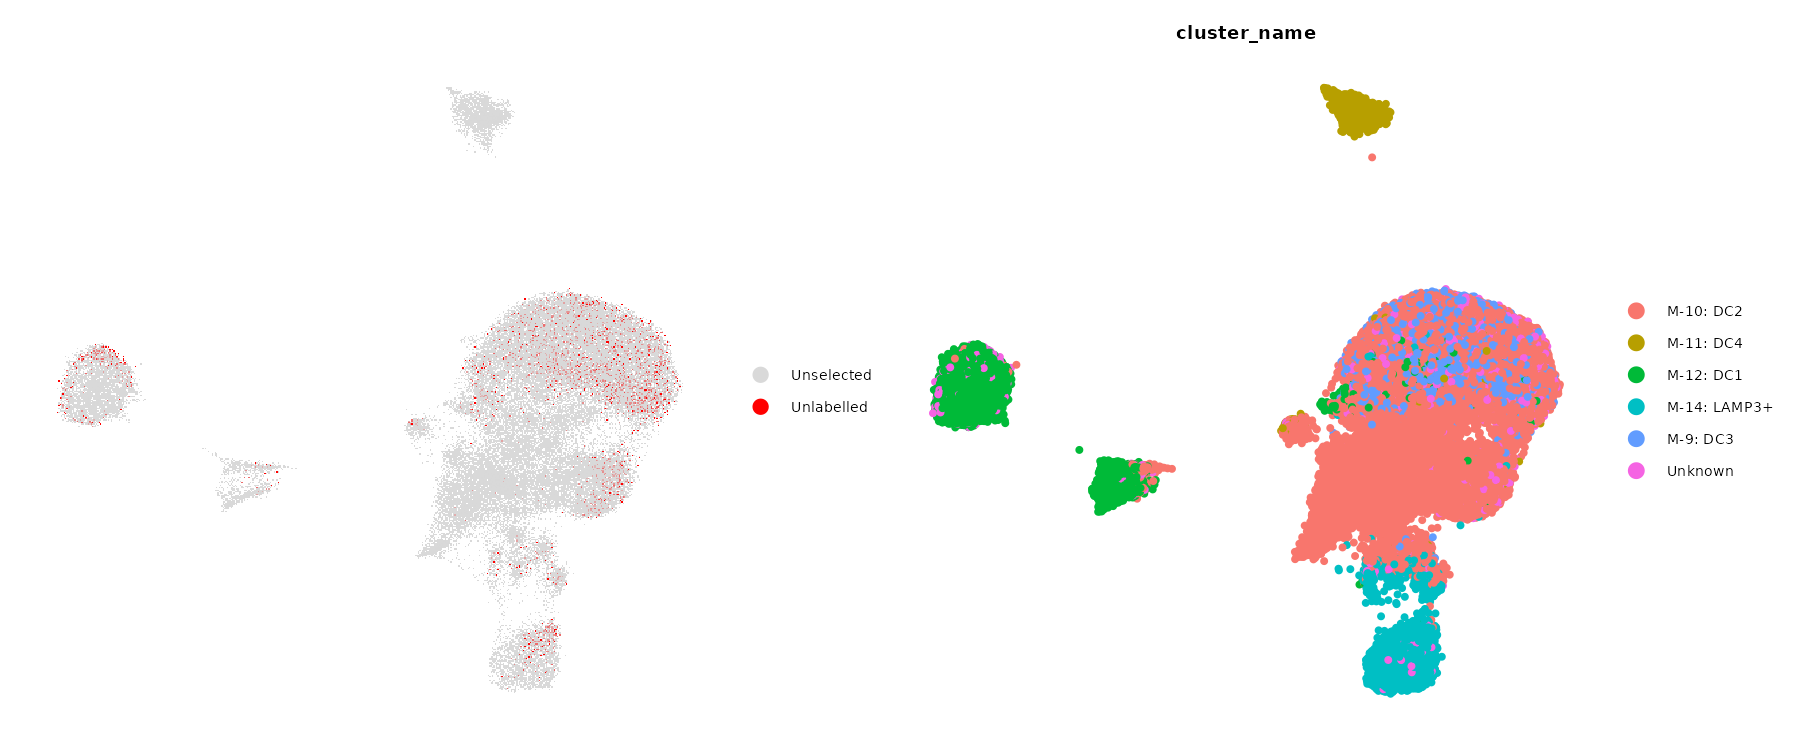

In [52]:
l_merged <- TransferLabelsGraph(
    merged = l_merged,
    annotation_var = "cluster_name",
    n_neighbors = 50,
    min_ratio = 1.1
)

## Examine marker genes

In [78]:
ShowClusterMarkers(l_merged[, l_merged$modality == "xen"], "cluster_name", n_show = 5)

row,M-10: DC2,M-11: DC4,M-12: DC1,M-14: LAMP3+,M-9: DC3,Unknown
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CLEC10A,CTSS,WDFY4,LAMP3,C1QC,C1QC
2,FCER1A,CD52,IRF8,FSCN1,C1QA,C1QA
3,S100A4,S100A4,SLAMF7,CD83,CD14,STAB1
4,CD1C,LILRB1,ANPEP,CDKN1A,STAB1,SLCO2B1
5,FCGR2A,KLF2,CPVL,LY75,SLCO2B1,F13A1


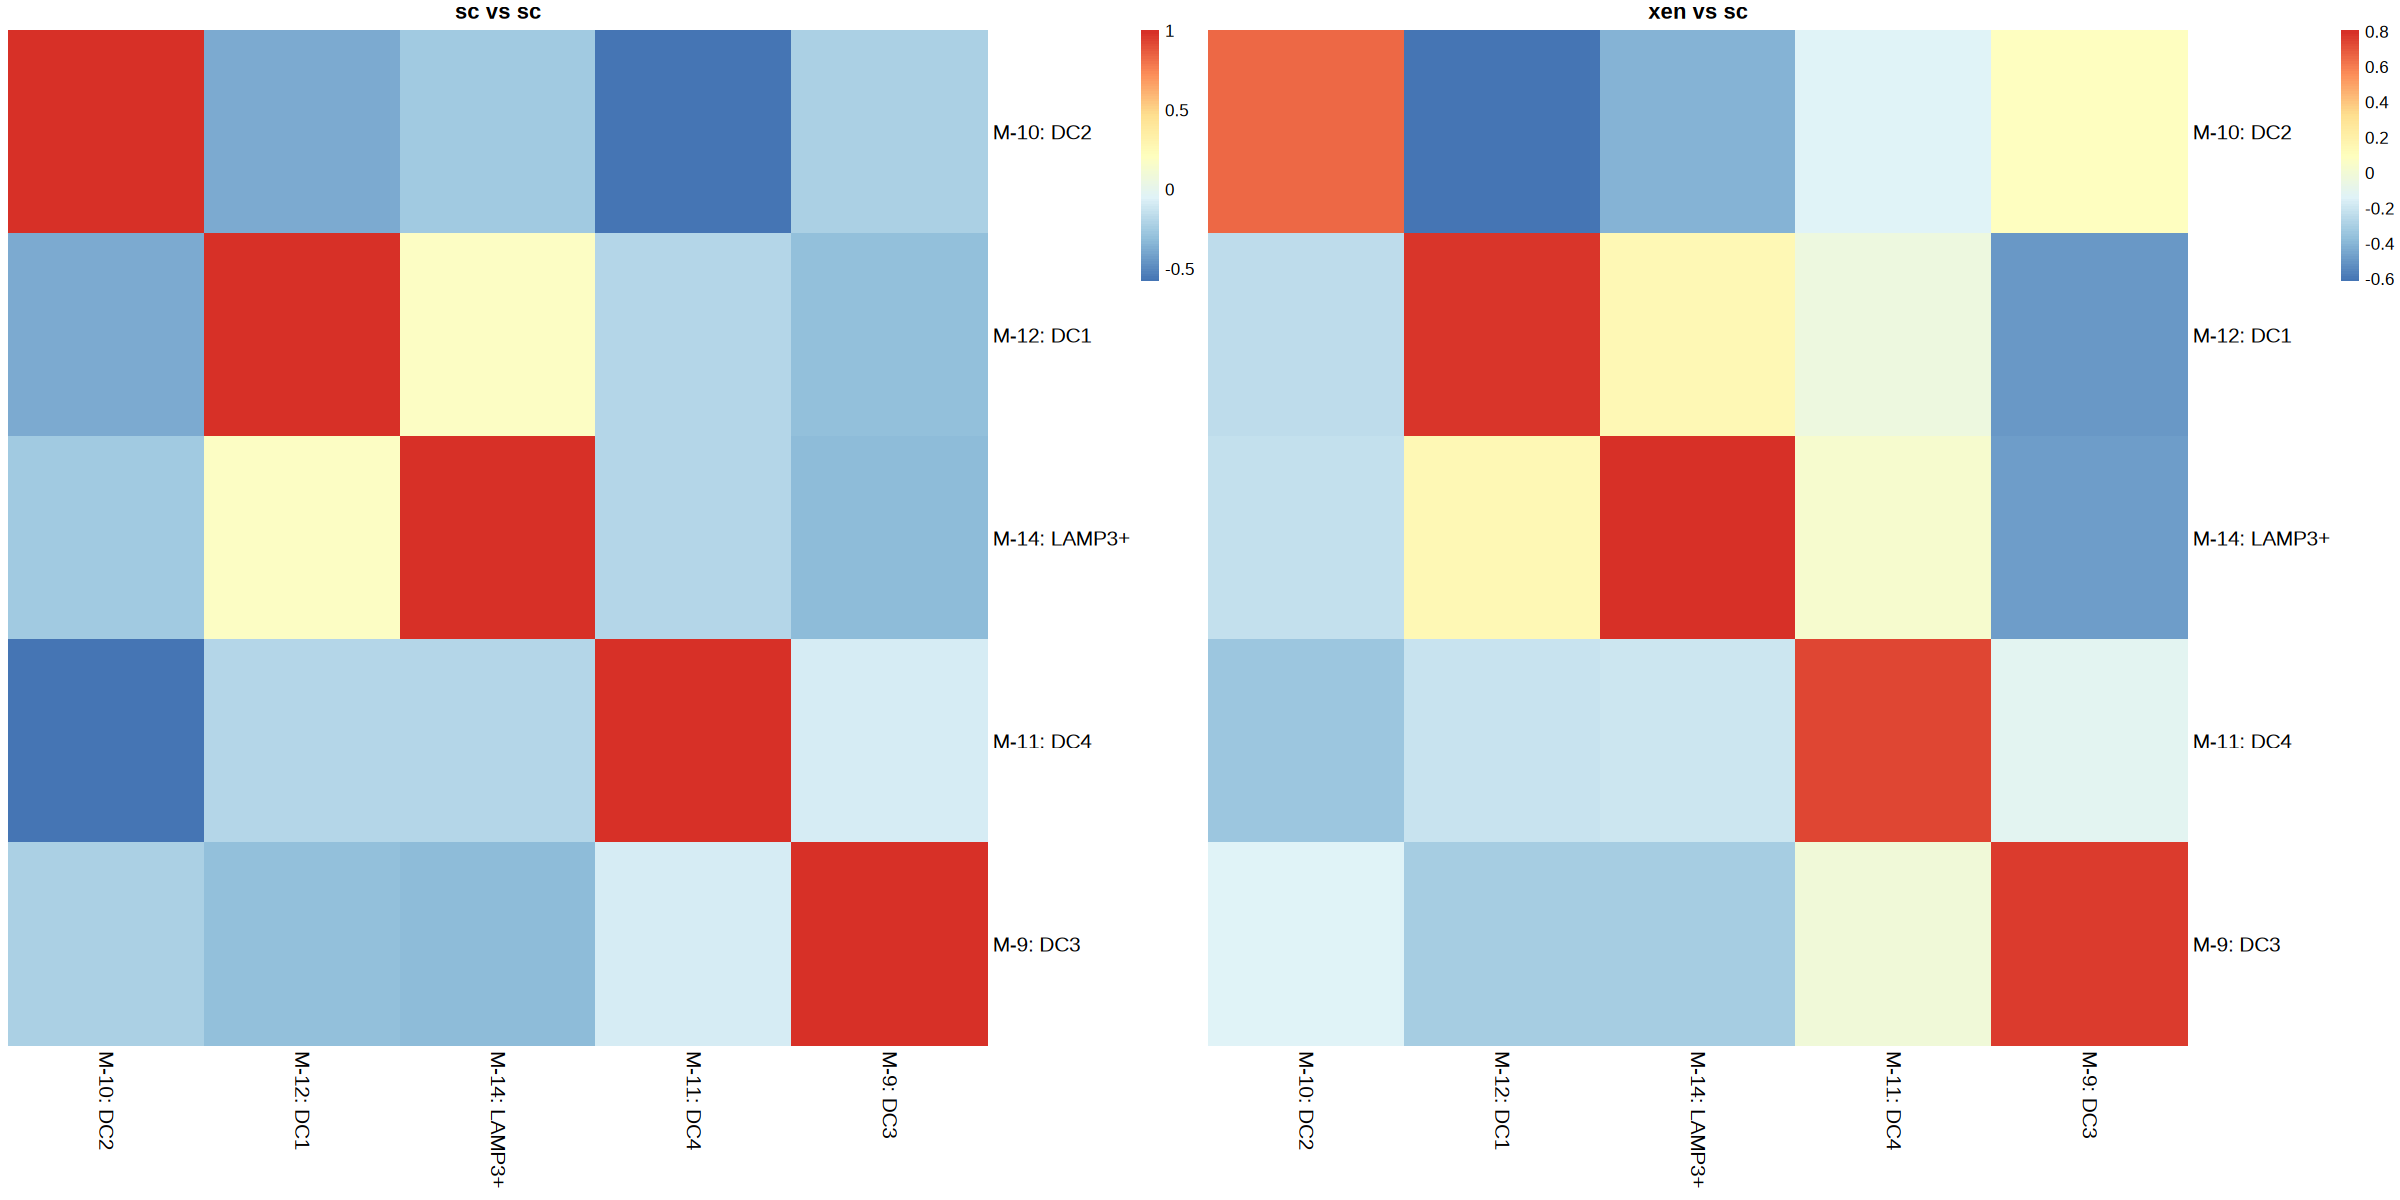

In [79]:
res <- CompareMarkerCorrelations(l_merged[,l_merged$modality == "xen"],
                                 l_merged[,l_merged$modality == "sc"], "cluster_name", bicluster = T)

## Save

In [82]:
xen_dc@meta.data <- subset(
  xen_dc@meta.data,
  select = -c(humap_fgraph_res.0.8, seurat_clusters)
)

colnames(l_merged) <- sub("^xen_", "", colnames(l_merged))

xen_dc$celltype.fine <- l_merged$cluster_name[
  match(colnames(xen_dc), colnames(l_merged))
]
xen_dc[[]]$celltype.fine[is.na(xen_dc[[]]$celltype.fine)] <- "M-15: Untyped DCs"

In [83]:
saveRDS(xen_dc, file = "out_rds/intermediate/_Dendritic cell_finetyped.rds")

**pDCs were not subtyped further since only one AMPp2 cluster contains pDCs, but maybe in the future I can find HVGs per sample ID in the pDCs and try to type them further.** 